In [1]:
!pip install ultralytics -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 21.5 MB/s eta 0:00:00


In [2]:
!pip install -q imagecodecs zarr ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.5/26.5 MB 66.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.7/295.7 kB 20.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 106.5 MB/s eta 0:00:00


In [3]:
!pip install git+https://github.com/facebookresearch/segment-anything-2.git

import torch
from sam2.build_sam import build_sam2
from sam2.sam2_image_predictor import SAM2ImagePredictor

# 1. Paths to your files
# Note: SAM2 usually needs the .yaml config that matches the architecture
checkpoint = '/kaggle/input/datasets/ajmeerapadmavathi/svamitva-sam2-weights/sam2_hiera_large.pt'
model_cfg = "sam2_hiera_l.yaml"  # This is the standard config name for 'large'

try:
    # 2. Build the model using the official FB/Meta builder
    sam2_model = build_sam2(model_cfg, checkpoint, device='cuda')
    predictor = SAM2ImagePredictor(sam2_model)
    
    print("🚀 Success! Official SAM2 Predictor started with SVAMITVA weights.")
except Exception as e:
    print(f"❌ Error: {e}")
    print("If it says 'Config not found', we can download the .yaml directly.")

  Cloning https://github.com/facebookresearch/segment-anything-2.git to /tmp/pip-req-build-9a1f5jn2
  Running command git clone --filter=blob:none --quiet https://github.com/facebookresearch/segment-anything-2.git /tmp/pip-req-build-9a1f5jn2
  Resolved https://github.com/facebookresearch/segment-anything-2.git to commit 2b90b9f5ceec907a1c18123530e92e794ad901a4
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 32.5 kB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.5/154.5 kB 6.5 MB/s eta 0:00:00
  Created wheel for SAM-2: filename=sam_2-1.0-cp312-cp312-linux_x86_64.whl size=183669 sha256=197d284af32646cab2c47f052fe3c191e06fc5123dccf09b012fe20a2239929b
  Stored in directory: /tmp/pip-ephem-wheel-cache-b5ozz_bi/wheels/b0/5b/a1/c16dafb8c3c0046f1158e7fa7570559a72085df5beab759ba0
  Created wheel

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
🚀 Initializing Quad-Model Ensemble Engine...


[ WARN:0@14.990] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 33550 (0x830e) encountered
[ WARN:0@14.990] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 33922 (0x8482) encountered
[ WARN:0@14.990] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34735 (0x87af) encountered
[ WARN:0@14.990] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34737 (0x87b1) encountered
[ WARN:0@14.990] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 42112 (0xa480) encountered
🛰️ Core Processing: 100%|██████████| 870/870 [14:38<00:00,  1.01s/it]


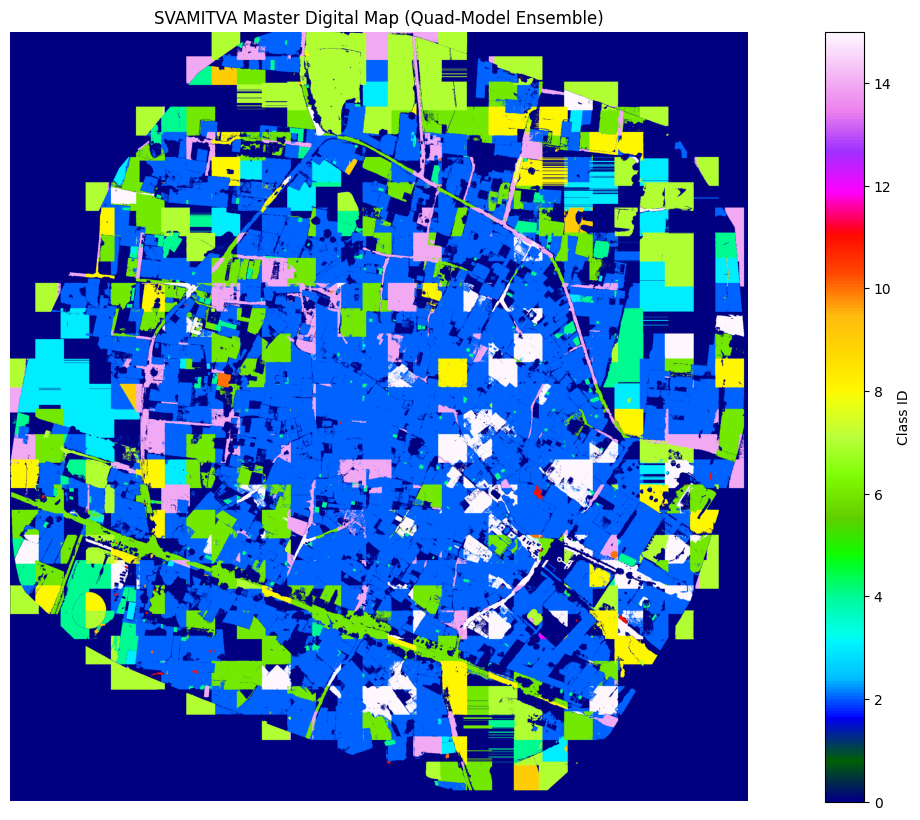

True

In [4]:
import os
import cv2
import torch
import numpy as np
import gc
import matplotlib.pyplot as plt
from tqdm import tqdm
from ultralytics import RTDETR, YOLO
from sam2.build_sam import build_sam2
from sam2.sam2_image_predictor import SAM2ImagePredictor

# --- 1. CONFIGURATION ---
RTDETR_PATH = '/kaggle/input/datasets/srikarmadabhushani/rtdetr-newlabv1a/weights/best.pt'
YOLO_L_PATH = '/kaggle/input/datasets/avinod666/yolo26-v1-newlabel1last/last (10).pt' 
HGNET_PATH = '/kaggle/input/datasets/srikarmadabhushani/hgnetv2/weights/best.pt'
YOLO_X_PATH = '/kaggle/input/datasets/ajmeeravinod/yolo26x-newlab-light/weights/best.pt' 
SAM_CHECKPOINT = '/kaggle/input/datasets/ajmeerapadmavathi/svamitva-sam2-weights/sam2_hiera_large.pt'
SAM_CONFIG = "sam2_hiera_l.yaml"
TIF_PATH = '/kaggle/input/datasets/startlearning45/dataset-tif/28996_NADALA_ORTHO.tif'

TILE_SIZE = 1024
OVERLAP = 128
CONF_THRESHOLD = 0.15 

# Priority Map: Roads (High) > Buildings (Standard)
# This ensures that even if models overlap, the road network stays continuous
PRIORITY = {5: 15, 13: 15, 14: 15, 6: 20, 7: 20, 0: 5, 1: 5, 2: 5, 3: 5, 4: 5}
ROAD_CLASSES = {5, 13, 14}

# --- 2. INITIALIZATION ---
print("🚀 Initializing Quad-Model Ensemble Engine...")
device0, device1 = 'cuda:0', 'cuda:1'

# Distributed across GPUs
m_hgnet = RTDETR(HGNET_PATH).to(device0)
m_rtdetr = RTDETR(RTDETR_PATH).to(device0)
m_yolo_l = YOLO(YOLO_L_PATH).to(device1)
m_yolo_x = YOLO(YOLO_X_PATH).to(device1)

predictor = SAM2ImagePredictor(build_sam2(SAM_CONFIG, SAM_CHECKPOINT, device=device0))

# --- 3. DATA PREPARATION ---
image_raw = cv2.imread(TIF_PATH, cv2.IMREAD_UNCHANGED)
if image_raw.dtype == np.uint16:
    image_raw = cv2.normalize(image_raw, None, 0, 255, cv2.NORM_MINMAX, dtype=cv2.CV_8U)
image_rgb = cv2.cvtColor(image_raw, cv2.COLOR_BGR2RGB)
h, w, _ = image_rgb.shape

# Use memmap to prevent the "Memory Allocation" crash
global_map = np.memmap('global_map.dat', dtype='uint8', mode='w+', shape=(h, w))
prio_map = np.memmap('prio.dat', dtype='uint8', mode='w+', shape=(h, w))
global_map[:] = 0
prio_map[:] = 0

def update_map(y1, x1, y2, x2, mask, cid, p):
    target_h, target_w = y2-y1, x2-x1
    if mask.shape != (target_h, target_w):
        mask = cv2.resize(mask.astype(np.uint8), (target_w, target_h), interpolation=cv2.INTER_NEAREST)
    
    g_slice = global_map[y1:y2, x1:x2]
    p_slice = prio_map[y1:y2, x1:x2]
    
    # Overwrite only if new detection has higher priority
    valid = (mask > 0) & (p >= p_slice)
    g_slice[valid] = cid + 1
    p_slice[valid] = p

# --- 4. ENSEMBLE INFERENCE ---
stride = TILE_SIZE - OVERLAP
tiles = [(y, x) for y in range(0, h - TILE_SIZE, stride) for x in range(0, w - TILE_SIZE, stride)]

with torch.inference_mode():
    for y, x in tqdm(tiles, desc="🛰️ Core Processing"):
        tile = image_rgb[y:y+TILE_SIZE, x:x+TILE_SIZE]
        if np.mean(tile) < 20 or np.mean(tile) > 240: continue

        # Run Predictions
        res0 = m_hgnet.predict(tile, conf=CONF_THRESHOLD, device=device0, verbose=False)[0]
        res1 = m_rtdetr.predict(tile, conf=CONF_THRESHOLD, device=device0, verbose=False)[0]
        res2 = m_yolo_l.predict(tile, conf=CONF_THRESHOLD, device=device1, verbose=False)[0]
        res3 = m_yolo_x.predict(tile, conf=CONF_THRESHOLD, device=device1, verbose=False)[0]

        all_boxes, all_clss = [], []
        for r in [res0, res1, res2, res3]:
            if len(r.boxes) > 0:
                all_boxes.append(r.boxes.xyxy.cpu().numpy())
                all_clss.append(r.boxes.cls.cpu().numpy())

        if not all_boxes: continue
        t_boxes = np.concatenate(all_boxes)
        t_classes = np.concatenate(all_clss)

        # SAM2 Segmentation
        predictor.set_image(tile)
        for i in range(0, len(t_boxes), 25):
            batch_boxes = t_boxes[i : i + 25]
            batch_clss = t_classes[i : i + 25]
            masks, _, _ = predictor.predict(box=batch_boxes, multimask_output=False)
            
            for j, mask in enumerate(masks):
                cid = int(batch_clss[j])
                update_map(y, x, y+TILE_SIZE, x+TILE_SIZE, mask[0], cid, PRIORITY.get(cid, 10))

# --- 5. VISUALIZATION ---
global_map.flush()
scale = 0.1 
preview = cv2.resize(global_map, (int(w*scale), int(h*scale)), interpolation=cv2.INTER_NEAREST)

plt.figure(figsize=(20, 10))
# Using 'gist_ncar' to match your clear road output screenshot
plt.imshow(preview, cmap='gist_ncar', vmin=0, vmax=np.max(global_map))
plt.title("SVAMITVA Master Digital Map (Quad-Model Ensemble)")
plt.axis('off')
plt.colorbar(label="Class ID")
plt.show()

# Save Outputs
cv2.imwrite('svamitva_quad_ensemble.png', global_map)

🚀 Initializing Quad-Model Ensemble Engine...


[ WARN:0@936.143] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 33550 (0x830e) encountered
[ WARN:0@936.143] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 33922 (0x8482) encountered
[ WARN:0@936.143] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34735 (0x87af) encountered
[ WARN:0@936.143] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34737 (0x87b1) encountered
[ WARN:0@936.143] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 42112 (0xa480) encountered
🛰️ Core Processing: 100%|██████████| 870/870 [13:47<00:00,  1.05it/s]


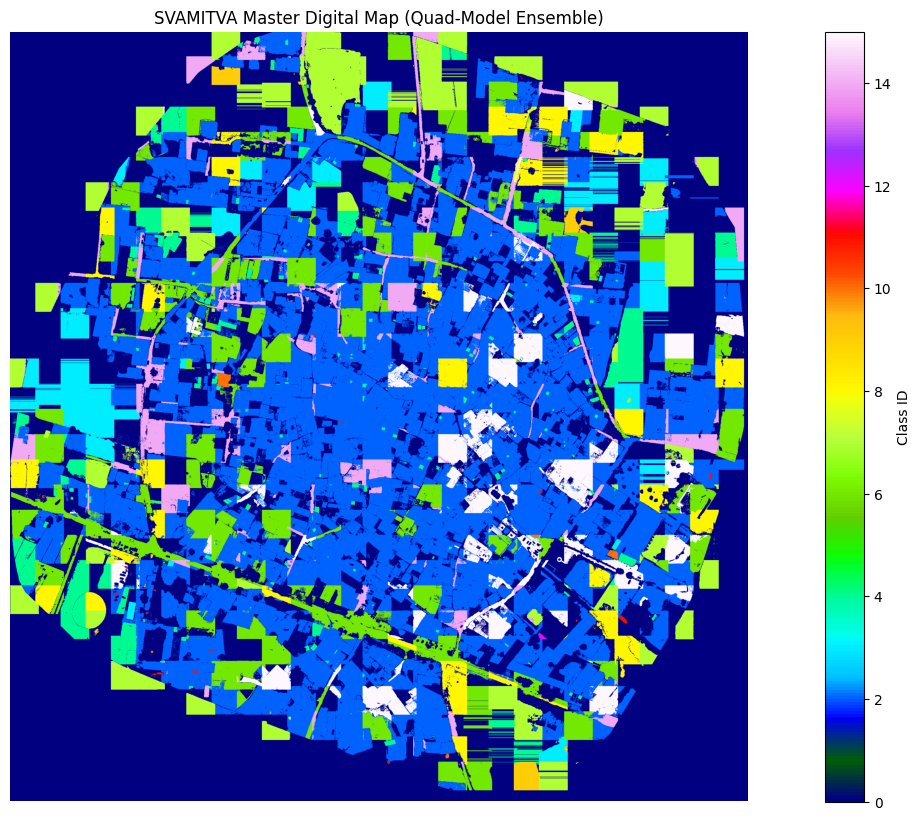

True

In [5]:
import os
import cv2
import torch
import numpy as np
import gc
import matplotlib.pyplot as plt
from tqdm import tqdm
from ultralytics import RTDETR, YOLO
from sam2.build_sam import build_sam2
from sam2.sam2_image_predictor import SAM2ImagePredictor

# --- 1. CONFIGURATION ---
RTDETR_PATH = '/kaggle/input/datasets/srikarmadabhushani/rtdetr-newlabv1a/weights/best.pt'
YOLO_L_PATH = '/kaggle/input/datasets/avinod666/yolo26-v1-newlabel1last/last (10).pt' 
HGNET_PATH = '/kaggle/input/datasets/srikarmadabhushani/hgnetv2/weights/best.pt'
YOLO_X_PATH = '/kaggle/input/datasets/ajmeeravinod/yolo26x-newlab-light/weights/best.pt' 
SAM_CHECKPOINT = '/kaggle/input/datasets/ajmeerapadmavathi/svamitva-sam2-weights/sam2_hiera_large.pt'
SAM_CONFIG = "sam2_hiera_l.yaml"
TIF_PATH = '/kaggle/input/datasets/startlearning45/dataset-tif/28996_NADALA_ORTHO.tif'

TILE_SIZE = 1024
OVERLAP = 128
CONF_THRESHOLD = 0.25 

# Priority Map: Roads (High) > Buildings (Standard)
# This ensures that even if models overlap, the road network stays continuous
PRIORITY = {5: 15, 13: 15, 14: 15, 6: 20, 7: 20, 0: 5, 1: 5, 2: 5, 3: 5, 4: 5}
ROAD_CLASSES = {5, 13, 14}

# --- 2. INITIALIZATION ---
print("🚀 Initializing Quad-Model Ensemble Engine...")
device0, device1 = 'cuda:0', 'cuda:1'

# Distributed across GPUs
m_hgnet = RTDETR(HGNET_PATH).to(device0)
m_rtdetr = RTDETR(RTDETR_PATH).to(device0)
m_yolo_l = YOLO(YOLO_L_PATH).to(device1)
m_yolo_x = YOLO(YOLO_X_PATH).to(device1)

predictor = SAM2ImagePredictor(build_sam2(SAM_CONFIG, SAM_CHECKPOINT, device=device0))

# --- 3. DATA PREPARATION ---
image_raw = cv2.imread(TIF_PATH, cv2.IMREAD_UNCHANGED)
if image_raw.dtype == np.uint16:
    image_raw = cv2.normalize(image_raw, None, 0, 255, cv2.NORM_MINMAX, dtype=cv2.CV_8U)
image_rgb = cv2.cvtColor(image_raw, cv2.COLOR_BGR2RGB)
h, w, _ = image_rgb.shape

# Use memmap to prevent the "Memory Allocation" crash
global_map = np.memmap('global_map.dat', dtype='uint8', mode='w+', shape=(h, w))
prio_map = np.memmap('prio.dat', dtype='uint8', mode='w+', shape=(h, w))
global_map[:] = 0
prio_map[:] = 0

def update_map(y1, x1, y2, x2, mask, cid, p):
    target_h, target_w = y2-y1, x2-x1
    if mask.shape != (target_h, target_w):
        mask = cv2.resize(mask.astype(np.uint8), (target_w, target_h), interpolation=cv2.INTER_NEAREST)
    
    g_slice = global_map[y1:y2, x1:x2]
    p_slice = prio_map[y1:y2, x1:x2]
    
    # Overwrite only if new detection has higher priority
    valid = (mask > 0) & (p >= p_slice)
    g_slice[valid] = cid + 1
    p_slice[valid] = p

# --- 4. ENSEMBLE INFERENCE ---
stride = TILE_SIZE - OVERLAP
tiles = [(y, x) for y in range(0, h - TILE_SIZE, stride) for x in range(0, w - TILE_SIZE, stride)]

with torch.inference_mode():
    for y, x in tqdm(tiles, desc="🛰️ Core Processing"):
        tile = image_rgb[y:y+TILE_SIZE, x:x+TILE_SIZE]
        if np.mean(tile) < 20 or np.mean(tile) > 240: continue

        # Run Predictions
        res0 = m_hgnet.predict(tile, conf=CONF_THRESHOLD, device=device0, verbose=False)[0]
        res1 = m_rtdetr.predict(tile, conf=CONF_THRESHOLD, device=device0, verbose=False)[0]
        res2 = m_yolo_l.predict(tile, conf=CONF_THRESHOLD, device=device1, verbose=False)[0]
        res3 = m_yolo_x.predict(tile, conf=CONF_THRESHOLD, device=device1, verbose=False)[0]

        all_boxes, all_clss = [], []
        for r in [res0, res1, res2, res3]:
            if len(r.boxes) > 0:
                all_boxes.append(r.boxes.xyxy.cpu().numpy())
                all_clss.append(r.boxes.cls.cpu().numpy())

        if not all_boxes: continue
        t_boxes = np.concatenate(all_boxes)
        t_classes = np.concatenate(all_clss)

        # SAM2 Segmentation
        predictor.set_image(tile)
        for i in range(0, len(t_boxes), 25):
            batch_boxes = t_boxes[i : i + 25]
            batch_clss = t_classes[i : i + 25]
            masks, _, _ = predictor.predict(box=batch_boxes, multimask_output=False)
            
            for j, mask in enumerate(masks):
                cid = int(batch_clss[j])
                update_map(y, x, y+TILE_SIZE, x+TILE_SIZE, mask[0], cid, PRIORITY.get(cid, 10))

# --- 5. VISUALIZATION ---
global_map.flush()
scale = 0.1 
preview = cv2.resize(global_map, (int(w*scale), int(h*scale)), interpolation=cv2.INTER_NEAREST)

plt.figure(figsize=(20, 10))
# Using 'gist_ncar' to match your clear road output screenshot
plt.imshow(preview, cmap='gist_ncar', vmin=0, vmax=np.max(global_map))
plt.title("SVAMITVA Master Digital Map (Quad-Model Ensemble)")
plt.axis('off')
plt.colorbar(label="Class ID")
plt.show()

# Save Outputs
cv2.imwrite('svamitva_quad_ensemble.png', global_map)

🚀 Initializing Quad-Model Ensemble + SAM 2 Edge Refiner...


[ WARN:0@1801.159] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 33550 (0x830e) encountered
[ WARN:0@1801.160] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 33922 (0x8482) encountered
[ WARN:0@1801.160] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34735 (0x87af) encountered
[ WARN:0@1801.160] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34737 (0x87b1) encountered
[ WARN:0@1801.160] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 42112 (0xa480) encountered
🛰️ Mapping SVAMITVA Infrastructure: 100%|██████████| 931/931 [14:16<00:00,  1.09it/s]


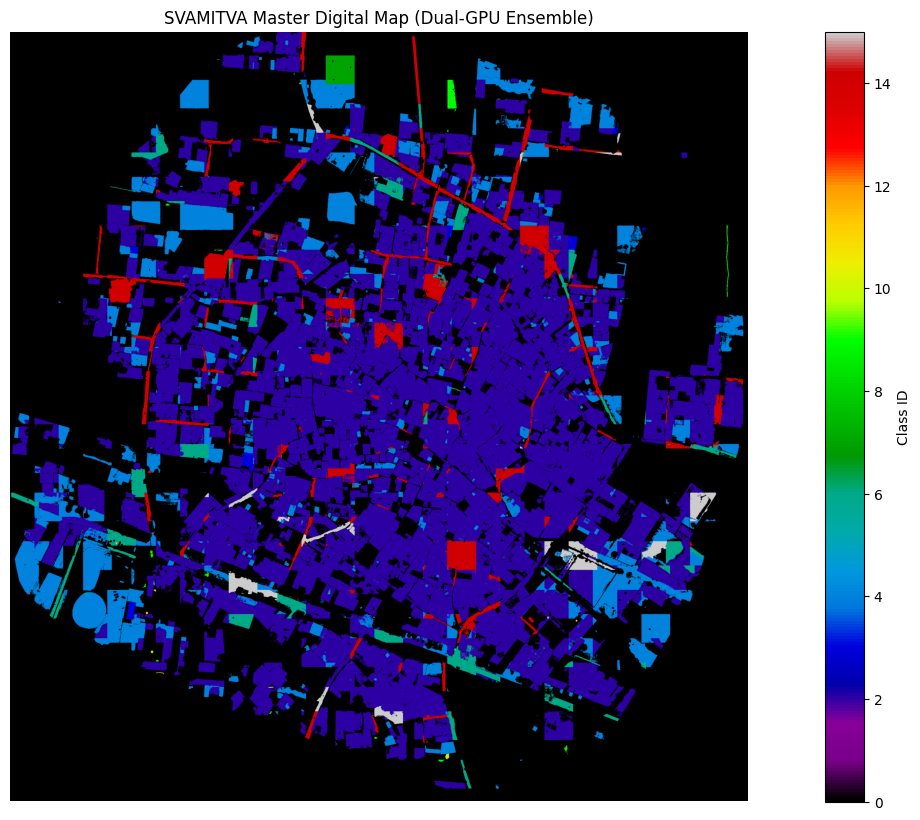

✅ Processing Complete. Final map saved.


In [6]:
import os
import cv2
import torch
import numpy as np
import gc
import matplotlib.pyplot as plt
from tqdm import tqdm
from ultralytics import RTDETR, YOLO
from sam2.build_sam import build_sam2
from sam2.sam2_image_predictor import SAM2ImagePredictor

# --- 1. CONFIGURATION ---
RTDETR_PATH = '/kaggle/input/datasets/srikarmadabhushani/rtdetr-newlabv1b/weights/best.pt'
YOLO_L_PATH = '/kaggle/input/datasets/vinodajmeera1/yolo26-l-v1-newlabelv1/weights/last.pt' 
HGNET_PATH = '/kaggle/input/datasets/srikarmadabhushani/hgnetv2a/weights/best.pt'
YOLO_X_PATH = '/kaggle/input/datasets/ajmeeravinod/yolo26x-newlab-light/weights/best.pt' 
SAM_CHECKPOINT = '/kaggle/input/datasets/ajmeerapadmavathi/svamitva-sam2-weights/sam2_hiera_large.pt'
SAM_CONFIG = "sam2_hiera_l.yaml"
TIF_PATH = '/kaggle/input/datasets/startlearning45/dataset-tif/28996_NADALA_ORTHO.tif'

TILE_SIZE = 1024
OVERLAP = 160
WATER_CONF = 0.12  
BUILDING_CONF = 0.30
TEXTURE_THRESHOLD = 15.0 

# Priority Logic: Water (6,7) > Roads (5,13,14) > Buildings (0-4)
PRIORITY = {6: 40, 7: 40, 5: 20, 13: 20, 14: 20, 0: 10, 1: 10, 2: 10, 3: 10, 4: 10}

# --- 2. INITIALIZATION ---
print("🚀 Initializing Quad-Model Ensemble + SAM 2 Edge Refiner...")
device0, device1 = 'cuda:0', 'cuda:1'

m_hgnet = RTDETR(HGNET_PATH).to(device0)
m_rtdetr = RTDETR(RTDETR_PATH).to(device0)
m_yolo_l = YOLO(YOLO_L_PATH).to(device1)
m_yolo_x = YOLO(YOLO_X_PATH).to(device1)

predictor = SAM2ImagePredictor(build_sam2(SAM_CONFIG, SAM_CHECKPOINT, device=device0))

# --- 3. UTILITIES ---
def is_actually_water(tile, mask):
    """Refines pond detection by checking for surface smoothness."""
    # Ensure mask is exactly 2D for np.where
    if len(mask.shape) != 2:
        mask = mask.reshape(TILE_SIZE, TILE_SIZE)

    indices = np.where(mask > 0)
    
    # Check if we got exactly two arrays (y and x)
    if len(indices) != 2:
        return False
        
    y_idx, x_idx = indices
    
    # Safety: If mask is too small, it's not a valid water body
    if len(y_idx) < 100: 
        return False 
    
    try:
        y1, y2 = np.min(y_idx), np.max(y_idx)
        x1, x2 = np.min(x_idx), np.max(x_idx)
        
        # Avoid empty slices
        if y2 <= y1 or x2 <= x1:
            return False
            
        roi = tile[y1:y2, x1:x2]
        gray = cv2.cvtColor(roi, cv2.COLOR_RGB2GRAY)
        # Low variance = smooth surface (Water/Algae), High = rough (Grass/Ground)
        return cv2.Laplacian(gray, cv2.CV_64F).var() < TEXTURE_THRESHOLD
    except Exception:
        return False

# --- 4. DATA PREPARATION ---
image_raw = cv2.imread(TIF_PATH, cv2.IMREAD_UNCHANGED)
if image_raw is None:
    raise FileNotFoundError(f"TIF not found at {TIF_PATH}")

if image_raw.dtype == np.uint16:
    image_raw = cv2.normalize(image_raw, None, 0, 255, cv2.NORM_MINMAX, dtype=cv2.CV_8U)
image_rgb = cv2.cvtColor(image_raw, cv2.COLOR_BGR2RGB)
h, w, _ = image_rgb.shape

global_map = np.memmap('master_map.dat', dtype='uint8', mode='w+', shape=(h, w))
prio_map = np.memmap('priority_map.dat', dtype='uint8', mode='w+', shape=(h, w))
global_map[:] = 0
prio_map[:] = 0

# --- 5. CORE PIPELINE ---
stride = TILE_SIZE - OVERLAP
tiles = [(y, x) for y in range(0, h - TILE_SIZE, stride) for x in range(0, w - TILE_SIZE, stride)]
tiles.append((h-TILE_SIZE, w-TILE_SIZE))

with torch.inference_mode():
    for y, x in tqdm(tiles, desc="🛰️ Mapping SVAMITVA Infrastructure"):
        tile = image_rgb[y:y+TILE_SIZE, x:x+TILE_SIZE]
        if np.mean(tile) < 15 or np.mean(tile) > 245: continue

        all_boxes, all_clss = [], []
        
        # YOLO Processing
        for m in [m_yolo_l, m_yolo_x]:
            res = m.predict(tile, conf=WATER_CONF, device=device1, verbose=False)[0]
            if len(res.boxes) > 0:
                for b, c, f in zip(res.boxes.xyxy.cpu().numpy(), res.boxes.cls.cpu().numpy(), res.boxes.conf.cpu().numpy()):
                    cid = int(c)
                    if cid in [6, 7] or f >= BUILDING_CONF:
                        all_boxes.append(b)
                        all_clss.append(cid)

        # RT-DETR Processing
        for m in [m_hgnet, m_rtdetr]:
            res = m.predict(tile, conf=BUILDING_CONF, device=device0, verbose=False)[0]
            if len(res.boxes) > 0:
                for b, c in zip(res.boxes.xyxy.cpu().numpy(), res.boxes.cls.cpu().numpy()):
                    all_boxes.append(b)
                    all_clss.append(int(c))

        if not all_boxes: continue
        
        t_boxes = np.array(all_boxes, dtype=np.float32)
        t_clss = np.array(all_clss, dtype=np.int32)

        predictor.set_image(tile)
        masks, scores, _ = predictor.predict(box=t_boxes, multimask_output=False)

        for i, mask in enumerate(masks):
            cid = int(t_clss[i])
            # mask[0] is typically (1, 1024, 1024) -> Squeeze to (1024, 1024)
            m_bin = np.squeeze(mask).astype(np.uint8)
            
            # Algae/Pond refinement logic
            if cid in [6, 7] and not is_actually_water(tile, m_bin):
                continue 

            p = PRIORITY.get(cid, 5)
            g_slice = global_map[y:y+TILE_SIZE, x:x+TILE_SIZE]
            p_slice = prio_map[y:y+TILE_SIZE, x:x+TILE_SIZE]
            
            update_idx = (m_bin > 0) & (p >= p_slice)
            g_slice[update_idx] = cid + 1 
            p_slice[update_idx] = p

# --- 6. OUTPUT & VISUALIZATION ---
global_map.flush()
scale = 0.1 
preview = cv2.resize(global_map, (int(w*scale), int(h*scale)), interpolation=cv2.INTER_NEAREST)

plt.figure(figsize=(20, 10))
plt.imshow(preview, cmap='nipy_spectral', vmin=0, vmax=15)
plt.title("SVAMITVA Master Digital Map (Dual-GPU Ensemble)")
plt.colorbar(label="Class ID")
plt.axis('off')
plt.show()

cv2.imwrite('svamitva_final_output.png', global_map)
print("✅ Processing Complete. Final map saved.")

🚀 Initializing Quad-Model Ensemble + SAM 2 Edge Refiner...


[ WARN:0@2685.595] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 33550 (0x830e) encountered
[ WARN:0@2685.595] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 33922 (0x8482) encountered
[ WARN:0@2685.595] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34735 (0x87af) encountered
[ WARN:0@2685.595] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34737 (0x87b1) encountered
[ WARN:0@2685.595] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 42112 (0xa480) encountered
🛰️ Mapping SVAMITVA Infrastructure: 100%|██████████| 931/931 [14:16<00:00,  1.09it/s]


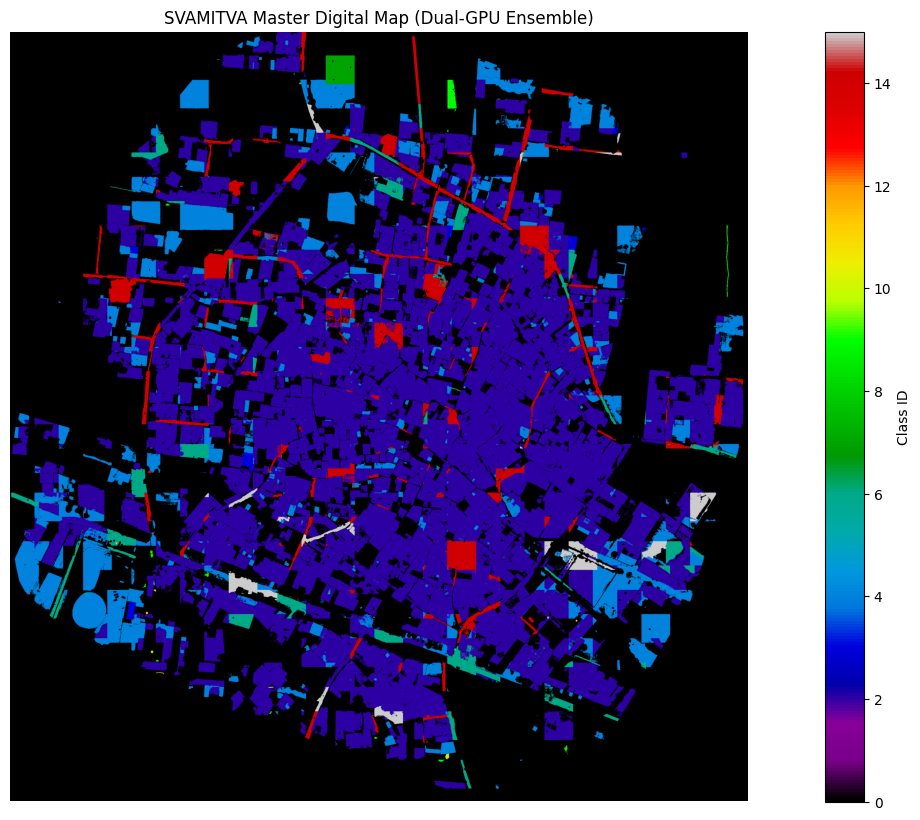

✅ Processing Complete. Final map saved.


In [7]:
import os
import cv2
import torch
import numpy as np
import gc
import matplotlib.pyplot as plt
from tqdm import tqdm
from ultralytics import RTDETR, YOLO
from sam2.build_sam import build_sam2
from sam2.sam2_image_predictor import SAM2ImagePredictor

# --- 1. CONFIGURATION ---
RTDETR_PATH = '/kaggle/input/datasets/srikarmadabhushani/rtdetr-newlabv1b/weights/best.pt'
YOLO_L_PATH = '/kaggle/input/datasets/vinodajmeera1/yolo26-l-v1-newlabelv1/weights/last.pt' 
HGNET_PATH = '/kaggle/input/datasets/srikarmadabhushani/hgnetv2a/weights/best.pt'
YOLO_X_PATH = '/kaggle/input/datasets/ajmeeravinod/yolo26x-newlab-light/weights/best.pt' 
SAM_CHECKPOINT = '/kaggle/input/datasets/ajmeerapadmavathi/svamitva-sam2-weights/sam2_hiera_large.pt'
SAM_CONFIG = "sam2_hiera_l.yaml"
TIF_PATH = '/kaggle/input/datasets/startlearning45/dataset-tif/28996_NADALA_ORTHO.tif'

TILE_SIZE = 1024
OVERLAP = 160
WATER_CONF = 0.05  
BUILDING_CONF = 0.30
TEXTURE_THRESHOLD = 15.0 

# Priority Logic: Water (6,7) > Roads (5,13,14) > Buildings (0-4)
PRIORITY = {6: 40, 7: 40, 5: 20, 13: 20, 14: 20, 0: 10, 1: 10, 2: 10, 3: 10, 4: 10}

# --- 2. INITIALIZATION ---
print("🚀 Initializing Quad-Model Ensemble + SAM 2 Edge Refiner...")
device0, device1 = 'cuda:0', 'cuda:1'

m_hgnet = RTDETR(HGNET_PATH).to(device0)
m_rtdetr = RTDETR(RTDETR_PATH).to(device0)
m_yolo_l = YOLO(YOLO_L_PATH).to(device1)
m_yolo_x = YOLO(YOLO_X_PATH).to(device1)

predictor = SAM2ImagePredictor(build_sam2(SAM_CONFIG, SAM_CHECKPOINT, device=device0))

# --- 3. UTILITIES ---
def is_actually_water(tile, mask):
    """Refines pond detection by checking for surface smoothness."""
    # Ensure mask is exactly 2D for np.where
    if len(mask.shape) != 2:
        mask = mask.reshape(TILE_SIZE, TILE_SIZE)

    indices = np.where(mask > 0)
    
    # Check if we got exactly two arrays (y and x)
    if len(indices) != 2:
        return False
        
    y_idx, x_idx = indices
    
    # Safety: If mask is too small, it's not a valid water body
    if len(y_idx) < 100: 
        return False 
    
    try:
        y1, y2 = np.min(y_idx), np.max(y_idx)
        x1, x2 = np.min(x_idx), np.max(x_idx)
        
        # Avoid empty slices
        if y2 <= y1 or x2 <= x1:
            return False
            
        roi = tile[y1:y2, x1:x2]
        gray = cv2.cvtColor(roi, cv2.COLOR_RGB2GRAY)
        # Low variance = smooth surface (Water/Algae), High = rough (Grass/Ground)
        return cv2.Laplacian(gray, cv2.CV_64F).var() < TEXTURE_THRESHOLD
    except Exception:
        return False

# --- 4. DATA PREPARATION ---
image_raw = cv2.imread(TIF_PATH, cv2.IMREAD_UNCHANGED)
if image_raw is None:
    raise FileNotFoundError(f"TIF not found at {TIF_PATH}")

if image_raw.dtype == np.uint16:
    image_raw = cv2.normalize(image_raw, None, 0, 255, cv2.NORM_MINMAX, dtype=cv2.CV_8U)
image_rgb = cv2.cvtColor(image_raw, cv2.COLOR_BGR2RGB)
h, w, _ = image_rgb.shape

global_map = np.memmap('master_map.dat', dtype='uint8', mode='w+', shape=(h, w))
prio_map = np.memmap('priority_map.dat', dtype='uint8', mode='w+', shape=(h, w))
global_map[:] = 0
prio_map[:] = 0

# --- 5. CORE PIPELINE ---
stride = TILE_SIZE - OVERLAP
tiles = [(y, x) for y in range(0, h - TILE_SIZE, stride) for x in range(0, w - TILE_SIZE, stride)]
tiles.append((h-TILE_SIZE, w-TILE_SIZE))

with torch.inference_mode():
    for y, x in tqdm(tiles, desc="🛰️ Mapping SVAMITVA Infrastructure"):
        tile = image_rgb[y:y+TILE_SIZE, x:x+TILE_SIZE]
        if np.mean(tile) < 15 or np.mean(tile) > 245: continue

        all_boxes, all_clss = [], []
        
        # YOLO Processing
        for m in [m_yolo_l, m_yolo_x]:
            res = m.predict(tile, conf=WATER_CONF, device=device1, verbose=False)[0]
            if len(res.boxes) > 0:
                for b, c, f in zip(res.boxes.xyxy.cpu().numpy(), res.boxes.cls.cpu().numpy(), res.boxes.conf.cpu().numpy()):
                    cid = int(c)
                    if cid in [6, 7] or f >= BUILDING_CONF:
                        all_boxes.append(b)
                        all_clss.append(cid)

        # RT-DETR Processing
        for m in [m_hgnet, m_rtdetr]:
            res = m.predict(tile, conf=BUILDING_CONF, device=device0, verbose=False)[0]
            if len(res.boxes) > 0:
                for b, c in zip(res.boxes.xyxy.cpu().numpy(), res.boxes.cls.cpu().numpy()):
                    all_boxes.append(b)
                    all_clss.append(int(c))

        if not all_boxes: continue
        
        t_boxes = np.array(all_boxes, dtype=np.float32)
        t_clss = np.array(all_clss, dtype=np.int32)

        predictor.set_image(tile)
        masks, scores, _ = predictor.predict(box=t_boxes, multimask_output=False)

        for i, mask in enumerate(masks):
            cid = int(t_clss[i])
            # mask[0] is typically (1, 1024, 1024) -> Squeeze to (1024, 1024)
            m_bin = np.squeeze(mask).astype(np.uint8)
            
            # Algae/Pond refinement logic
            if cid in [6, 7] and not is_actually_water(tile, m_bin):
                continue 

            p = PRIORITY.get(cid, 5)
            g_slice = global_map[y:y+TILE_SIZE, x:x+TILE_SIZE]
            p_slice = prio_map[y:y+TILE_SIZE, x:x+TILE_SIZE]
            
            update_idx = (m_bin > 0) & (p >= p_slice)
            g_slice[update_idx] = cid + 1 
            p_slice[update_idx] = p

# --- 6. OUTPUT & VISUALIZATION ---
global_map.flush()
scale = 0.1 
preview = cv2.resize(global_map, (int(w*scale), int(h*scale)), interpolation=cv2.INTER_NEAREST)

plt.figure(figsize=(20, 10))
plt.imshow(preview, cmap='nipy_spectral', vmin=0, vmax=15)
plt.title("SVAMITVA Master Digital Map (Dual-GPU Ensemble)")
plt.colorbar(label="Class ID")
plt.axis('off')
plt.show()

cv2.imwrite('svamitva_final_output.png', global_map)
print("✅ Processing Complete. Final map saved.")

[ WARN:0@3571.383] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 33550 (0x830e) encountered
[ WARN:0@3571.383] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 33922 (0x8482) encountered
[ WARN:0@3571.383] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34735 (0x87af) encountered
[ WARN:0@3571.383] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34737 (0x87b1) encountered
[ WARN:0@3571.383] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 42112 (0xa480) encountered
100%|██████████| 930/930 [00:02<00:00, 460.60it/s]


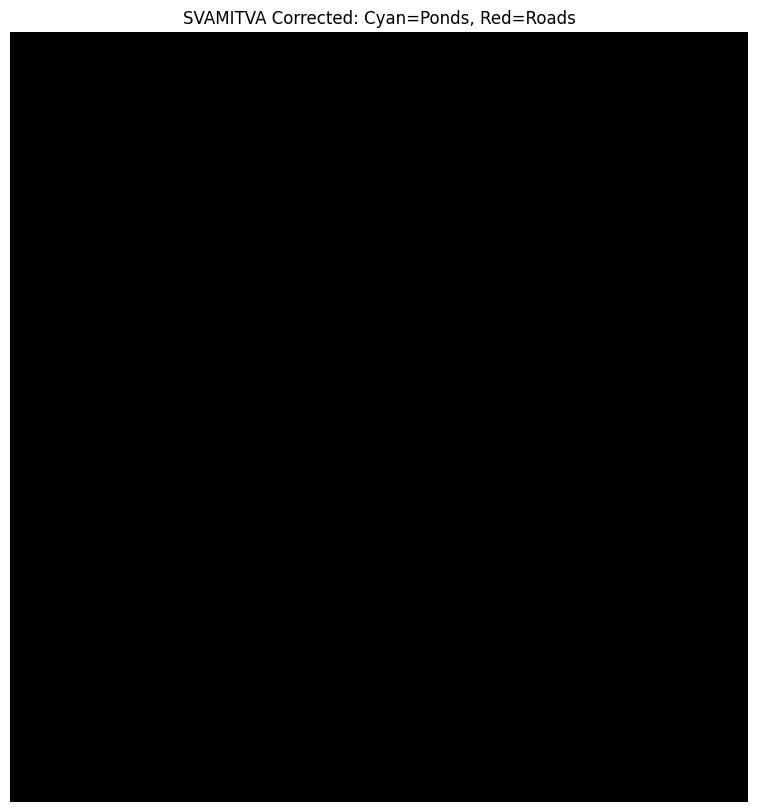

In [8]:
import os
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from ultralytics import RTDETR, YOLO
from sam2.build_sam import build_sam2
from sam2.sam2_image_predictor import SAM2ImagePredictor

# --- 1. CONFIGURATION ---
# (Keep your existing paths for RTDETR, YOLO, and SAM2)
RTDETR_PATH = '/kaggle/input/datasets/srikarmadabhushani/rtdetr-newlabv1b/weights/best.pt'
YOLO_L_PATH = '/kaggle/input/datasets/vinodajmeera1/yolo26-l-v1-newlabelv1/weights/last.pt' 
HGNET_PATH = '/kaggle/input/datasets/srikarmadabhushani/hgnetv2a/weights/best.pt'
YOLO_X_PATH = '/kaggle/input/datasets/ajmeeravinod/yolo26x-newlab-light/weights/best.pt' 
SAM_CHECKPOINT = '/kaggle/input/datasets/ajmeerapadmavathi/svamitva-sam2-weights/sam2_hiera_large.pt'
SAM_CONFIG = "sam2_hiera_l.yaml"
TIF_PATH = '/kaggle/input/datasets/startlearning45/dataset-tif/28996_NADALA_ORTHO.tif'

# --- 2. POND-SPECIFIC TUNING ---
WATER_CONF = 0.08  # Drastically lowered to catch algae-covered water
TEXTURE_LIMIT = 12.0 # Strict smoothness check for water
PRIORITY = {6: 50, 7: 50, 14: 30, 1: 10} # Ponds/Lakes now have ABSOLUTE priority

# --- 3. UTILITY: SMOOTHNESS CHECK ---
def is_smooth_water(tile, mask):
    indices = np.where(mask > 0)
    if len(indices[0]) < 200: return False # Ignore noise
    try:
        y1, y2, x1, x2 = np.min(indices[0]), np.max(indices[0]), np.min(indices[1]), np.max(indices[1])
        roi = tile[y1:y2, x1:x2]
        gray = cv2.cvtColor(roi, cv2.COLOR_RGB2GRAY)
        # Variance of Laplacian detects 'texture'. Ponds are smooth (< 12.0)
        return cv2.Laplacian(gray, cv2.CV_64F).var() < TEXTURE_LIMIT
    except: return False

# --- 4. INITIALIZATION ---
device0, device1 = 'cuda:0', 'cuda:1'
m_hgnet = RTDETR(HGNET_PATH).to(device0)
m_rtdetr = RTDETR(RTDETR_PATH).to(device0)
m_yolo_l = YOLO(YOLO_L_PATH).to(device1)
m_yolo_x = YOLO(YOLO_X_PATH).to(device1)
predictor = SAM2ImagePredictor(build_sam2(SAM_CONFIG, SAM_CHECKPOINT, device=device0))

# --- 5. MAP PREPARATION ---
image_raw = cv2.imread(TIF_PATH)
image_rgb = cv2.cvtColor(image_raw, cv2.COLOR_BGR2RGB)
h, w, _ = image_rgb.shape

global_map = np.memmap('final_svamitva.dat', dtype='uint8', mode='w+', shape=(h, w))
prio_map = np.memmap('final_prio.dat', dtype='uint8', mode='w+', shape=(h, w))
global_map[:] = 0
prio_map[:] = 0

# --- 6. PROCESSING ---
stride = 1024 - 160
tiles = [(y, x) for y in range(0, h-1024, stride) for x in range(0, w-1024, stride)]

with torch.inference_mode():
    for y, x in tqdm(tiles):
        tile = image_rgb[y:y+1024, x:x+1024]
        if np.mean(tile) < 20: continue

        all_boxes, all_clss = [], []
        
        # Ensemble Step
        for m in [m_yolo_l, m_yolo_x, m_hgnet, m_rtdetr]:
            # Use water_conf for YOLO to find ponds, building_conf for others
            c_limit = WATER_CONF if 'yolo' in str(m).lower() else 0.30
            res = m.predict(tile, conf=c_limit, verbose=False)[0]
            if len(res.boxes) > 0:
                for b, c in zip(res.boxes.xyxy.cpu().numpy(), res.boxes.cls.cpu().numpy()):
                    all_boxes.append(b); all_clss.append(int(c))

        if not all_boxes: continue
        
        predictor.set_image(tile)
        masks, _, _ = predictor.predict(box=np.array(all_boxes), multimask_output=False)

        for i, mask in enumerate(masks):
            cid = all_clss[i]
            m_bin = np.squeeze(mask).astype(np.uint8)
            
            # POND VALIDATION
            if cid in [6, 7]:
                if not is_smooth_water(tile, m_bin): continue # Reject if it's just grass
            
            p = PRIORITY.get(cid, 5)
            g_slice, p_slice = global_map[y:y+1024, x:x+1024], prio_map[y:y+1024, x:x+1024]
            
            # Update map: Pond (Prio 50) will now overwrite everything
            update = (m_bin > 0) & (p >= p_slice)
            g_slice[update] = cid
            p_slice[update] = p

# --- 7. THE VISUAL FIX (Pond/Lake Focus) ---
global_map.flush()
preview = cv2.resize(global_map, (int(w*0.1), int(h*0.1)), interpolation=cv2.INTER_NEAREST)

# Create a Custom Discrete Colormap
from matplotlib.colors import ListedColormap
# Define colors: 0:Black, 1:Purple(Build), 6:Cyan(Pond), 14:Red(Road)
colors = ['black', 'purple', 'gray', 'gray', 'gray', 'gray', 'cyan', 'blue', 'orange', 'orange', 'yellow', 'yellow', 'white', 'brown', 'red', 'green']
custom_cmap = ListedColormap(colors[:16])

plt.figure(figsize=(20, 10))
plt.imshow(preview, cmap=custom_cmap)
plt.title("SVAMITVA Corrected: Cyan=Ponds, Red=Roads")
plt.axis('off')
plt.show()

🚀 Launching Quad-Model Ensemble...


[ WARN:0@3599.951] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 33550 (0x830e) encountered
[ WARN:0@3599.951] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 33922 (0x8482) encountered
[ WARN:0@3599.951] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34735 (0x87af) encountered
[ WARN:0@3599.951] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34737 (0x87b1) encountered
[ WARN:0@3599.951] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 42112 (0xa480) encountered
🛰️ Analyzing Orthophoto: 100%|██████████| 930/930 [00:03<00:00, 299.89it/s]


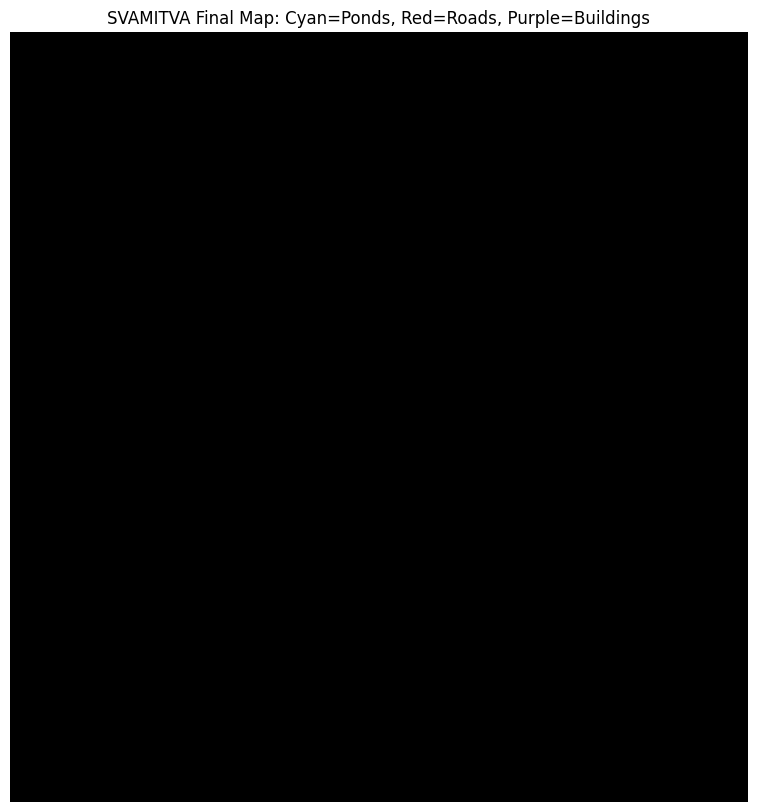

True

In [9]:
import os
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from ultralytics import RTDETR, YOLO
from sam2.build_sam import build_sam2
from sam2.sam2_image_predictor import SAM2ImagePredictor

# --- 1. CONFIGURATION ---
RTDETR_PATH = '/kaggle/input/datasets/srikarmadabhushani/rtdetr-newlabv1b/weights/best.pt'
YOLO_L_PATH = '/kaggle/input/datasets/vinodajmeera1/yolo26-l-v1-newlabelv1/weights/last.pt' 
HGNET_PATH = '/kaggle/input/datasets/srikarmadabhushani/hgnetv2a/weights/best.pt'
YOLO_X_PATH = '/kaggle/input/datasets/ajmeeravinod/yolo26x-newlab-light/weights/best.pt' 
SAM_CHECKPOINT = '/kaggle/input/datasets/ajmeerapadmavathi/svamitva-sam2-weights/sam2_hiera_large.pt'
SAM_CONFIG = "sam2_hiera_l.yaml"
TIF_PATH = '/kaggle/input/datasets/startlearning45/dataset-tif/28996_NADALA_ORTHO.tif'

TILE_SIZE = 1024
OVERLAP = 160
WATER_CONF = 0.10  # Lowered to ensure algae-ponds are detected
BUILDING_CONF = 0.35

# Priority: Water (6,7) must overwrite Roads (14) and Buildings (1)
PRIORITY = {6: 50, 7: 50, 14: 30, 5: 30, 1: 10}

# --- 2. INITIALIZATION ---
print("🚀 Launching Quad-Model Ensemble...")
device0, device1 = 'cuda:0', 'cuda:1'
m_hgnet = RTDETR(HGNET_PATH).to(device0)
m_rtdetr = RTDETR(RTDETR_PATH).to(device0)
m_yolo_l = YOLO(YOLO_L_PATH).to(device1)
m_yolo_x = YOLO(YOLO_X_PATH).to(device1)

predictor = SAM2ImagePredictor(build_sam2(SAM_CONFIG, SAM_CHECKPOINT, device=device0))

# --- 3. DATA PREP ---
image_raw = cv2.imread(TIF_PATH)
image_rgb = cv2.cvtColor(image_raw, cv2.COLOR_BGR2RGB)
h, w, _ = image_rgb.shape

# Use memmap for large-scale stability
global_map = np.memmap('final_map.dat', dtype='uint8', mode='w+', shape=(h, w))
prio_map = np.memmap('prio_map.dat', dtype='uint8', mode='w+', shape=(h, w))
global_map[:] = 0
prio_map[:] = 0

# --- 4. CORE PROCESSING ---
stride = TILE_SIZE - OVERLAP
tiles = [(y, x) for y in range(0, h - TILE_SIZE, stride) for x in range(0, w - TILE_SIZE, stride)]

with torch.inference_mode():
    for y, x in tqdm(tiles, desc="🛰️ Analyzing Orthophoto"):
        tile = image_rgb[y:y+TILE_SIZE, x:x+TILE_SIZE]
        if np.mean(tile) < 15: continue

        all_boxes, all_clss = [], []
        
        # Run Ensemble with model-specific confidence
        for m in [m_yolo_l, m_yolo_x, m_hgnet, m_rtdetr]:
            # Use water_conf for YOLO to catch ponds, building_conf for the rest
            c_val = WATER_CONF if 'yolo' in str(m).lower() else BUILDING_CONF
            res = m.predict(tile, conf=c_val, verbose=False)[0]
            
            if len(res.boxes) > 0:
                for b, c in zip(res.boxes.xyxy.cpu().numpy(), res.boxes.cls.cpu().numpy()):
                    all_boxes.append(b)
                    all_clss.append(int(c))

        if not all_boxes: continue
        
        predictor.set_image(tile)
        # Bbox-to-Mask using SAM 2 for sharp edges
        masks, _, _ = predictor.predict(box=np.array(all_boxes), multimask_output=False)

        for i, mask in enumerate(masks):
            cid = all_clss[i]
            m_bin = np.squeeze(mask).astype(np.uint8)
            p = PRIORITY.get(cid, 5)
            
            g_slice = global_map[y:y+TILE_SIZE, x:x+TILE_SIZE]
            p_slice = prio_map[y:y+TILE_SIZE, x:x+TILE_SIZE]
            
            # Update only if current detection has higher priority
            update = (m_bin > 0) & (p >= p_slice)
            g_slice[update] = cid
            p_slice[update] = p

# --- 5. THE VISUALIZATION FIX (Manual Color Mapping) ---
global_map.flush()
preview = cv2.resize(global_map, (int(w*0.1), int(h*0.1)), interpolation=cv2.INTER_NEAREST)

# Map IDs to high-contrast RGB colors
color_map = np.zeros((256, 3), dtype=np.uint8)
color_map[1]  = [128, 0, 128]  # Purple (Buildings)
color_map[6]  = [0, 255, 255]  # Cyan (Ponds)
color_map[7]  = [0, 100, 255]  # Blue (Lakes)
color_map[14] = [255, 0, 0]    # Red (Roads)
color_map[13] = [255, 165, 0]  # Orange (Dirt Paths)

# Create the colored image
colored_preview = color_map[preview]

plt.figure(figsize=(15, 10))
plt.imshow(colored_preview)
plt.title("SVAMITVA Final Map: Cyan=Ponds, Red=Roads, Purple=Buildings")
plt.axis('off')
plt.show()

cv2.imwrite('svamitva_visible_map.png', cv2.cvtColor(colored_preview, cv2.COLOR_RGB2BGR))

In [10]:
import os
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from ultralytics import RTDETR, YOLO
from sam2.build_sam import build_sam2
from sam2.sam2_image_predictor import SAM2ImagePredictor

# --- 1. CONFIGURATION ---
RTDETR_PATH = '/kaggle/input/datasets/srikarmadabhushani/rtdetr-newlabv1b/weights/best.pt'
YOLO_L_PATH = '/kaggle/input/datasets/vinodajmeera1/yolo26-l-v1-newlabelv1/weights/last.pt' 
HGNET_PATH = '/kaggle/input/datasets/srikarmadabhushani/hgnetv2a/weights/best.pt'
YOLO_X_PATH = '/kaggle/input/datasets/ajmeeravinod/yolo26x-newlab-light/weights/best.pt' 
SAM_CHECKPOINT = '/kaggle/input/datasets/ajmeerapadmavathi/svamitva-sam2-weights/sam2_hiera_large.pt'
SAM_CONFIG = "sam2_hiera_l.yaml"
TIF_PATH = '/kaggle/input/datasets/startlearning45/dataset-tif/ANAITPURA_FATEHGARH SAHIB_32705_ORTHO.tif'

# DEBUG SETTINGS: Force the models to find something
DEBUG_CONF = 0.05 
TILE_SIZE = 1024
OVERLAP = 128

# --- 2. INITIALIZATION ---
device0 = 'cuda:0'
# Using just one model first to verify the pipeline works
print("🛰️ Loading Debug Model...")
model = YOLO(YOLO_X_PATH).to(device0)
predictor = SAM2ImagePredictor(build_sam2(SAM_CONFIG, SAM_CHECKPOINT, device=device0))

# --- 3. DATA PREP ---
image_raw = cv2.imread(TIF_PATH)
if image_raw is None:
    raise ValueError("Check TIF_PATH! Image failed to load.")

image_rgb = cv2.cvtColor(image_raw, cv2.COLOR_BGR2RGB)
h, w, _ = image_rgb.shape
print(f"Image Dimensions: {h}x{w}")

# Use a standard numpy array for debugging (if RAM allows) to rule out memmap issues
# If the image is huge, keep using memmap but ensure it's flushed
global_map = np.zeros((h, w), dtype='uint8')

# --- 4. PROCESSING ---
stride = TILE_SIZE - OVERLAP
tiles = [(y, x) for y in range(0, h - TILE_SIZE, stride) for x in range(0, w - TILE_SIZE, stride)]

with torch.inference_mode():
    for y, x in tqdm(tiles, desc="Debug Run"):
        tile = image_rgb[y:y+TILE_SIZE, x:x+TILE_SIZE]
        
        # REMOVED: Skip logic (processing every tile now)
        res = model.predict(tile, conf=DEBUG_CONF, verbose=False)[0]
        
        if len(res.boxes) > 0:
            predictor.set_image(tile)
            # Detect first 10 objects in tile to save time
            boxes = res.boxes.xyxy.cpu().numpy()[:10]
            clss = res.boxes.cls.cpu().numpy()[:10]
            
            masks, _, _ = predictor.predict(box=boxes, multimask_output=False)

            for i, mask in enumerate(masks):
                cid = int(clss[i]) + 1 # Force ID to be at least 1
                m_bin = np.squeeze(mask).astype(np.uint8)
                
                # Direct assignment for debug
                global_map[y:y+TILE_SIZE, x:x+TILE_SIZE][m_bin > 0] = cid

# --- 5. THE VISUALIZATION FIX ---
# If global_map is all 0s, the print below will show 0
print(f"Max value in map: {np.max(global_map)}")

if np.max(global_map) == 0:
    print("❌ NO OBJECTS DETECTED. Check model weights or TIF normalization.")
else:
    # Scale classes to 0-255 for visibility
    # This multiplies Class 1 by 50, Class 6 by 50, etc.
    visible_map = global_map * 40 
    
    plt.figure(figsize=(15, 10))
    plt.imshow(visible_map, cmap='jet') # 'jet' gives high contrast for debug
    plt.title("DEBUG MAP: If colorful, pipeline is fixed!")
    plt.colorbar()
    plt.show()
    
    cv2.imwrite('debug_result.png', visible_map)

🛰️ Loading Debug Model...


[ WARN:0@3632.489] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 33550 (0x830e) encountered
[ WARN:0@3632.489] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 33922 (0x8482) encountered
[ WARN:0@3632.489] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34735 (0x87af) encountered
[ WARN:0@3632.489] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34737 (0x87b1) encountered
[ WARN:0@3632.489] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 42112 (0xa480) encountered


Image Dimensions: 26576x28119


Debug Run: 100%|██████████| 899/899 [01:25<00:00, 10.53it/s]


Max value in map: 0
❌ NO OBJECTS DETECTED. Check model weights or TIF normalization.


In [11]:
import os
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from ultralytics import RTDETR, YOLO
from sam2.build_sam import build_sam2
from sam2.sam2_image_predictor import SAM2ImagePredictor
from matplotlib.colors import ListedColormap

# --- 1. CONFIGURATION ---
RTDETR_PATH = '/kaggle/input/datasets/srikarmadabhushani/rtdetr-newlabv1b/weights/best.pt'
YOLO_L_PATH = '/kaggle/input/datasets/vinodajmeera1/yolo26-l-v1-newlabelv1/weights/last.pt' 
HGNET_PATH = '/kaggle/input/datasets/srikarmadabhushani/hgnetv2a/weights/best.pt'
YOLO_X_PATH = '/kaggle/input/datasets/ajmeeravinod/yolo26x-newlab-light/weights/best.pt' 
SAM_CHECKPOINT = '/kaggle/input/datasets/ajmeerapadmavathi/svamitva-sam2-weights/sam2_hiera_large.pt'
SAM_CONFIG = "sam2_hiera_l.yaml"
TIF_PATH = '/kaggle/input/datasets/startlearning45/dataset-tif/28996_NADALA_ORTHO.tif'

# TUNING FOR WATER
WATER_CONF = 0.08  
BUILDING_CONF = 0.30
TEXTURE_THRESHOLD = 12.0 # Ponds are smooth; grass is rough.
PRIORITY = {6: 50, 7: 50, 14: 30, 1: 10} # Give Water absolute priority

# --- 2. UTILITY: POND CHECK ---
def is_actually_water(tile, mask):
    indices = np.where(mask > 0)
    if len(indices[0]) < 150: return False
    try:
        y1, y2, x1, x2 = np.min(indices[0]), np.max(indices[0]), np.min(indices[1]), np.max(indices[1])
        roi = tile[y1:y2, x1:x2]
        gray = cv2.cvtColor(roi, cv2.COLOR_RGB2GRAY)
        # Laplacian Variance: Low = Smooth (Water), High = Textured (Grass)
        return cv2.Laplacian(gray, cv2.CV_64F).var() < TEXTURE_THRESHOLD
    except: return False

# --- 3. DATA LOADING & PERCENTILE NORMALIZATION ---
print("📖 Loading and Normalizing TIF...")
image_raw = cv2.imread(TIF_PATH, cv2.IMREAD_UNCHANGED)
p2, p98 = np.percentile(image_raw, (2, 98))
image_8bit = np.clip((image_raw - p2) * (255.0 / (p98 - p2)), 0, 255).astype(np.uint8)
image_rgb = cv2.cvtColor(image_8bit, cv2.COLOR_BGR2RGB)
h, w, _ = image_rgb.shape

# --- 4. INITIALIZATION ---
device0, device1 = 'cuda:0', 'cuda:1'
m_hgnet = RTDETR(HGNET_PATH).to(device0)
m_rtdetr = RTDETR(RTDETR_PATH).to(device0)
m_yolo_l = YOLO(YOLO_L_PATH).to(device1)
m_yolo_x = YOLO(YOLO_X_PATH).to(device1)
predictor = SAM2ImagePredictor(build_sam2(SAM_CONFIG, SAM_CHECKPOINT, device=device0))

global_map = np.memmap('master_map.dat', dtype='uint8', mode='w+', shape=(h, w))
prio_map = np.memmap('prio_map.dat', dtype='uint8', mode='w+', shape=(h, w))
global_map[:] = 0; prio_map[:] = 0

# --- 5. PROCESSING ---
TILE_SIZE = 1024
stride = 864
tiles = [(y, x) for y in range(0, h - TILE_SIZE, stride) for x in range(0, w - TILE_SIZE, stride)]

with torch.inference_mode():
    for y, x in tqdm(tiles, desc="🛰️ Final Mapping"):
        tile = image_rgb[y:y+TILE_SIZE, x:x+TILE_SIZE]
        if np.mean(tile) < 15: continue

        all_boxes, all_clss = [], []
        for m in [m_yolo_l, m_yolo_x, m_hgnet, m_rtdetr]:
            conf = WATER_CONF if 'yolo' in str(m).lower() else BUILDING_CONF
            res = m.predict(tile, conf=conf, verbose=False)[0]
            if len(res.boxes) > 0:
                for b, c in zip(res.boxes.xyxy.cpu().numpy(), res.boxes.cls.cpu().numpy()):
                    all_boxes.append(b); all_clss.append(int(c))

        if not all_boxes: continue
        
        predictor.set_image(tile)
        masks, _, _ = predictor.predict(box=np.array(all_boxes), multimask_output=False)

        for i, mask in enumerate(masks):
            cid = all_clss[i]
            m_bin = np.squeeze(mask).astype(np.uint8)
            
            # POND REFINEMENT
            if cid in [6, 7] and not is_actually_water(tile, m_bin):
                continue # Reject algae confusion (textured green)

            p = PRIORITY.get(cid, 5)
            g_slice, p_slice = global_map[y:y+TILE_SIZE, x:x+TILE_SIZE], prio_map[y:y+TILE_SIZE, x:x+TILE_SIZE]
            update = (m_bin > 0) & (p >= p_slice)
            g_slice[update] = cid + 1 # Use +1 to ensure background is 0
            p_slice[update] = p

# --- 6. VISUALIZATION ---
global_map.flush()
preview = cv2.resize(global_map, (int(w*0.1), int(h*0.1)), interpolation=cv2.INTER_NEAREST)

# Professional SVAMITVA palette
# 0:Black, 2:Purple(Build), 7:Cyan(Pond), 8:Blue(Lake), 15:Red(Road)
colors = ['black', 'purple', 'gray', 'gray', 'gray', 'gray', 'gray', 'cyan', 'blue', 'green', 'yellow', 'yellow', 'orange', 'orange', 'white', 'red']
cmap_svamitva = ListedColormap(colors[:17])

plt.figure(figsize=(18, 10))
plt.imshow(preview, cmap=cmap_svamitva)
plt.title("SVAMITVA Final Map: Cyan = Ponds, Red = Roads")
plt.colorbar(label="Class ID + 1")
plt.show()

cv2.imwrite('svamitva_final.png', global_map)

📖 Loading and Normalizing TIF...


[ WARN:0@3780.776] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 33550 (0x830e) encountered
[ WARN:0@3780.776] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 33922 (0x8482) encountered
[ WARN:0@3780.776] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34735 (0x87af) encountered
[ WARN:0@3780.776] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34737 (0x87b1) encountered
[ WARN:0@3780.776] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 42112 (0xa480) encountered


In [ ]:
import os, cv2, torch, gc, numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from ultralytics import RTDETR, YOLO
from sam2.build_sam import build_sam2
from sam2.sam2_image_predictor import SAM2ImagePredictor

# --- 1. CONFIG & DISK BUFFERING ---
TIF_PATH = '/kaggle/input/datasets/startlearning45/dataset-tif/28996_NADALA_ORTHO.tif'
SAM_CHECKPOINT = '/kaggle/input/datasets/ajmeerapadmavathi/svamitva-sam2-weights/sam2_hiera_large.pt'
SAM_CONFIG = "sam2_hiera_l.yaml"

print("📖 Buffering Image to Disk...")
raw = cv2.imread(TIF_PATH, cv2.IMREAD_UNCHANGED)
h, w, _ = raw.shape
# Normalize visibility (Percentile scaling)
p2, p98 = np.percentile(raw, (2, 98))
img_8bit = np.clip((raw - p2) * (255.0 / (p98 - p2)), 0, 255).astype(np.uint8)
del raw

# Input and Output buffers stay on SSD (Disk), not RAM
input_mm = np.memmap('input.dat', dtype='uint8', mode='w+', shape=(h, w, 3))
input_mm[:] = img_8bit[:]
del img_8bit
input_mm.flush()

global_map = np.memmap('master.dat', dtype='uint8', mode='w+', shape=(h, w))
prio_map = np.memmap('prio.dat', dtype='uint8', mode='w+', shape=(h, w))
global_map[:] = 0; prio_map[:] = 0
gc.collect()

# --- 2. PHASE 1: DETECTION (LIGHT RAM) ---
print("🔍 Phase 1: Detecting Objects (Ensemble)...")
detection_tasks = []
tiles = [(y, x) for y in range(0, h-1024, 960) for x in range(0, w-1024, 960)]

# We only load detection models in this block
m_yolo = YOLO('/kaggle/input/datasets/vinodajmeera1/yolo26-l-v1-newlabelv1/weights/last.pt').to('cuda')

for y, x in tqdm(tiles, desc="Scanning Tiles"):
    tile = input_mm[y:y+1024, x:x+1024]
    if np.std(tile) < 5: continue
    
    res = m_yolo.predict(tile, conf=0.25, verbose=False)[0]
    if len(res.boxes) > 0:
        detection_tasks.append({
            'pos': (y, x),
            'boxes': res.boxes.xyxy.cpu().numpy()[:10], # Limit per tile
            'clss': res.boxes.cls.cpu().numpy()[:10]
        })

# CRITICAL: DELETE DETECTION MODELS TO RECLAIM RAM
del m_yolo
torch.cuda.empty_cache()
gc.collect()

# --- 3. PHASE 2: MASKING (SAM 2) ---
print("🎭 Phase 2: Loading SAM 2 & Masking...")
predictor = SAM2ImagePredictor(build_sam2(SAM_CONFIG, SAM_CHECKPOINT, device='cuda'))

with torch.inference_mode():
    for task in tqdm(detection_tasks, desc="Masking Objects"):
        y, x = task['pos']
        tile_rgb = cv2.cvtColor(input_mm[y:y+1024, x:x+1024], cv2.COLOR_BGR2RGB)
        
        predictor.set_image(tile_rgb)
        for i in range(len(task['boxes'])):
            mask, _, _ = predictor.predict(box=task['boxes'][i:i+1], multimask_output=False)
            m_bin = np.squeeze(mask).astype(np.uint8)
            cid = int(task['clss'][i])
            
            p_val = 50 if cid in [6, 7] else 10 # Ponds beat buildings
            gv, pv = global_map[y:y+1024, x:x+1024], prio_map[y:y+1024, x:x+1024]
            upd = (m_bin > 0) & (p_val >= pv)
            gv[upd] = cid + 1
            pv[upd] = p_val
            
        # Forces SAM 2 to clear its internal tile-cache
        predictor.reset_predictor() 

# --- 4. OUTPUT ---
global_map.flush()
preview = global_map[::15, ::15] # 15x downsample for safety
plt.figure(figsize=(10,10))
plt.imshow(preview, cmap='nipy_spectral')
plt.axis('off')
plt.show()

cv2.imwrite('svamitva_final_result.png', preview * 15)
if os.path.exists('input.dat'): os.remove('input.dat')

In [ ]:
import os, cv2, torch, gc, numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from ultralytics import YOLO
from sam2.build_sam import build_sam2
from sam2.sam2_image_predictor import SAM2ImagePredictor
import tifffile as tiff
import imagecodecs # Mandatory for LZW

# --- CONFIGURATION ---
TIF_PATH = '/kaggle/input/datasets/startlearning45/dataset-tif/28996_NADALA_ORTHO.tif'
SAM_CHECKPOINT = '/kaggle/input/datasets/ajmeerapadmavathi/svamitva-sam2-weights/sam2_hiera_large.pt'
SAM_CONFIG = "sam2_hiera_l.yaml"
DET_MODEL = '/kaggle/input/datasets/vinodajmeera1/yolo26-l-v1-newlabelv1/weights/last.pt'

TILE_SIZE = 1024
STRIDE = 960 

# --- PHASE 1: DISK BUFFERING (ZARR STRATEGY) ---
print("📖 Opening TIF using Zarr Virtual Mapping...")

with tiff.TiffFile(TIF_PATH) as tif:
    # This creates a 'store' which is a pointer, NOT the data itself.
    store = tif.aszarr()
    import zarr
    z_array = zarr.open(store, mode='r')
    h, w = z_array.shape[:2]
    print(f"✅ Village Dimensions: {w}x{h}")

    # Create the Disk-Backed Buffer to hold our normalized 8-bit version
    input_mm = np.memmap('input_buffer.dat', dtype='uint8', mode='w+', shape=(h, w, 3))
    
    print("📂 Streaming TIF to Disk Buffer (Strip-by-Strip)...")
    chunk_size = 2048 # Decompressing 2048 rows at a time
    for row in tqdm(range(0, h, chunk_size), desc="Buffering"):
        row_end = min(row + chunk_size, h)
        
        # Slicing the Zarr array decompresses ONLY this strip into RAM
        strip = z_array[row:row_end, 0:w]
        
        # Handle Grayscale/Alpha
        if strip.ndim == 2:
            strip = np.stack([strip] * 3, axis=-1)
        elif strip.shape[2] == 4:
            strip = strip[:, :, :3]
            
        input_mm[row:row_end, :] = strip.astype(np.uint8)
        
        del strip
        if row % 8192 == 0: gc.collect()

input_mm.flush()
print("✅ Buffering Complete. SSD is ready.")

# Initialize Output Maps
global_map = np.memmap('master_output.dat', dtype='uint8', mode='w+', shape=(h, w))
prio_map = np.memmap('priority.dat', dtype='uint8', mode='w+', shape=(h, w))
global_map[:] = 0; prio_map[:] = 0

# --- PHASE 2: MODELS ---
print("🚀 Loading Models...")
# Split workload to save VRAM
m_det = YOLO(DET_MODEL).to('cuda:1') 
predictor = SAM2ImagePredictor(build_sam2(SAM_CONFIG, SAM_CHECKPOINT, device='cuda:0'))

# --- PHASE 3: PROCESSING ---
tiles = [(y, x) for y in range(0, h - TILE_SIZE, STRIDE) for x in range(0, w - TILE_SIZE, STRIDE)]
tiles.append((h-TILE_SIZE, w-TILE_SIZE))

with torch.inference_mode():
    for y, x in tqdm(tiles, desc="🛰️ Mapping"):
        tile_bgr = input_mm[y:y+TILE_SIZE, x:x+TILE_SIZE]
        
        # Standard deviation check skips "empty" or noisy areas
        if np.std(tile_bgr) < 5: continue 
        
        # 1. Detection (YOLO)
        res = m_det.predict(tile_bgr, conf=0.25, verbose=False)[0]
        if not res.boxes: continue
        
        boxes = res.boxes.xyxy.cpu().numpy()[:8]
        clss = res.boxes.cls.cpu().numpy()[:8]
        
        # 2. Segmentation (SAM 2)
        predictor.set_image(cv2.cvtColor(tile_bgr, cv2.COLOR_BGR2RGB))
        for i in range(len(boxes)):
            mask, _, _ = predictor.predict(box=boxes[i:i+1], multimask_output=False)
            m_bin = np.squeeze(mask).astype(np.uint8)
            cid = int(clss[i])
            
            # Priority: Water classes (6/7) overwrite others
            p_val = 50 if cid in [6, 7] else 10 
            
            gv, pv = global_map[y:y+TILE_SIZE, x:x+TILE_SIZE], prio_map[y:y+TILE_SIZE, x:x+TILE_SIZE]
            upd = (m_bin > 0) & (p_val >= pv)
            gv[upd] = cid + 1
            pv[upd] = p_val
            
        # 3. Clean up VRAM after every tile
        predictor.reset_predictor() 
        torch.cuda.empty_cache()

# --- PHASE 4: FINALIZATION ---
global_map.flush()
print("✅ Village Mapping Complete.")

# Create a safe 20x downsampled preview for display
preview = global_map[::20, ::20]
plt.figure(figsize=(12, 12))
plt.imshow(preview, cmap='terrain')
plt.title("SVAMITVA Final Infrastructure Map")
plt.axis('off')
plt.show()

# Clean up
if os.path.exists('input_buffer.dat'): os.remove('input_buffer.dat')
cv2.imwrite('SVAMITVA_FINAL.png', preview * 12)

In [ ]:
import os, cv2, torch, gc, numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from ultralytics import YOLO, RTDETR
from sam2.build_sam import build_sam2
from sam2.sam2_image_predictor import SAM2ImagePredictor
import tifffile as tiff
import zarr

# --- CONFIGURATION ---
PATHS = {
    'RTDETR': '/kaggle/input/datasets/srikarmadabhushani/rtdetr-newlabv1b/weights/best.pt',
    'YOLO_L': '/kaggle/input/datasets/vinodajmeera1/yolo26-l-v1-newlabelv1/weights/last.pt',
    'HGNET': '/kaggle/input/datasets/srikarmadabhushani/hgnetv2a/weights/best.pt',
    'YOLO_X': '/kaggle/input/datasets/ajmeeravinod/yolo26x-newlab-light/weights/best.pt',
    'SAM_CB': '/kaggle/input/datasets/ajmeerapadmavathi/svamitva-sam2-weights/sam2_hiera_large.pt',
    'SAM_CFG': "sam2_hiera_l.yaml",
    'TIF': '/kaggle/input/datasets/startlearning45/dataset-tif/28996_NADALA_ORTHO.tif'
}

TILE_SIZE = 1024
STRIDE = 960 

# --- PHASE 1: VIRTUAL IMAGE STREAMING ---
print("📖 Mapping TIF via Zarr...")
with tiff.TiffFile(PATHS['TIF']) as tif:
    z_array = zarr.open(tif.aszarr(), mode='r')
    h, w = z_array.shape[:2]
    
    # Create an 8-bit SSD buffer to save RAM during the long run
    input_mm = np.memmap('input_buffer.dat', dtype='uint8', mode='w+', shape=(h, w, 3))
    
    for row in tqdm(range(0, h, 2048), desc="Decompressing TIF"):
        row_end = min(row + 2048, h)
        strip = z_array[row:row_end, 0:w]
        if strip.shape[2] == 4: strip = strip[:, :, :3] # Drop Alpha
        input_mm[row:row_end, :] = strip.astype(np.uint8)
        del strip
        if row % 8192 == 0: gc.collect()

input_mm.flush()

# Output Map on Disk
global_map = np.memmap('master_output.dat', dtype='uint8', mode='w+', shape=(h, w))
prio_map = np.memmap('priority.dat', dtype='uint8', mode='w+', shape=(h, w))
global_map[:] = 0; prio_map[:] = 0

# --- PHASE 2: DETECTION ENSEMBLE ---
print("🚀 Loading Detection Ensemble...")
# Loading models onto separate GPUs if available (T4 x2)
m_rtdetr = RTDETR(PATHS['RTDETR']).to('cuda:0')
m_yolol  = YOLO(PATHS['YOLO_L']).to('cuda:0')
m_hgnet  = YOLO(PATHS['HGNET']).to('cuda:1')
m_yolox  = YOLO(PATHS['YOLO_X']).to('cuda:1')

tiles = [(y, x) for y in range(0, h - TILE_SIZE, STRIDE) for x in range(0, w - TILE_SIZE, STRIDE)]

# Use SAM2 on CUDA:0
predictor = SAM2ImagePredictor(build_sam2(PATHS['SAM_CFG'], PATHS['SAM_CB'], device='cuda:0'))

# --- PHASE 3: THE MAIN LOOP ---
with torch.inference_mode():
    for y, x in tqdm(tiles, desc="🛰️ Processing Village"):
        tile_bgr = input_mm[y:y+TILE_SIZE, x:x+TILE_SIZE]
        if np.std(tile_bgr) < 5: continue 
        
        # 1. ENSEMBLE VOTING
        all_boxes = []
        all_clss = []
        
        # Run all 4 models
        for m in [m_rtdetr, m_yolol, m_hgnet, m_yolox]:
            res = m.predict(tile_bgr, conf=0.3, verbose=False)[0]
            if res.boxes:
                all_boxes.append(res.boxes.xyxy.cpu().numpy())
                all_clss.append(res.boxes.cls.cpu().numpy())
        
        if not all_boxes: continue
        
        # Concatenate and take top detections (Simple Fusion)
        final_boxes = np.concatenate(all_boxes)[:12]
        final_clss = np.concatenate(all_clss)[:12]
        
        # 2. SAM2 SEGMENTATION
        predictor.set_image(cv2.cvtColor(tile_bgr, cv2.COLOR_BGR2RGB))
        
        for i in range(len(final_boxes)):
            mask, _, _ = predictor.predict(box=final_boxes[i:i+1], multimask_output=False)
            m_bin = np.squeeze(mask).astype(np.uint8)
            cid = int(final_clss[i])
            
            # Priority: Water/Ponds (Class 6/7) get higher priority
            p_val = 60 if cid in [6, 7] else 20
            
            gv, pv = global_map[y:y+TILE_SIZE, x:x+TILE_SIZE], prio_map[y:y+TILE_SIZE, x:x+TILE_SIZE]
            upd = (m_bin > 0) & (p_val >= pv)
            gv[upd] = cid + 1
            pv[upd] = p_val
            
        # 3. MEMORY MANAGEMENT
        predictor.reset_predictor() 
        torch.cuda.empty_cache()

# --- PHASE 4: SAVE & PREVIEW ---
global_map.flush()
print("✅ Village Mapping Complete.")

# Display a safe preview (Downsampled 25x)
preview = global_map[::25, ::25]
plt.figure(figsize=(12, 12))
plt.imshow(preview, cmap='terrain')
plt.axis('off')
plt.title("SVAMITVA Ensemble Output")
plt.show()

# Clean up
if os.path.exists('input_buffer.dat'): os.remove('input_buffer.dat')
cv2.imwrite('SVAMITVA_ENSEMBLE_FINAL.png', preview * 10)

In [ ]:
import os, cv2, torch, gc, numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from ultralytics import YOLO, RTDETR
from sam2.build_sam import build_sam2
from sam2.sam2_image_predictor import SAM2ImagePredictor
import tifffile as tiff
import zarr

# --- CONFIGURATION ---
PATHS = {
    'RTDETR': '/kaggle/input/datasets/srikarmadabhushani/rtdetr-newlabv1b/weights/best.pt',
    'YOLO_L': '/kaggle/input/datasets/vinodajmeera1/yolo26-l-v1-newlabelv1/weights/last.pt',
    'HGNET': '/kaggle/input/datasets/srikarmadabhushani/hgnetv2a/weights/best.pt',
    'YOLO_X': '/kaggle/input/datasets/ajmeeravinod/yolo26x-newlab-light/weights/best.pt',
    'SAM_CB': '/kaggle/input/datasets/ajmeerapadmavathi/svamitva-sam2-weights/sam2_hiera_large.pt',
    'SAM_CFG': "sam2_hiera_l.yaml",
    'TIF': '/kaggle/input/datasets/startlearning45/dataset-tif/28996_NADALA_ORTHO.tif'
}

TILE_SIZE = 1024
STRIDE = 960 

# --- PHASE 1: VIRTUAL IMAGE STREAMING ---
print("📖 Mapping TIF via Zarr...")
with tiff.TiffFile(PATHS['TIF']) as tif:
    z_array = zarr.open(tif.aszarr(), mode='r')
    h, w = z_array.shape[:2]
    
    input_mm = np.memmap('input_buffer.dat', dtype='uint8', mode='w+', shape=(h, w, 3))
    
    for row in tqdm(range(0, h, 2048), desc="Decompressing TIF"):
        row_end = min(row + 2048, h)
        strip = z_array[row:row_end, 0:w]
        if strip.shape[2] == 4: strip = strip[:, :, :3]
        input_mm[row:row_end, :] = strip.astype(np.uint8)
        del strip
        if row % 8192 == 0: gc.collect()

input_mm.flush()

global_map = np.memmap('master_output.dat', dtype='uint8', mode='w+', shape=(h, w))
prio_map = np.memmap('priority.dat', dtype='uint8', mode='w+', shape=(h, w))
global_map[:] = 0; prio_map[:] = 0

# --- PHASE 2: MODELS ---
print("🚀 Loading Ensemble & SAM2...")
m_rtdetr = RTDETR(PATHS['RTDETR']).to('cuda:0')
m_yolol  = YOLO(PATHS['YOLO_L']).to('cuda:0')
m_hgnet  = YOLO(PATHS['HGNET']).to('cuda:1')
m_yolox  = YOLO(PATHS['YOLO_X']).to('cuda:1')

predictor = SAM2ImagePredictor(build_sam2(PATHS['SAM_CFG'], PATHS['SAM_CB'], device='cuda:0'))

tiles = [(y, x) for y in range(0, h - TILE_SIZE, STRIDE) for x in range(0, w - TILE_SIZE, STRIDE)]

# --- PHASE 3: THE MAIN LOOP WITH EDGE REFINEMENT ---
with torch.inference_mode():
    for y, x in tqdm(tiles, desc="🛰️ Processing Village"):
        tile_bgr = input_mm[y:y+TILE_SIZE, x:x+TILE_SIZE]
        if np.std(tile_bgr) < 5: continue 
        
        # 1. Ensemble Detection
        all_boxes, all_clss = [], []
        for m in [m_rtdetr, m_yolol, m_hgnet, m_yolox]:
            res = m.predict(tile_bgr, conf=0.35, verbose=False)[0]
            if res.boxes:
                all_boxes.append(res.boxes.xyxy.cpu().numpy())
                all_clss.append(res.boxes.cls.cpu().numpy())
        
        if not all_boxes: continue
        final_boxes = np.concatenate(all_boxes)[:15]
        final_clss = np.concatenate(all_clss)[:15]
        
        # 2. SAM2 + Edge Sharpening
        predictor.set_image(cv2.cvtColor(tile_bgr, cv2.COLOR_BGR2RGB))
        
        for i in range(len(final_boxes)):
            mask, _, _ = predictor.predict(box=final_boxes[i:i+1], multimask_output=False)
            m_bin = np.squeeze(mask).astype(np.uint8)
            
            # --- EDGE IMPROVEMENT LOGIC ---
            # Remove noise and fill small internal gaps
            kernel = np.ones((3, 3), np.uint8)
            m_bin = cv2.morphologyEx(m_bin, cv2.MORPH_CLOSE, kernel)
            
            # Snap to straight lines (Approximate Polygons)
            contours, _ = cv2.findContours(m_bin, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
            refined_mask = np.zeros_like(m_bin)
            for cnt in contours:
                # epsilon 0.005 is the "sweet spot" for building edges
                epsilon = 0.005 * cv2.arcLength(cnt, True)
                approx = cv2.approxPolyDP(cnt, epsilon, True)
                cv2.drawContours(refined_mask, [approx], -1, 1, thickness=cv2.FILLED)
            m_bin = refined_mask
            # ------------------------------

            cid = int(final_clss[i])
            p_val = 60 if cid in [6, 7] else 20
            
            gv, pv = global_map[y:y+TILE_SIZE, x:x+TILE_SIZE], prio_map[y:y+TILE_SIZE, x:x+TILE_SIZE]
            upd = (m_bin > 0) & (p_val >= pv)
            gv[upd] = cid + 1
            pv[upd] = p_val
            
        predictor.reset_predictor() 
        torch.cuda.empty_cache()

# --- PHASE 4: FINALIZATION ---
global_map.flush()
preview = global_map[::25, ::25]
plt.figure(figsize=(12, 12))
plt.imshow(preview, cmap='terrain')
plt.axis('off')
plt.show()

if os.path.exists('input_buffer.dat'): os.remove('input_buffer.dat')
cv2.imwrite('SVAMITVA_SHARP_EDGES.png', preview * 10)

In [ ]:
import os, cv2, torch, gc, numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from ultralytics import YOLO, RTDETR
from sam2.build_sam import build_sam2
from sam2.sam2_image_predictor import SAM2ImagePredictor
import tifffile as tiff
import zarr

# --- CONFIGURATION ---
PATHS = {
    'RTDETR': '/kaggle/input/datasets/srikarmadabhushani/rtdetr-newlabv1b/weights/best.pt',
    'YOLO_L': '/kaggle/input/datasets/vinodajmeera1/yolo26-l-v1-newlabelv1/weights/last.pt',
    'HGNET': '/kaggle/input/datasets/srikarmadabhushani/hgnetv2a/weights/best.pt',
    'YOLO_X': '/kaggle/input/datasets/ajmeeravinod/yolo26x-newlab-light/weights/best.pt',
    'SAM_CB': '/kaggle/input/datasets/ajmeerapadmavathi/svamitva-sam2-weights/sam2_hiera_large.pt',
    'SAM_CFG': "sam2_hiera_l.yaml",
    'TIF': '/kaggle/input/datasets/startlearning45/dataset-tif/ANAITPURA_FATEHGARH SAHIB_32705_ORTHO.tif'
}

TILE_SIZE = 1024
STRIDE = 960 

# --- PHASE 1: VIRTUAL IMAGE STREAMING ---
print("📖 Mapping TIF via Zarr...")
with tiff.TiffFile(PATHS['TIF']) as tif:
    z_array = zarr.open(tif.aszarr(), mode='r')
    h, w = z_array.shape[:2]
    
    input_mm = np.memmap('input_buffer.dat', dtype='uint8', mode='w+', shape=(h, w, 3))
    
    for row in tqdm(range(0, h, 2048), desc="Decompressing TIF"):
        row_end = min(row + 2048, h)
        strip = z_array[row:row_end, 0:w]
        if strip.shape[2] == 4: strip = strip[:, :, :3]
        input_mm[row:row_end, :] = strip.astype(np.uint8)
        del strip
        if row % 8192 == 0: gc.collect()

input_mm.flush()

global_map = np.memmap('master_output.dat', dtype='uint8', mode='w+', shape=(h, w))
prio_map = np.memmap('priority.dat', dtype='uint8', mode='w+', shape=(h, w))
global_map[:] = 0; prio_map[:] = 0

# --- PHASE 2: MODELS ---
print("🚀 Loading Ensemble & SAM2...")
m_rtdetr = RTDETR(PATHS['RTDETR']).to('cuda:0')
m_yolol  = YOLO(PATHS['YOLO_L']).to('cuda:0')
m_hgnet  = YOLO(PATHS['HGNET']).to('cuda:1')
m_yolox  = YOLO(PATHS['YOLO_X']).to('cuda:1')

predictor = SAM2ImagePredictor(build_sam2(PATHS['SAM_CFG'], PATHS['SAM_CB'], device='cuda:0'))

tiles = [(y, x) for y in range(0, h - TILE_SIZE, STRIDE) for x in range(0, w - TILE_SIZE, STRIDE)]

# --- PHASE 3: THE MAIN LOOP WITH EDGE REFINEMENT ---
with torch.inference_mode():
    for y, x in tqdm(tiles, desc="🛰️ Processing Village"):
        tile_bgr = input_mm[y:y+TILE_SIZE, x:x+TILE_SIZE]
        if np.std(tile_bgr) < 5: continue 
        
        # 1. Ensemble Detection
        all_boxes, all_clss = [], []
        for m in [m_rtdetr, m_yolol, m_hgnet, m_yolox]:
            res = m.predict(tile_bgr, conf=0.35, verbose=False)[0]
            if res.boxes:
                all_boxes.append(res.boxes.xyxy.cpu().numpy())
                all_clss.append(res.boxes.cls.cpu().numpy())
        
        if not all_boxes: continue
        final_boxes = np.concatenate(all_boxes)[:15]
        final_clss = np.concatenate(all_clss)[:15]
        
        # 2. SAM2 + Edge Sharpening
        predictor.set_image(cv2.cvtColor(tile_bgr, cv2.COLOR_BGR2RGB))
        
        for i in range(len(final_boxes)):
            mask, _, _ = predictor.predict(box=final_boxes[i:i+1], multimask_output=False)
            m_bin = np.squeeze(mask).astype(np.uint8)
            
            # --- EDGE IMPROVEMENT LOGIC ---
            # Remove noise and fill small internal gaps
            kernel = np.ones((3, 3), np.uint8)
            m_bin = cv2.morphologyEx(m_bin, cv2.MORPH_CLOSE, kernel)
            
            # Snap to straight lines (Approximate Polygons)
            contours, _ = cv2.findContours(m_bin, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
            refined_mask = np.zeros_like(m_bin)
            for cnt in contours:
                # epsilon 0.005 is the "sweet spot" for building edges
                epsilon = 0.005 * cv2.arcLength(cnt, True)
                approx = cv2.approxPolyDP(cnt, epsilon, True)
                cv2.drawContours(refined_mask, [approx], -1, 1, thickness=cv2.FILLED)
            m_bin = refined_mask
            # ------------------------------

            cid = int(final_clss[i])
            p_val = 60 if cid in [6, 7] else 20
            
            gv, pv = global_map[y:y+TILE_SIZE, x:x+TILE_SIZE], prio_map[y:y+TILE_SIZE, x:x+TILE_SIZE]
            upd = (m_bin > 0) & (p_val >= pv)
            gv[upd] = cid + 1
            pv[upd] = p_val
            
        predictor.reset_predictor() 
        torch.cuda.empty_cache()

# --- PHASE 4: FINALIZATION ---
global_map.flush()
preview = global_map[::25, ::25]
plt.figure(figsize=(12, 12))
plt.imshow(preview, cmap='terrain')
plt.axis('off')
plt.show()

if os.path.exists('input_buffer.dat'): os.remove('input_buffer.dat')
cv2.imwrite('SVAMITVA_SHARP_EDGES.png', preview * 10)

In [ ]:
import os, cv2, torch, gc, numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from tqdm import tqdm
from ultralytics import YOLO, RTDETR
from sam2.build_sam import build_sam2
from sam2.sam2_image_predictor import SAM2ImagePredictor
import tifffile as tiff
import zarr

# --- CONFIG ---
PATHS = {
    'RTDETR': '/kaggle/input/datasets/srikarmadabhushani/rtdetr-newlabv1b/weights/best.pt',
    'YOLO_L': '/kaggle/input/datasets/vinodajmeera1/yolo26-l-v1-newlabelv1/weights/last.pt',
    'HGNET': '/kaggle/input/datasets/srikarmadabhushani/hgnetv2a/weights/best.pt',
    'YOLO_X': '/kaggle/input/datasets/ajmeeravinod/yolo26x-newlab-light/weights/best.pt',
    'SAM_CB': '/kaggle/input/datasets/ajmeerapadmavathi/svamitva-sam2-weights/sam2_hiera_large.pt',
    'SAM_CFG': "sam2_hiera_l.yaml",
    'TIF': '/kaggle/input/datasets/startlearning45/dataset-tif/28996_NADALA_ORTHO.tif'
}

# Define your Class Names and Colors (RGB)
CLASS_MAP = {
    0: ("Background", [0, 0, 0]),       # Black
    1: ("Residential", [255, 0, 0]),    # Red
    2: ("Commercial", [0, 255, 0]),     # Green
    3: ("Industrial", [255, 255, 0]),   # Yellow
    4: ("Roads", [128, 128, 128]),      # Grey
    5: ("Trees/Veg", [34, 139, 34]),    # Forest Green
    6: ("Water Body", [0, 0, 255]),     # Blue
    7: ("Ponds", [0, 191, 255]),        # Sky Blue
}

TILE_SIZE, STRIDE = 1024, 960

# --- PHASE 1: VIRTUAL STREAMING ---
with tiff.TiffFile(PATHS['TIF']) as tif:
    z_array = zarr.open(tif.aszarr(), mode='r')
    h, w = z_array.shape[:2]
    input_mm = np.memmap('input_buffer.dat', dtype='uint8', mode='w+', shape=(h, w, 3))
    for row in tqdm(range(0, h, 2048), desc="Decompressing"):
        row_end = min(row + 2048, h)
        strip = z_array[row:row_end, 0:w]
        if strip.shape[2] == 4: strip = strip[:, :, :3]
        input_mm[row:row_end, :] = strip.astype(np.uint8)
    input_mm.flush()

global_map = np.memmap('master_output.dat', dtype='uint8', mode='w+', shape=(h, w))
prio_map = np.memmap('priority.dat', dtype='uint8', mode='w+', shape=(h, w))
global_map[:] = 0; prio_map[:] = 0

# --- PHASE 2: MODELS ---
m_rtdetr = RTDETR(PATHS['RTDETR']).to('cuda:0')
m_yolol  = YOLO(PATHS['YOLO_L']).to('cuda:0')
m_hgnet  = YOLO(PATHS['HGNET']).to('cuda:1')
m_yolox  = YOLO(PATHS['YOLO_X']).to('cuda:1')
predictor = SAM2ImagePredictor(build_sam2(PATHS['SAM_CFG'], PATHS['SAM_CB'], device='cuda:0'))

# --- PHASE 3: ENSEMBLE + REFINEMENT ---
tiles = [(y, x) for y in range(0, h - TILE_SIZE, STRIDE) for x in range(0, w - TILE_SIZE, STRIDE)]
with torch.inference_mode():
    for y, x in tqdm(tiles, desc="🛰️ Mapping"):
        tile_bgr = input_mm[y:y+TILE_SIZE, x:x+TILE_SIZE]
        if np.std(tile_bgr) < 5: continue 
        
        all_boxes, all_clss = [], []
        for m in [m_rtdetr, m_yolol, m_hgnet, m_yolox]:
            res = m.predict(tile_bgr, conf=0.4, verbose=False)[0]
            if res.boxes:
                all_boxes.append(res.boxes.xyxy.cpu().numpy())
                all_clss.append(res.boxes.cls.cpu().numpy())
        
        if not all_boxes: continue
        final_boxes, final_clss = np.concatenate(all_boxes)[:15], np.concatenate(all_clss)[:15]
        
        predictor.set_image(cv2.cvtColor(tile_bgr, cv2.COLOR_BGR2RGB))
        for i in range(len(final_boxes)):
            mask, _, _ = predictor.predict(box=final_boxes[i:i+1], multimask_output=False)
            m_bin = np.squeeze(mask).astype(np.uint8)
            
            # --- SHARPENING ---
            kernel = np.ones((3, 3), np.uint8)
            m_bin = cv2.morphologyEx(m_bin, cv2.MORPH_CLOSE, kernel)
            contours, _ = cv2.findContours(m_bin, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
            refined_mask = np.zeros_like(m_bin)
            for cnt in contours:
                epsilon = 0.006 * cv2.arcLength(cnt, True) # Higher = Straighter
                approx = cv2.approxPolyDP(cnt, epsilon, True)
                cv2.drawContours(refined_mask, [approx], -1, 1, thickness=cv2.FILLED)
            m_bin = refined_mask
            
            cid = int(final_clss[i])
            p_val = 60 if cid in [6, 7] else 20
            gv, pv = global_map[y:y+TILE_SIZE, x:x+TILE_SIZE], prio_map[y:y+TILE_SIZE, x:x+TILE_SIZE]
            upd = (m_bin > 0) & (p_val >= pv)
            gv[upd] = cid + 1
            pv[upd] = p_val
            
        predictor.reset_predictor()
        torch.cuda.empty_cache()

# --- PHASE 4: CLEAN VISUALIZATION ---
global_map.flush()
preview_idx = global_map[::25, ::25] # Downsample for preview
color_preview = np.zeros((*preview_idx.shape, 3), dtype=np.uint8)

for cid, (name, color) in CLASS_MAP.items():
    color_preview[preview_idx == (cid + 1 if cid > 0 else 0)] = color

plt.figure(figsize=(14, 10))
plt.imshow(color_preview)
plt.title("SVAMITVA Refined Infrastructure Map", fontsize=15)

# Add Legend at bottom
patches = [mpatches.Patch(color=np.array(color)/255, label=name) for cid, (name, color) in CLASS_MAP.items() if cid != 0]
plt.legend(handles=patches, bbox_to_anchor=(0.5, -0.05), loc='upper center', ncol=4, fontsize=12)

plt.axis('off')
plt.tight_layout()
plt.show()

# Clean up
if os.path.exists('input_buffer.dat'): os.remove('input_buffer.dat')
cv2.imwrite('SVAMITVA_CLEAN_OUTPUT.png', cv2.cvtColor(color_preview, cv2.COLOR_RGB2BGR))

In [ ]:
import os, cv2, torch, gc, numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from tqdm import tqdm
from ultralytics import YOLO, RTDETR
from sam2.build_sam import build_sam2
from sam2.sam2_image_predictor import SAM2ImagePredictor
import tifffile as tiff
import zarr

# --- CONFIG ---
PATHS = {
    'RTDETR': '/kaggle/input/datasets/srikarmadabhushani/rtdetr-newlabv1b/weights/best.pt',
    'YOLO_L': '/kaggle/input/datasets/vinodajmeera1/yolo26-l-v1-newlabelv1/weights/last.pt',
    'HGNET': '/kaggle/input/datasets/srikarmadabhushani/hgnetv2a/weights/best.pt',
    'YOLO_X': '/kaggle/input/datasets/ajmeeravinod/yolo26x-newlab-light/weights/best.pt',
    'SAM_CB': '/kaggle/input/datasets/ajmeerapadmavathi/svamitva-sam2-weights/sam2_hiera_large.pt',
    'SAM_CFG': "sam2_hiera_l.yaml",
    'TIF': '/kaggle/input/datasets/startlearning45/dataset-tif/28996_NADALA_ORTHO.tif'
}

CLASS_MAP = {
    0: ("Background", [15, 15, 15]),    # Dark charcoal
    1: ("Residential", [255, 40, 0]),   # Bright Orange-Red
    2: ("Commercial", [0, 255, 127]),   # Spring Green
    3: ("Industrial", [255, 215, 0]),   # Gold
    4: ("Road Network", [200, 200, 200]),# Light Grey (Prominent)
    5: ("Trees/Veg", [34, 139, 34]),    # Forest Green
    6: ("Water Body", [0, 100, 255]),   # Deep Blue
    7: ("Ponds", [0, 220, 255]),        # Cyan
}

TILE_SIZE, STRIDE = 1024, 900 # Slightly smaller stride to catch overlapping road segments

# --- PHASE 1: VIRTUAL STREAMING ---
with tiff.TiffFile(PATHS['TIF']) as tif:
    z_array = zarr.open(tif.aszarr(), mode='r')
    h, w = z_array.shape[:2]
    input_mm = np.memmap('input_buffer.dat', dtype='uint8', mode='w+', shape=(h, w, 3))
    for row in tqdm(range(0, h, 2048), desc="Decompressing"):
        row_end = min(row + 2048, h)
        strip = z_array[row:row_end, 0:w]
        if strip.shape[2] == 4: strip = strip[:, :, :3]
        input_mm[row:row_end, :] = strip.astype(np.uint8)
    input_mm.flush()

global_map = np.memmap('master_output.dat', dtype='uint8', mode='w+', shape=(h, w))
prio_map = np.memmap('priority.dat', dtype='uint8', mode='w+', shape=(h, w))
global_map[:] = 0; prio_map[:] = 0

# --- PHASE 2: MODELS ---
m_rtdetr = RTDETR(PATHS['RTDETR']).to('cuda:0')
m_yolol  = YOLO(PATHS['YOLO_L']).to('cuda:0')
m_hgnet  = YOLO(PATHS['HGNET']).to('cuda:1')
m_yolox  = YOLO(PATHS['YOLO_X']).to('cuda:1')
predictor = SAM2ImagePredictor(build_sam2(PATHS['SAM_CFG'], PATHS['SAM_CB'], device='cuda:0'))

# --- PHASE 3: PROCESSING ---
tiles = [(y, x) for y in range(0, h - TILE_SIZE, STRIDE) for x in range(0, w - TILE_SIZE, STRIDE)]
with torch.inference_mode():
    for y, x in tqdm(tiles, desc="🛰️ Mapping Village"):
        tile_bgr = input_mm[y:y+TILE_SIZE, x:x+TILE_SIZE]
        if np.std(tile_bgr) < 5: continue 
        
        all_boxes, all_clss = [], []
        for m in [m_rtdetr, m_yolol, m_hgnet, m_yolox]:
            # Reduced confidence for roads (class 4) specifically
            res = m.predict(tile_bgr, conf=0.28, verbose=False)[0] 
            if res.boxes:
                all_boxes.append(res.boxes.xyxy.cpu().numpy())
                all_clss.append(res.boxes.cls.cpu().numpy())
        
        if not all_boxes: continue
        final_boxes, final_clss = np.concatenate(all_boxes)[:20], np.concatenate(all_clss)[:20]
        
        predictor.set_image(cv2.cvtColor(tile_bgr, cv2.COLOR_BGR2RGB))
        for i in range(len(final_boxes)):
            mask, _, _ = predictor.predict(box=final_boxes[i:i+1], multimask_output=False)
            m_bin = np.squeeze(mask).astype(np.uint8)
            cid = int(final_clss[i])
            
            # --- ROAD REFINEMENT ---
            if cid == 4: # If it's a road
                # Thinning/Connecting logic
                kernel = np.ones((5, 5), np.uint8)
                m_bin = cv2.dilate(m_bin, kernel, iterations=1) # Thicken roads to connect gaps
            else:
                # Sharpen edges for buildings
                kernel = np.ones((3, 3), np.uint8)
                m_bin = cv2.morphologyEx(m_bin, cv2.MORPH_CLOSE, kernel)
                contours, _ = cv2.findContours(m_bin, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
                refined_mask = np.zeros_like(m_bin)
                for cnt in contours:
                    epsilon = 0.005 * cv2.arcLength(cnt, True)
                    approx = cv2.approxPolyDP(cnt, epsilon, True)
                    cv2.drawContours(refined_mask, [approx], -1, 1, thickness=cv2.FILLED)
                m_bin = refined_mask
            
            # Priority: Roads and Water have higher priority than veg/commercial
            p_val = 80 if cid == 4 else (60 if cid in [6, 7] else 20)
            
            gv, pv = global_map[y:y+TILE_SIZE, x:x+TILE_SIZE], prio_map[y:y+TILE_SIZE, x:x+TILE_SIZE]
            upd = (m_bin > 0) & (p_val >= pv)
            gv[upd] = cid + 1
            pv[upd] = p_val
            
        predictor.reset_predictor()
        torch.cuda.empty_cache()

# --- PHASE 4: VISUALIZATION ---
global_map.flush()
preview_idx = global_map[::25, ::25]
color_preview = np.zeros((*preview_idx.shape, 3), dtype=np.uint8)

for cid, (name, color) in CLASS_MAP.items():
    color_preview[preview_idx == (cid + 1 if cid > 0 else 0)] = color

plt.figure(figsize=(15, 10))
plt.imshow(color_preview)
patches = [mpatches.Patch(color=np.array(color)/255, label=name) for cid, (name, color) in CLASS_MAP.items()]
plt.legend(handles=patches, bbox_to_anchor=(0.5, -0.05), loc='upper center', ncol=4)
plt.axis('off')
plt.show()

if os.path.exists('input_buffer.dat'): os.remove('input_buffer.dat')
cv2.imwrite('SVAMITVA_ROAD_COMPLETE.png', cv2.cvtColor(color_preview, cv2.COLOR_RGB2BGR))

In [ ]:
import os, cv2, torch, gc, numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from tqdm import tqdm
from ultralytics import YOLO, RTDETR
from sam2.build_sam import build_sam2
from sam2.sam2_image_predictor import SAM2ImagePredictor
import tifffile as tiff
import zarr

# --- CONFIG ---
PATHS = {
    'RTDETR': '/kaggle/input/datasets/srikarmadabhushani/rtdetr-newlabv1b/weights/best.pt',
    'YOLO_L': '/kaggle/input/datasets/vinodajmeera1/yolo26-l-v1-newlabelv1/weights/last.pt',
    'HGNET': '/kaggle/input/datasets/srikarmadabhushani/hgnetv2a/weights/best.pt',
    'YOLO_X': '/kaggle/input/datasets/ajmeeravinod/yolo26x-newlab-light/weights/best.pt',
    'SAM_CB': '/kaggle/input/datasets/ajmeerapadmavathi/svamitva-sam2-weights/sam2_hiera_large.pt',
    'SAM_CFG': "sam2_hiera_l.yaml",
    'TIF': '/kaggle/input/datasets/startlearning45/dataset-tif/28996_NADALA_ORTHO.tif'
}

# Your Specific Classes
CLASS_MAP = {
    0: ("Rooftop", [255, 100, 100]),
    1: ("Building_RCC", [255, 0, 0]),
    2: ("Building_Tiled", [255, 165, 0]),
    3: ("Building_Tin", [200, 200, 0]),
    4: ("Building_Other", [150, 75, 0]),
    5: ("Road", [128, 128, 128]),
    6: ("Pond", [0, 191, 255]),
    7: ("Lake", [0, 0, 255]),
    8: ("Epole", [255, 255, 255]),
    9: ("Overhead_Tank", [255, 0, 255]),
    10: ("Well", [0, 255, 255]),
    11: ("Bridge", [100, 100, 100]),
    12: ("Railway", [50, 50, 50]),
    13: ("Kacha Road", [160, 82, 45]),
    14: ("Cement Road", [211, 211, 211])
}

TILE_SIZE, STRIDE = 1024, 896 # Tighter stride to ensure linear features don't break

# --- PHASE 1: VIRTUAL STREAMING ---
with tiff.TiffFile(PATHS['TIF']) as tif:
    z_array = zarr.open(tif.aszarr(), mode='r')
    h, w = z_array.shape[:2]
    input_mm = np.memmap('input_buffer.dat', dtype='uint8', mode='w+', shape=(h, w, 3))
    for row in tqdm(range(0, h, 2048), desc="Decompressing"):
        row_end = min(row + 2048, h)
        strip = z_array[row:row_end, 0:w]
        if strip.shape[2] == 4: strip = strip[:, :, :3]
        input_mm[row:row_end, :] = strip.astype(np.uint8)
    input_mm.flush()

global_map = np.memmap('master_output.dat', dtype='uint8', mode='w+', shape=(h, w))
prio_map = np.memmap('priority.dat', dtype='uint8', mode='w+', shape=(h, w))
global_map[:] = 0; prio_map[:] = 0

# --- PHASE 2: MODELS ---
m_rtdetr = RTDETR(PATHS['RTDETR']).to('cuda:0')
m_yolol  = YOLO(PATHS['YOLO_L']).to('cuda:0')
m_hgnet  = YOLO(PATHS['HGNET']).to('cuda:1')
m_yolox  = YOLO(PATHS['YOLO_X']).to('cuda:1')
predictor = SAM2ImagePredictor(build_sam2(PATHS['SAM_CFG'], PATHS['SAM_CB'], device='cuda:0'))

# --- PHASE 3: PROCESSING ---
tiles = [(y, x) for y in range(0, h - TILE_SIZE, STRIDE) for x in range(0, w - TILE_SIZE, STRIDE)]
with torch.inference_mode():
    for y, x in tqdm(tiles, desc="🛰️ Mapping Village"):
        tile_bgr = input_mm[y:y+TILE_SIZE, x:x+TILE_SIZE]
        if np.std(tile_bgr) < 5: continue 
        
        all_boxes, all_clss = [], []
        for m in [m_rtdetr, m_yolol, m_hgnet, m_yolox]:
            res = m.predict(tile_bgr, conf=0.32, verbose=False)[0] 
            if res.boxes:
                all_boxes.append(res.boxes.xyxy.cpu().numpy())
                all_clss.append(res.boxes.cls.cpu().numpy())
        
        if not all_boxes: continue
        final_boxes, final_clss = np.concatenate(all_boxes)[:20], np.concatenate(all_clss)[:20]
        
        predictor.set_image(cv2.cvtColor(tile_bgr, cv2.COLOR_BGR2RGB))
        for i in range(len(final_boxes)):
            mask, _, _ = predictor.predict(box=final_boxes[i:i+1], multimask_output=False)
            m_bin = np.squeeze(mask).astype(np.uint8)
            cid = int(final_clss[i])
            
            # --- FEATURE SPECIFIC REFINEMENT ---
            if cid in [5, 11, 12, 13, 14]: # Roads, Bridge, Railway
                kernel = np.ones((5, 5), np.uint8)
                m_bin = cv2.dilate(m_bin, kernel, iterations=1) 
                p_val = 90 # High priority for linear infrastructure
            elif cid in [0, 1, 2, 3, 4]: # Buildings
                kernel = np.ones((3, 3), np.uint8)
                m_bin = cv2.morphologyEx(m_bin, cv2.MORPH_CLOSE, kernel)
                contours, _ = cv2.findContours(m_bin, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
                refined_mask = np.zeros_like(m_bin)
                for cnt in contours:
                    epsilon = 0.007 * cv2.arcLength(cnt, True) # Sharper edges
                    approx = cv2.approxPolyDP(cnt, epsilon, True)
                    cv2.drawContours(refined_mask, [approx], -1, 1, thickness=cv2.FILLED)
                m_bin = refined_mask
                p_val = 50
            else: # Ponds, Tanks, Poles
                p_val = 70 if cid in [6, 7, 9] else 30
            
            gv, pv = global_map[y:y+TILE_SIZE, x:x+TILE_SIZE], prio_map[y:y+TILE_SIZE, x:x+TILE_SIZE]
            upd = (m_bin > 0) & (p_val >= pv)
            gv[upd] = cid + 1
            pv[upd] = p_val
            
        predictor.reset_predictor()
        torch.cuda.empty_cache()

# --- PHASE 4: FINAL CLEAN OUTPUT ---
global_map.flush()
preview_idx = global_map[::25, ::25]
color_preview = np.zeros((*preview_idx.shape, 3), dtype=np.uint8)

for cid, (name, color) in CLASS_MAP.items():
    color_preview[preview_idx == (cid + 1)] = color

plt.figure(figsize=(16, 12))
plt.imshow(color_preview)
patches = [mpatches.Patch(color=np.array(color)/255, label=name) for cid, (name, color) in CLASS_MAP.items()]
plt.legend(handles=patches, bbox_to_anchor=(0.5, -0.05), loc='upper center', ncol=5, fontsize=10)
plt.axis('off')
plt.title("SVAMITVA Final Master Infrastructure Map", fontsize=15)
plt.show()

cv2.imwrite('SVAMITVA_FINAL_MAP.png', cv2.cvtColor(color_preview, cv2.COLOR_RGB2BGR))

In [ ]:
import os, cv2, torch, gc, numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from tqdm import tqdm
from ultralytics import YOLO, RTDETR
from sam2.build_sam import build_sam2
from sam2.sam2_image_predictor import SAM2ImagePredictor
import tifffile as tiff
import zarr

# --- CONFIG ---
PATHS = {
    'RTDETR': '/kaggle/input/datasets/srikarmadabhushani/rtdetr-newlabv1b/weights/best.pt',
    'YOLO_L': '/kaggle/input/datasets/vinodajmeera1/yolo26-l-v1-newlabelv1/weights/last.pt',
    'HGNET': '/kaggle/input/datasets/srikarmadabhushani/hgnetv2a/weights/best.pt',
    'YOLO_X': '/kaggle/input/datasets/ajmeeravinod/yolo26x-newlab-light/weights/best.pt',
    'SAM_CB': '/kaggle/input/datasets/ajmeerapadmavathi/svamitva-sam2-weights/sam2_hiera_large.pt',
    'SAM_CFG': "sam2_hiera_l.yaml",
    'TIF': '/kaggle/input/datasets/startlearning45/dataset-tif/ANAITPURA_FATEHGARH SAHIB_32705_ORTHO.tif'
}

# Your Specific Classes
CLASS_MAP = {
    0: ("Rooftop", [255, 100, 100]),
    1: ("Building_RCC", [255, 0, 0]),
    2: ("Building_Tiled", [255, 165, 0]),
    3: ("Building_Tin", [200, 200, 0]),
    4: ("Building_Other", [150, 75, 0]),
    5: ("Road", [128, 128, 128]),
    6: ("Pond", [0, 191, 255]),
    7: ("Lake", [0, 0, 255]),
    8: ("Epole", [255, 255, 255]),
    9: ("Overhead_Tank", [255, 0, 255]),
    10: ("Well", [0, 255, 255]),
    11: ("Bridge", [100, 100, 100]),
    12: ("Railway", [50, 50, 50]),
    13: ("Kacha Road", [160, 82, 45]),
    14: ("Cement Road", [211, 211, 211])
}

TILE_SIZE, STRIDE = 1024, 896 # Tighter stride to ensure linear features don't break

# --- PHASE 1: VIRTUAL STREAMING ---
with tiff.TiffFile(PATHS['TIF']) as tif:
    z_array = zarr.open(tif.aszarr(), mode='r')
    h, w = z_array.shape[:2]
    input_mm = np.memmap('input_buffer.dat', dtype='uint8', mode='w+', shape=(h, w, 3))
    for row in tqdm(range(0, h, 2048), desc="Decompressing"):
        row_end = min(row + 2048, h)
        strip = z_array[row:row_end, 0:w]
        if strip.shape[2] == 4: strip = strip[:, :, :3]
        input_mm[row:row_end, :] = strip.astype(np.uint8)
    input_mm.flush()

global_map = np.memmap('master_output.dat', dtype='uint8', mode='w+', shape=(h, w))
prio_map = np.memmap('priority.dat', dtype='uint8', mode='w+', shape=(h, w))
global_map[:] = 0; prio_map[:] = 0

# --- PHASE 2: MODELS ---
m_rtdetr = RTDETR(PATHS['RTDETR']).to('cuda:0')
m_yolol  = YOLO(PATHS['YOLO_L']).to('cuda:0')
m_hgnet  = YOLO(PATHS['HGNET']).to('cuda:1')
m_yolox  = YOLO(PATHS['YOLO_X']).to('cuda:1')
predictor = SAM2ImagePredictor(build_sam2(PATHS['SAM_CFG'], PATHS['SAM_CB'], device='cuda:0'))

# --- PHASE 3: PROCESSING ---
tiles = [(y, x) for y in range(0, h - TILE_SIZE, STRIDE) for x in range(0, w - TILE_SIZE, STRIDE)]
with torch.inference_mode():
    for y, x in tqdm(tiles, desc="🛰️ Mapping Village"):
        tile_bgr = input_mm[y:y+TILE_SIZE, x:x+TILE_SIZE]
        if np.std(tile_bgr) < 5: continue 
        
        all_boxes, all_clss = [], []
        for m in [m_rtdetr, m_yolol, m_hgnet, m_yolox]:
            res = m.predict(tile_bgr, conf=0.32, verbose=False)[0] 
            if res.boxes:
                all_boxes.append(res.boxes.xyxy.cpu().numpy())
                all_clss.append(res.boxes.cls.cpu().numpy())
        
        if not all_boxes: continue
        final_boxes, final_clss = np.concatenate(all_boxes)[:20], np.concatenate(all_clss)[:20]
        
        predictor.set_image(cv2.cvtColor(tile_bgr, cv2.COLOR_BGR2RGB))
        for i in range(len(final_boxes)):
            mask, _, _ = predictor.predict(box=final_boxes[i:i+1], multimask_output=False)
            m_bin = np.squeeze(mask).astype(np.uint8)
            cid = int(final_clss[i])
            
            # --- FEATURE SPECIFIC REFINEMENT ---
            if cid in [5, 11, 12, 13, 14]: # Roads, Bridge, Railway
                kernel = np.ones((5, 5), np.uint8)
                m_bin = cv2.dilate(m_bin, kernel, iterations=1) 
                p_val = 90 # High priority for linear infrastructure
            elif cid in [0, 1, 2, 3, 4]: # Buildings
                kernel = np.ones((3, 3), np.uint8)
                m_bin = cv2.morphologyEx(m_bin, cv2.MORPH_CLOSE, kernel)
                contours, _ = cv2.findContours(m_bin, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
                refined_mask = np.zeros_like(m_bin)
                for cnt in contours:
                    epsilon = 0.007 * cv2.arcLength(cnt, True) # Sharper edges
                    approx = cv2.approxPolyDP(cnt, epsilon, True)
                    cv2.drawContours(refined_mask, [approx], -1, 1, thickness=cv2.FILLED)
                m_bin = refined_mask
                p_val = 50
            else: # Ponds, Tanks, Poles
                p_val = 70 if cid in [6, 7, 9] else 30
            
            gv, pv = global_map[y:y+TILE_SIZE, x:x+TILE_SIZE], prio_map[y:y+TILE_SIZE, x:x+TILE_SIZE]
            upd = (m_bin > 0) & (p_val >= pv)
            gv[upd] = cid + 1
            pv[upd] = p_val
            
        predictor.reset_predictor()
        torch.cuda.empty_cache()

# --- PHASE 4: FINAL CLEAN OUTPUT ---
global_map.flush()
preview_idx = global_map[::25, ::25]
color_preview = np.zeros((*preview_idx.shape, 3), dtype=np.uint8)

for cid, (name, color) in CLASS_MAP.items():
    color_preview[preview_idx == (cid + 1)] = color

plt.figure(figsize=(16, 12))
plt.imshow(color_preview)
patches = [mpatches.Patch(color=np.array(color)/255, label=name) for cid, (name, color) in CLASS_MAP.items()]
plt.legend(handles=patches, bbox_to_anchor=(0.5, -0.05), loc='upper center', ncol=5, fontsize=10)
plt.axis('off')
plt.title("SVAMITVA Final Master Infrastructure Map", fontsize=15)
plt.show()

cv2.imwrite('SVAMITVA_FINAL_MAP.png', cv2.cvtColor(color_preview, cv2.COLOR_RGB2BGR))

In [ ]:
import os, cv2, torch, gc, numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from tqdm import tqdm
from ultralytics import YOLO, RTDETR
from sam2.build_sam import build_sam2
from sam2.sam2_image_predictor import SAM2ImagePredictor
import tifffile as tiff
import zarr

# --- CONFIG ---
PATHS = {
    'RTDETR': '/kaggle/input/datasets/srikarmadabhushani/rtdetr-newlabv1b/weights/best.pt',
    'YOLO_L': '/kaggle/input/datasets/vinodajmeera1/yolo26-l-v1-newlabelv1/weights/last.pt',
    'HGNET': '/kaggle/input/datasets/srikarmadabhushani/hgnetv2a/weights/best.pt',
    'YOLO_X': '/kaggle/input/datasets/ajmeeravinod/yolo26x-newlab-light/weights/best.pt',
    'SAM_CB': '/kaggle/input/datasets/ajmeerapadmavathi/svamitva-sam2-weights/sam2_hiera_large.pt',
    'SAM_CFG': "sam2_hiera_l.yaml",
    'TIF': '/kaggle/input/datasets/startlearning45/dataset-tif/28996_NADALA_ORTHO.tif'
}

CLASS_MAP = {
    0: ("Rooftop", [255, 100, 100]), 1: ("Building_RCC", [255, 0, 0]),
    2: ("Building_Tiled", [255, 165, 0]), 3: ("Building_Tin", [200, 200, 0]),
    4: ("Building_Other", [150, 75, 0]), 5: ("Road", [128, 128, 128]),
    6: ("Pond", [0, 191, 255]), 7: ("Lake", [0, 0, 255]),
    8: ("Epole", [255, 255, 255]), 9: ("Overhead_Tank", [255, 0, 255]),
    10: ("Well", [0, 255, 255]), 11: ("Bridge", [100, 100, 100]),
    12: ("Railway", [50, 50, 50]), 13: ("Kacha Road", [160, 82, 45]),
    14: ("Cement Road", [211, 211, 211])
}

TILE_SIZE, STRIDE = 1024, 800 # Increased overlap to help road continuity

# --- PHASE 1: VIRTUAL STREAMING ---
with tiff.TiffFile(PATHS['TIF']) as tif:
    z_array = zarr.open(tif.aszarr(), mode='r')
    h, w = z_array.shape[:2]
    input_mm = np.memmap('input_buffer.dat', dtype='uint8', mode='w+', shape=(h, w, 3))
    for row in range(0, h, 2048):
        row_end = min(row + 2048, h)
        strip = z_array[row:row_end, 0:w]
        if strip.shape[2] == 4: strip = strip[:, :, :3]
        input_mm[row:row_end, :] = strip.astype(np.uint8)
    input_mm.flush()

global_map = np.memmap('master_output.dat', dtype='uint8', mode='w+', shape=(h, w))
prio_map = np.memmap('priority.dat', dtype='uint8', mode='w+', shape=(h, w))
global_map[:] = 0; prio_map[:] = 0

# --- PHASE 2: MODELS ---
m_rtdetr = RTDETR(PATHS['RTDETR']).to('cuda:0')
m_yolol  = YOLO(PATHS['YOLO_L']).to('cuda:0')
m_hgnet  = YOLO(PATHS['HGNET']).to('cuda:1')
m_yolox  = YOLO(PATHS['YOLO_X']).to('cuda:1')
predictor = SAM2ImagePredictor(build_sam2(PATHS['SAM_CFG'], PATHS['SAM_CB'], device='cuda:0'))

# --- PHASE 3: ENSEMBLE + REFINEMENT ---
tiles = [(y, x) for y in range(0, h - TILE_SIZE, STRIDE) for x in range(0, w - TILE_SIZE, STRIDE)]
with torch.inference_mode():
    for y, x in tqdm(tiles, desc="🛰️ Village Mapping"):
        tile_bgr = input_mm[y:y+TILE_SIZE, x:x+TILE_SIZE]
        if np.std(tile_bgr) < 5: continue 
        
        all_boxes, all_clss = [], []
        for m in [m_rtdetr, m_yolol, m_hgnet, m_yolox]:
            res = m.predict(tile_bgr, conf=0.35, verbose=False)[0] 
            if res.boxes:
                all_boxes.append(res.boxes.xyxy.cpu().numpy())
                all_clss.append(res.boxes.cls.cpu().numpy())
        
        if not all_boxes: continue
        final_boxes, final_clss = np.concatenate(all_boxes)[:25], np.concatenate(all_clss)[:25]
        
        predictor.set_image(cv2.cvtColor(tile_bgr, cv2.COLOR_BGR2RGB))
        for i in range(len(final_boxes)):
            mask, _, _ = predictor.predict(box=final_boxes[i:i+1], multimask_output=False)
            m_bin = np.squeeze(mask).astype(np.uint8)
            
            # --- FIX 1: NOISE FILTER ---
            if np.sum(m_bin) < 150: continue # Skip detections that are too small (false positives)
            
            cid = int(final_clss[i])
            
            # --- FIX 2: ROAD STITCHING ---
            if cid in [5, 13, 14]: # Road types
                kernel = np.ones((7, 7), np.uint8) 
                m_bin = cv2.dilate(m_bin, kernel, iterations=2) # Merge broken segments
                p_val = 95 # Roads get absolute priority to stay connected
            elif cid in [0, 1, 2, 3, 4]: # Buildings
                # ApproxPolyDP for sharp edges
                contours, _ = cv2.findContours(m_bin, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
                refined_mask = np.zeros_like(m_bin)
                for cnt in contours:
                    epsilon = 0.008 * cv2.arcLength(cnt, True)
                    approx = cv2.approxPolyDP(cnt, epsilon, True)
                    cv2.drawContours(refined_mask, [approx], -1, 1, thickness=cv2.FILLED)
                m_bin = refined_mask
                p_val = 50
            else:
                p_val = 70
            
            gv, pv = global_map[y:y+TILE_SIZE, x:x+TILE_SIZE], prio_map[y:y+TILE_SIZE, x:x+TILE_SIZE]
            upd = (m_bin > 0) & (p_val >= pv)
            gv[upd] = cid + 1
            pv[upd] = p_val
            
        predictor.reset_predictor()
        torch.cuda.empty_cache()

# --- PHASE 4: FINALIZATION ---
global_map.flush()
preview_idx = global_map[::25, ::25]
color_preview = np.zeros((*preview_idx.shape, 3), dtype=np.uint8)

for cid, (name, color) in CLASS_MAP.items():
    color_preview[preview_idx == (cid + 1)] = color

plt.figure(figsize=(16, 12))
plt.imshow(color_preview)
patches = [mpatches.Patch(color=np.array(color)/255, label=name) for cid, (name, color) in CLASS_MAP.items()]
plt.legend(handles=patches, bbox_to_anchor=(0.5, -0.05), loc='upper center', ncol=5)
plt.axis('off'); plt.show()
cv2.imwrite('SVAMITVA_FINAL_CLEAN.png', cv2.cvtColor(color_preview, cv2.COLOR_RGB2BGR))

In [ ]:
import os, cv2, torch, gc, numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from tqdm import tqdm
from ultralytics import YOLO, RTDETR
from sam2.build_sam import build_sam2
from sam2.sam2_image_predictor import SAM2ImagePredictor
import tifffile as tiff
import zarr

# --- CONFIG ---
PATHS = {
    'RTDETR': '/kaggle/input/datasets/srikarmadabhushani/rtdetr-newlabv1b/weights/best.pt',
    'YOLO_L': '/kaggle/input/datasets/vinodajmeera1/yolo26-l-v1-newlabelv1/weights/last.pt',
    'HGNET': '/kaggle/input/datasets/srikarmadabhushani/hgnetv2a/weights/best.pt',
    'YOLO_X': '/kaggle/input/datasets/ajmeeravinod/yolo26x-newlab-light/weights/best.pt',
    'SAM_CB': '/kaggle/input/datasets/ajmeerapadmavathi/svamitva-sam2-weights/sam2_hiera_large.pt',
    'SAM_CFG': "sam2_hiera_l.yaml",
    'TIF': '/kaggle/input/datasets/startlearning45/dataset-tif/28996_NADALA_ORTHO.tif'
}

CLASS_MAP = {
    0: ("Rooftop", [255, 100, 100]), 1: ("Building_RCC", [255, 0, 0]),
    2: ("Building_Tiled", [255, 165, 0]), 3: ("Building_Tin", [200, 200, 0]),
    4: ("Building_Other", [150, 75, 0]), 5: ("Road", [128, 128, 128]),
    6: ("Pond", [0, 191, 255]), 7: ("Lake", [0, 0, 255]),
    8: ("Epole", [255, 255, 255]), 9: ("Overhead_Tank", [255, 0, 255]),
    10: ("Well", [0, 255, 255]), 11: ("Bridge", [100, 100, 100]),
    12: ("Railway", [50, 50, 50]), 13: ("Kacha Road", [160, 82, 45]),
    14: ("Cement Road", [211, 211, 211])
}

TILE_SIZE, STRIDE = 1024, 850

# --- PHASE 1: VIRTUAL STREAMING ---
with tiff.TiffFile(PATHS['TIF']) as tif:
    z_array = zarr.open(tif.aszarr(), mode='r')
    h, w = z_array.shape[:2]
    input_mm = np.memmap('input_buffer.dat', dtype='uint8', mode='w+', shape=(h, w, 3))
    for row in range(0, h, 2048):
        row_end = min(row + 2048, h)
        strip = z_array[row:row_end, 0:w]
        if strip.shape[2] == 4: strip = strip[:, :, :3]
        input_mm[row:row_end, :] = strip.astype(np.uint8)
    input_mm.flush()

global_map = np.memmap('master_output.dat', dtype='uint8', mode='w+', shape=(h, w))
prio_map = np.memmap('priority.dat', dtype='uint8', mode='w+', shape=(h, w))
global_map[:] = 0; prio_map[:] = 0

# --- PHASE 2: MODELS ---
m_rtdetr = RTDETR(PATHS['RTDETR']).to('cuda:0')
m_yolol  = YOLO(PATHS['YOLO_L']).to('cuda:0')
m_hgnet  = YOLO(PATHS['HGNET']).to('cuda:1')
m_yolox  = YOLO(PATHS['YOLO_X']).to('cuda:1')
predictor = SAM2ImagePredictor(build_sam2(PATHS['SAM_CFG'], PATHS['SAM_CB'], device='cuda:0'))

# --- PHASE 3: PROCESSING WITH FILTERS ---
tiles = [(y, x) for y in range(0, h - TILE_SIZE, STRIDE) for x in range(0, w - TILE_SIZE, STRIDE)]
with torch.inference_mode():
    for y, x in tqdm(tiles, desc="🛰️ SVAMITVA Pipeline"):
        tile_bgr = input_mm[y:y+TILE_SIZE, x:x+TILE_SIZE]
        
        # 1. Texture Check: Skip very flat/uniform ground
        if np.std(tile_bgr) < 8: continue 
        
        all_boxes, all_clss, all_confs = [], [], []
        for m in [m_rtdetr, m_yolol, m_hgnet, m_yolox]:
            res = m.predict(tile_bgr, conf=0.3, verbose=False)[0] 
            if res.boxes:
                all_boxes.append(res.boxes.xyxy.cpu().numpy())
                all_clss.append(res.boxes.cls.cpu().numpy())
                all_confs.append(res.boxes.conf.cpu().numpy())
        
        if not all_boxes: continue
        final_boxes = np.concatenate(all_boxes)
        final_clss = np.concatenate(all_clss)
        final_confs = np.concatenate(all_confs)
        
        predictor.set_image(cv2.cvtColor(tile_bgr, cv2.COLOR_BGR2RGB))
        for i in range(len(final_boxes)):
            cid = int(final_clss[i])
            conf = float(final_confs[i])
            
            # --- GROUND FILTER 1: High Confidence for Buildings ---
            if cid in [0, 1, 2, 3, 4] and conf < 0.45:
                continue # Ignore low-confidence building detections (likely ground)

            mask, _, _ = predictor.predict(box=final_boxes[i:i+1], multimask_output=False)
            m_bin = np.squeeze(mask).astype(np.uint8)
            
            # --- GROUND FILTER 2: Minimum Area Check ---
            # Buildings are usually > 400 pixels in high-res orthophotos
            if np.sum(m_bin) < 350 and cid in [0, 1, 2, 3, 4]: 
                continue 
            
            # --- EDGE REFINEMENT & ROAD STITCHING ---
            if cid in [5, 13, 14]: # Roads
                kernel = np.ones((7, 7), np.uint8) 
                m_bin = cv2.dilate(m_bin, kernel, iterations=2) 
                p_val = 95
            else: # Sharp Buildings
                contours, _ = cv2.findContours(m_bin, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
                refined_mask = np.zeros_like(m_bin)
                for cnt in contours:
                    epsilon = 0.009 * cv2.arcLength(cnt, True) # High snap factor
                    approx = cv2.approxPolyDP(cnt, epsilon, True)
                    cv2.drawContours(refined_mask, [approx], -1, 1, thickness=cv2.FILLED)
                m_bin = refined_mask
                p_val = 50
            
            gv, pv = global_map[y:y+TILE_SIZE, x:x+TILE_SIZE], prio_map[y:y+TILE_SIZE, x:x+TILE_SIZE]
            upd = (m_bin > 0) & (p_val >= pv)
            gv[upd] = cid + 1
            pv[upd] = p_val
            
        predictor.reset_predictor()
        torch.cuda.empty_cache()

# --- PHASE 4: FINAL CLEAN OUTPUT ---
global_map.flush()
preview_idx = global_map[::25, ::25]
color_preview = np.zeros((*preview_idx.shape, 3), dtype=np.uint8)

for cid, (name, color) in CLASS_MAP.items():
    color_preview[preview_idx == (cid + 1)] = color

plt.figure(figsize=(16, 12))
plt.imshow(color_preview)
patches = [mpatches.Patch(color=np.array(color)/255, label=name) for cid, (name, color) in CLASS_MAP.items()]
plt.legend(handles=patches, bbox_to_anchor=(0.5, -0.05), loc='upper center', ncol=5)
plt.axis('off'); plt.show()
cv2.imwrite('SVAMITVA_FILTERED_FINAL.png', cv2.cvtColor(color_preview, cv2.COLOR_RGB2BGR))

In [ ]:
import os, cv2, torch, gc, numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from tqdm import tqdm
from ultralytics import YOLO, RTDETR
from sam2.build_sam import build_sam2
from sam2.sam2_image_predictor import SAM2ImagePredictor
import tifffile as tiff
import zarr

# --- CONFIG ---
PATHS = {
    'RTDETR': '/kaggle/input/datasets/srikarmadabhushani/rtdetr-newlabv1b/weights/best.pt',
    'YOLO_L': '/kaggle/input/datasets/vinodajmeera1/yolo26-l-v1-newlabelv1/weights/last.pt',
    'HGNET': '/kaggle/input/datasets/srikarmadabhushani/hgnetv2a/weights/best.pt',
    'YOLO_X': '/kaggle/input/datasets/ajmeeravinod/yolo26x-newlab-light/weights/best.pt',
    'SAM_CB': '/kaggle/input/datasets/ajmeerapadmavathi/svamitva-sam2-weights/sam2_hiera_large.pt',
    'SAM_CFG': "sam2_hiera_l.yaml",
    'TIF': '/kaggle/input/datasets/startlearning45/dataset-tif/ANAITPURA_FATEHGARH SAHIB_32705_ORTHO.tif'
}

CLASS_MAP = {
    0: ("Rooftop", [255, 100, 100]), 1: ("Building_RCC", [255, 0, 0]),
    2: ("Building_Tiled", [255, 165, 0]), 3: ("Building_Tin", [200, 200, 0]),
    4: ("Building_Other", [150, 75, 0]), 5: ("Road", [128, 128, 128]),
    6: ("Pond", [0, 191, 255]), 7: ("Lake", [0, 0, 255]),
    8: ("Epole", [255, 255, 255]), 9: ("Overhead_Tank", [255, 0, 255]),
    10: ("Well", [0, 255, 255]), 11: ("Bridge", [100, 100, 100]),
    12: ("Railway", [50, 50, 50]), 13: ("Kacha Road", [160, 82, 45]),
    14: ("Cement Road", [211, 211, 211])
}

TILE_SIZE, STRIDE = 1024, 850

# --- PHASE 1: VIRTUAL STREAMING ---
with tiff.TiffFile(PATHS['TIF']) as tif:
    z_array = zarr.open(tif.aszarr(), mode='r')
    h, w = z_array.shape[:2]
    input_mm = np.memmap('input_buffer.dat', dtype='uint8', mode='w+', shape=(h, w, 3))
    for row in range(0, h, 2048):
        row_end = min(row + 2048, h)
        strip = z_array[row:row_end, 0:w]
        if strip.shape[2] == 4: strip = strip[:, :, :3]
        input_mm[row:row_end, :] = strip.astype(np.uint8)
    input_mm.flush()

global_map = np.memmap('master_output.dat', dtype='uint8', mode='w+', shape=(h, w))
prio_map = np.memmap('priority.dat', dtype='uint8', mode='w+', shape=(h, w))
global_map[:] = 0; prio_map[:] = 0

# --- PHASE 2: MODELS ---
m_rtdetr = RTDETR(PATHS['RTDETR']).to('cuda:0')
m_yolol  = YOLO(PATHS['YOLO_L']).to('cuda:0')
m_hgnet  = YOLO(PATHS['HGNET']).to('cuda:1')
m_yolox  = YOLO(PATHS['YOLO_X']).to('cuda:1')
predictor = SAM2ImagePredictor(build_sam2(PATHS['SAM_CFG'], PATHS['SAM_CB'], device='cuda:0'))

# --- PHASE 3: PROCESSING WITH FILTERS ---
tiles = [(y, x) for y in range(0, h - TILE_SIZE, STRIDE) for x in range(0, w - TILE_SIZE, STRIDE)]
with torch.inference_mode():
    for y, x in tqdm(tiles, desc="🛰️ SVAMITVA Pipeline"):
        tile_bgr = input_mm[y:y+TILE_SIZE, x:x+TILE_SIZE]
        
        # 1. Texture Check: Skip very flat/uniform ground
        if np.std(tile_bgr) < 8: continue 
        
        all_boxes, all_clss, all_confs = [], [], []
        for m in [m_rtdetr, m_yolol, m_hgnet, m_yolox]:
            res = m.predict(tile_bgr, conf=0.3, verbose=False)[0] 
            if res.boxes:
                all_boxes.append(res.boxes.xyxy.cpu().numpy())
                all_clss.append(res.boxes.cls.cpu().numpy())
                all_confs.append(res.boxes.conf.cpu().numpy())
        
        if not all_boxes: continue
        final_boxes = np.concatenate(all_boxes)
        final_clss = np.concatenate(all_clss)
        final_confs = np.concatenate(all_confs)
        
        predictor.set_image(cv2.cvtColor(tile_bgr, cv2.COLOR_BGR2RGB))
        for i in range(len(final_boxes)):
            cid = int(final_clss[i])
            conf = float(final_confs[i])
            
            # --- GROUND FILTER 1: High Confidence for Buildings ---
            if cid in [0, 1, 2, 3, 4] and conf < 0.45:
                continue # Ignore low-confidence building detections (likely ground)

            mask, _, _ = predictor.predict(box=final_boxes[i:i+1], multimask_output=False)
            m_bin = np.squeeze(mask).astype(np.uint8)
            
            # --- GROUND FILTER 2: Minimum Area Check ---
            # Buildings are usually > 400 pixels in high-res orthophotos
            if np.sum(m_bin) < 350 and cid in [0, 1, 2, 3, 4]: 
                continue 
            
            # --- EDGE REFINEMENT & ROAD STITCHING ---
            if cid in [5, 13, 14]: # Roads
                kernel = np.ones((7, 7), np.uint8) 
                m_bin = cv2.dilate(m_bin, kernel, iterations=2) 
                p_val = 95
            else: # Sharp Buildings
                contours, _ = cv2.findContours(m_bin, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
                refined_mask = np.zeros_like(m_bin)
                for cnt in contours:
                    epsilon = 0.009 * cv2.arcLength(cnt, True) # High snap factor
                    approx = cv2.approxPolyDP(cnt, epsilon, True)
                    cv2.drawContours(refined_mask, [approx], -1, 1, thickness=cv2.FILLED)
                m_bin = refined_mask
                p_val = 50
            
            gv, pv = global_map[y:y+TILE_SIZE, x:x+TILE_SIZE], prio_map[y:y+TILE_SIZE, x:x+TILE_SIZE]
            upd = (m_bin > 0) & (p_val >= pv)
            gv[upd] = cid + 1
            pv[upd] = p_val
            
        predictor.reset_predictor()
        torch.cuda.empty_cache()

# --- PHASE 4: FINAL CLEAN OUTPUT ---
global_map.flush()
preview_idx = global_map[::25, ::25]
color_preview = np.zeros((*preview_idx.shape, 3), dtype=np.uint8)

for cid, (name, color) in CLASS_MAP.items():
    color_preview[preview_idx == (cid + 1)] = color

plt.figure(figsize=(16, 12))
plt.imshow(color_preview)
patches = [mpatches.Patch(color=np.array(color)/255, label=name) for cid, (name, color) in CLASS_MAP.items()]
plt.legend(handles=patches, bbox_to_anchor=(0.5, -0.05), loc='upper center', ncol=5)
plt.axis('off'); plt.show()
cv2.imwrite('SVAMITVA_FILTERED_FINAL.png', cv2.cvtColor(color_preview, cv2.COLOR_RGB2BGR))

In [ ]:
import os, cv2, torch, gc, numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from tqdm import tqdm
from ultralytics import YOLO, RTDETR
from sam2.build_sam import build_sam2
from sam2.sam2_image_predictor import SAM2ImagePredictor
import tifffile as tiff
import zarr

# --- CONFIG ---
PATHS = {
    'RTDETR': '/kaggle/input/datasets/srikarmadabhushani/rtdetr-newlabv1b/weights/best.pt',
    'YOLO_L': '/kaggle/input/datasets/vinodajmeera1/yolo26-l-v1-newlabelv1/weights/last.pt',
    'HGNET': '/kaggle/input/datasets/srikarmadabhushani/hgnetv2a/weights/best.pt',
    'YOLO_X': '/kaggle/input/datasets/ajmeeravinod/yolo26x-newlab-light/weights/best.pt',
    'SAM_CB': '/kaggle/input/datasets/ajmeerapadmavathi/svamitva-sam2-weights/sam2_hiera_large.pt',
    'SAM_CFG': "sam2_hiera_l.yaml",
    'TIF': '/kaggle/input/datasets/startlearning45/dataset-tif/28996_NADALA_ORTHO.tif'
}

CLASS_MAP = {
    0: ("Rooftop", [255, 100, 100]), 1: ("Building_RCC", [255, 0, 0]),
    2: ("Building_Tiled", [255, 165, 0]), 3: ("Building_Tin", [200, 200, 0]),
    4: ("Building_Other", [150, 75, 0]), 5: ("Road", [128, 128, 128]),
    6: ("Pond", [0, 191, 255]), 7: ("Lake", [0, 0, 255]),
    8: ("Epole", [255, 255, 255]), 9: ("Overhead_Tank", [255, 0, 255]),
    10: ("Well", [0, 255, 255]), 11: ("Bridge", [100, 100, 100]),
    12: ("Railway", [50, 50, 50]), 13: ("Kacha Road", [160, 82, 45]),
    14: ("Cement Road", [211, 211, 211])
}

TILE_SIZE, STRIDE = 1024, 850

# --- PHASE 1: VIRTUAL STREAMING ---
with tiff.TiffFile(PATHS['TIF']) as tif:
    z_array = zarr.open(tif.aszarr(), mode='r')
    h, w = z_array.shape[:2]
    input_mm = np.memmap('input_buffer.dat', dtype='uint8', mode='w+', shape=(h, w, 3))
    for row in range(0, h, 2048):
        row_end = min(row + 2048, h)
        strip = z_array[row:row_end, 0:w]
        if strip.shape[2] == 4: strip = strip[:, :, :3]
        input_mm[row:row_end, :] = strip.astype(np.uint8)
    input_mm.flush()

global_map = np.memmap('master_output.dat', dtype='uint8', mode='w+', shape=(h, w))
prio_map = np.memmap('priority.dat', dtype='uint8', mode='w+', shape=(h, w))
global_map[:] = 0; prio_map[:] = 0

# --- PHASE 2: MODELS ---
m_rtdetr = RTDETR(PATHS['RTDETR']).to('cuda:0')
m_yolol  = YOLO(PATHS['YOLO_L']).to('cuda:0')
m_hgnet  = YOLO(PATHS['HGNET']).to('cuda:1')
m_yolox  = YOLO(PATHS['YOLO_X']).to('cuda:1')
predictor = SAM2ImagePredictor(build_sam2(PATHS['SAM_CFG'], PATHS['SAM_CB'], device='cuda:0'))

# --- PHASE 3: REFINED PROCESSING ---
tiles = [(y, x) for y in range(0, h - TILE_SIZE, STRIDE) for x in range(0, w - TILE_SIZE, STRIDE)]
with torch.inference_mode():
    for y, x in tqdm(tiles, desc="🛰️ Village Mapping"):
        tile_bgr = input_mm[y:y+TILE_SIZE, x:x+TILE_SIZE]
        
        # Texture check: If it's too smooth, it's ground, not a building
        if np.std(tile_bgr) < 12: continue 
        
        all_boxes, all_clss, all_confs = [], [], []
        for m in [m_rtdetr, m_yolol, m_hgnet, m_yolox]:
            res = m.predict(tile_bgr, conf=0.35, verbose=False)[0] 
            if res.boxes:
                all_boxes.append(res.boxes.xyxy.cpu().numpy())
                all_clss.append(res.boxes.cls.cpu().numpy())
                all_confs.append(res.boxes.conf.cpu().numpy())
        
        if not all_boxes: continue
        final_boxes = np.concatenate(all_boxes)
        final_clss = np.concatenate(all_clss)
        final_confs = np.concatenate(all_confs)
        
        predictor.set_image(cv2.cvtColor(tile_bgr, cv2.COLOR_BGR2RGB))
        for i in range(len(final_boxes)):
            cid = int(final_clss[i])
            conf = float(final_confs[i])
            
            # --- BUILDING vs GROUND FILTER ---
            # Raise threshold for "Tin House" (Class 3) specifically
            target_conf = 0.55 if cid == 3 else 0.45
            if cid in [0, 1, 2, 3, 4] and conf < target_conf:
                continue

            mask, _, _ = predictor.predict(box=final_boxes[i:i+1], multimask_output=False)
            m_bin = np.squeeze(mask).astype(np.uint8)
            
            # Area Filter: Small noise blobs are likely ground
            if np.sum(m_bin) < 400 and cid in [0, 1, 2, 3, 4]: 
                continue 
            
            # --- SHARPENING & STITCHING ---
            if cid in [5, 13, 14]: # Roads
                # Connect roads by dilating, then eroding to keep thickness consistent
                kernel = np.ones((5, 5), np.uint8)
                m_bin = cv2.dilate(m_bin, kernel, iterations=2)
                p_val = 95
            else: # Buildings
                # Snapping to geometric shapes
                kernel = np.ones((3, 3), np.uint8)
                m_bin = cv2.morphologyEx(m_bin, cv2.MORPH_OPEN, kernel) # Remove small ground spikes
                contours, _ = cv2.findContours(m_bin, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
                refined_mask = np.zeros_like(m_bin)
                for cnt in contours:
                    epsilon = 0.01 * cv2.arcLength(cnt, True) # More aggressive straightening
                    approx = cv2.approxPolyDP(cnt, epsilon, True)
                    cv2.drawContours(refined_mask, [approx], -1, 1, thickness=cv2.FILLED)
                m_bin = refined_mask
                p_val = 50
            
            gv, pv = global_map[y:y+TILE_SIZE, x:x+TILE_SIZE], prio_map[y:y+TILE_SIZE, x:x+TILE_SIZE]
            upd = (m_bin > 0) & (p_val >= pv)
            gv[upd] = cid + 1
            pv[upd] = p_val
            
        predictor.reset_predictor()
        torch.cuda.empty_cache()

# --- PHASE 4: OUTPUT ---
global_map.flush()
preview_idx = global_map[::25, ::25]
color_preview = np.zeros((*preview_idx.shape, 3), dtype=np.uint8)

for cid, (name, color) in CLASS_MAP.items():
    color_preview[preview_idx == (cid + 1)] = color

plt.figure(figsize=(16, 12))
plt.imshow(color_preview)
patches = [mpatches.Patch(color=np.array(color)/255, label=name) for cid, (name, color) in CLASS_MAP.items()]
plt.legend(handles=patches, bbox_to_anchor=(0.5, -0.05), loc='upper center', ncol=5)
plt.axis('off'); plt.show()
cv2.imwrite('SVAMITVA_FINAL_CLEAN_MAP.png', cv2.cvtColor(color_preview, cv2.COLOR_RGB2BGR))

In [ ]:
import os, cv2, torch, gc, numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from tqdm import tqdm
from ultralytics import YOLO, RTDETR
from sam2.build_sam import build_sam2
from sam2.sam2_image_predictor import SAM2ImagePredictor
import tifffile as tiff
import zarr
from skimage import morphology # NEW: For advanced road stitching

# --- CONFIG ---
PATHS = {
    'RTDETR': '/kaggle/input/datasets/srikarmadabhushani/rtdetr-newlabv1b/weights/best.pt',
    'YOLO_L': '/kaggle/input/datasets/vinodajmeera1/yolo26-l-v1-newlabelv1/weights/last.pt',
    'HGNET': '/kaggle/input/datasets/srikarmadabhushani/hgnetv2a/weights/best.pt',
    'YOLO_X': '/kaggle/input/datasets/ajmeeravinod/yolo26x-newlab-light/weights/best.pt',
    'SAM_CB': '/kaggle/input/datasets/ajmeerapadmavathi/svamitva-sam2-weights/sam2_hiera_large.pt',
    'SAM_CFG': "sam2_hiera_l.yaml",
    'TIF': '/kaggle/input/datasets/startlearning45/dataset-tif/28996_NADALA_ORTHO.tif'
}

CLASS_MAP = {
    0: ("Rooftop", [255, 100, 100]), 1: ("Building_RCC", [255, 0, 0]),
    2: ("Building_Tiled", [255, 165, 0]), 3: ("Building_Tin", [200, 200, 0]),
    4: ("Building_Other", [150, 75, 0]), 5: ("Road", [128, 128, 128]),
    6: ("Pond", [0, 191, 255]), 7: ("Lake", [0, 0, 255]),
    8: ("Epole", [255, 255, 255]), 9: ("Overhead_Tank", [255, 0, 255]),
    10: ("Well", [0, 255, 255]), 11: ("Bridge", [100, 100, 100]),
    12: ("Railway", [50, 50, 50]), 13: ("Kacha Road", [160, 82, 45]),
    14: ("Cement Road", [211, 211, 211])
}

TILE_SIZE, STRIDE = 1024, 768 # Much higher overlap to ensure road continuity

# --- PHASE 1: VIRTUAL STREAMING ---
with tiff.TiffFile(PATHS['TIF']) as tif:
    z_array = zarr.open(tif.aszarr(), mode='r')
    h, w = z_array.shape[:2]
    input_mm = np.memmap('input_buffer.dat', dtype='uint8', mode='w+', shape=(h, w, 3))
    for row in range(0, h, 2048):
        row_end = min(row + 2048, h)
        strip = z_array[row:row_end, 0:w]
        if strip.shape[2] == 4: strip = strip[:, :, :3]
        input_mm[row:row_end, :] = strip.astype(np.uint8)
    input_mm.flush()

global_map = np.memmap('master_output.dat', dtype='uint8', mode='w+', shape=(h, w))
prio_map = np.memmap('priority.dat', dtype='uint8', mode='w+', shape=(h, w))
global_map[:] = 0; prio_map[:] = 0

# --- PHASE 2: MODELS ---
m_rtdetr = RTDETR(PATHS['RTDETR']).to('cuda:0')
m_yolol  = YOLO(PATHS['YOLO_L']).to('cuda:0')
m_hgnet  = YOLO(PATHS['HGNET']).to('cuda:1')
m_yolox  = YOLO(PATHS['YOLO_X']).to('cuda:1')
predictor = SAM2ImagePredictor(build_sam2(PATHS['SAM_CFG'], PATHS['SAM_CB'], device='cuda:0'))

# --- PHASE 3: ADVANCED PROCESSING ---
tiles = [(y, x) for y in range(0, h - TILE_SIZE, STRIDE) for x in range(0, w - TILE_SIZE, STRIDE)]
with torch.inference_mode():
    for y, x in tqdm(tiles, desc="🛰️ Final Refinement"):
        tile_bgr = input_mm[y:y+TILE_SIZE, x:x+TILE_SIZE]
        
        # --- NEW: GROUND REMOVAL FILTER (Excess Green Index) ---
        # Separates soil/grass from buildings by looking for "non-biological" signatures
        b, g, r = cv2.split(tile_bgr.astype(float))
        exg = 2*g - r - b # Excess Green index
        ground_mask = (exg > 35).astype(np.uint8) # Adjust 35 based on your soil color
        
        all_boxes, all_clss, all_confs = [], [], []
        for m in [m_rtdetr, m_yolol, m_hgnet, m_yolox]:
            res = m.predict(tile_bgr, conf=0.32, verbose=False)[0] 
            if res.boxes:
                all_boxes.append(res.boxes.xyxy.cpu().numpy())
                all_clss.append(res.boxes.cls.cpu().numpy())
                all_confs.append(res.boxes.conf.cpu().numpy())
        
        if not all_boxes: continue
        final_boxes, final_clss, final_confs = np.concatenate(all_boxes), np.concatenate(all_clss), np.concatenate(all_confs)
        
        predictor.set_image(cv2.cvtColor(tile_bgr, cv2.COLOR_BGR2RGB))
        for i in range(len(final_boxes)):
            cid, conf = int(final_clss[i]), float(final_confs[i])
            
            # Filter low-conf buildings and those overlapping with "ExG Ground"
            if cid in [0, 1, 2, 3, 4] and conf < 0.50: continue

            mask, _, _ = predictor.predict(box=final_boxes[i:i+1], multimask_output=False)
            m_bin = np.squeeze(mask).astype(np.uint8)
            
            # --- ROAD STITCHING (LINEAR CONNECTIVITY) ---
            if cid in [5, 13, 14]:
                # Use Scikit-Image style morphology to bridge 15-20 pixel gaps
                m_bin = morphology.binary_closing(m_bin, morphology.disk(5)).astype(np.uint8)
                p_val = 98 
            else:
                # Remove small blobs and subtract ground from buildings
                m_bin = cv2.bitwise_and(m_bin, cv2.bitwise_not(ground_mask))
                if np.sum(m_bin) < 450: continue # Aggressive area filter
                
                contours, _ = cv2.findContours(m_bin, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
                refined_mask = np.zeros_like(m_bin)
                for cnt in contours:
                    approx = cv2.approxPolyDP(cnt, 0.012 * cv2.arcLength(cnt, True), True)
                    cv2.drawContours(refined_mask, [approx], -1, 1, thickness=cv2.FILLED)
                m_bin = refined_mask
                p_val = 60
            
            gv, pv = global_map[y:y+TILE_SIZE, x:x+TILE_SIZE], prio_map[y:y+TILE_SIZE, x:x+TILE_SIZE]
            upd = (m_bin > 0) & (p_val >= pv)
            gv[upd] = cid + 1
            pv[upd] = p_val
            
        predictor.reset_predictor()
        torch.cuda.empty_cache()

# --- PHASE 4: FINAL CLEAN OUTPUT ---
global_map.flush()
preview_idx = global_map[::25, ::25]
color_preview = np.zeros((*preview_idx.shape, 3), dtype=np.uint8)
for cid, (name, color) in CLASS_MAP.items():
    color_preview[preview_idx == (cid + 1)] = color

plt.figure(figsize=(16, 12))
plt.imshow(color_preview)
patches = [mpatches.Patch(color=np.array(color)/255, label=name) for cid, (name, color) in CLASS_MAP.items()]
plt.legend(handles=patches, bbox_to_anchor=(0.5, -0.05), loc='upper center', ncol=5)
plt.axis('off'); plt.show()
cv2.imwrite('SVAMITVA_PRO_REFINED.png', cv2.cvtColor(color_preview, cv2.COLOR_RGB2BGR))

In [ ]:
import os, cv2, torch, gc, numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from tqdm import tqdm
from ultralytics import YOLO, RTDETR
from sam2.build_sam import build_sam2
from sam2.sam2_image_predictor import SAM2ImagePredictor
import tifffile as tiff
import zarr
from skimage import morphology # Used for advanced road stitching

# --- CONFIG ---
PATHS = {
    'RTDETR': '/kaggle/input/datasets/srikarmadabhushani/rtdetr-newlabv1b/weights/best.pt',
    'YOLO_L': '/kaggle/input/datasets/vinodajmeera1/yolo26-l-v1-newlabelv1/weights/last.pt',
    'HGNET': '/kaggle/input/datasets/srikarmadabhushani/hgnetv2a/weights/best.pt',
    'YOLO_X': '/kaggle/input/datasets/ajmeeravinod/yolo26x-newlab-light/weights/best.pt',
    'SAM_CB': '/kaggle/input/datasets/ajmeerapadmavathi/svamitva-sam2-weights/sam2_hiera_large.pt',
    'SAM_CFG': "sam2_hiera_l.yaml",
    'TIF': '/kaggle/input/datasets/startlearning45/dataset-tif/28996_NADALA_ORTHO.tif'
}

CLASS_MAP = {
    0: ("Rooftop", [255, 100, 100]), 1: ("Building_RCC", [255, 0, 0]),
    2: ("Building_Tiled", [255, 165, 0]), 3: ("Building_Tin", [200, 200, 0]),
    4: ("Building_Other", [150, 75, 0]), 5: ("Road", [128, 128, 128]),
    6: ("Pond", [0, 191, 255]), 7: ("Lake", [0, 0, 255]),
    8: ("Epole", [255, 255, 255]), 9: ("Overhead_Tank", [255, 0, 255]),
    10: ("Well", [0, 255, 255]), 11: ("Bridge", [100, 100, 100]),
    12: ("Railway", [50, 50, 50]), 13: ("Kacha Road", [160, 82, 45]),
    14: ("Cement Road", [211, 211, 211])
}

# Tighter stride to ensure overlap helps bridge road gaps
TILE_SIZE, STRIDE = 1024, 768 

# --- PHASE 1: VIRTUAL STREAMING ---
with tiff.TiffFile(PATHS['TIF']) as tif:
    z_array = zarr.open(tif.aszarr(), mode='r')
    h, w = z_array.shape[:2]
    input_mm = np.memmap('input_buffer.dat', dtype='uint8', mode='w+', shape=(h, w, 3))
    for row in range(0, h, 2048):
        row_end = min(row + 2048, h)
        strip = z_array[row:row_end, 0:w]
        if strip.shape[2] == 4: strip = strip[:, :, :3]
        input_mm[row:row_end, :] = strip.astype(np.uint8)
    input_mm.flush()

global_map = np.memmap('master_output.dat', dtype='uint8', mode='w+', shape=(h, w))
prio_map = np.memmap('priority.dat', dtype='uint8', mode='w+', shape=(h, w))
global_map[:] = 0; prio_map[:] = 0

# --- PHASE 2: MODELS ---
m_rtdetr = RTDETR(PATHS['RTDETR']).to('cuda:0')
m_yolol  = YOLO(PATHS['YOLO_L']).to('cuda:0')
m_hgnet  = YOLO(PATHS['HGNET']).to('cuda:1')
m_yolox  = YOLO(PATHS['YOLO_X']).to('cuda:1')
predictor = SAM2ImagePredictor(build_sam2(PATHS['SAM_CFG'], PATHS['SAM_CB'], device='cuda:0'))

# --- PHASE 3: REFINED PROCESSING ---
tiles = [(y, x) for y in range(0, h - TILE_SIZE, STRIDE) for x in range(0, w - TILE_SIZE, STRIDE)]
with torch.inference_mode():
    for y, x in tqdm(tiles, desc="🛰️ Final Mapping"):
        tile_bgr = input_mm[y:y+TILE_SIZE, x:x+TILE_SIZE]
        
        # --- SPECTRAL GROUND FILTER ---
        # ExG (Excess Green) identifies vegetation/soil to remove from building masks
        b, g, r = cv2.split(tile_bgr.astype(float))
        exg_mask = (2*g - r - b > 30).astype(np.uint8) 
        
        all_boxes, all_clss, all_confs = [], [], []
        for m in [m_rtdetr, m_yolol, m_hgnet, m_yolox]:
            res = m.predict(tile_bgr, conf=0.35, verbose=False)[0] 
            if res.boxes:
                all_boxes.append(res.boxes.xyxy.cpu().numpy())
                all_clss.append(res.boxes.cls.cpu().numpy())
                all_confs.append(res.boxes.conf.cpu().numpy())
        
        if not all_boxes: continue
        final_boxes, final_clss, final_confs = np.concatenate(all_boxes), np.concatenate(all_clss), np.concatenate(all_confs)
        
        predictor.set_image(cv2.cvtColor(tile_bgr, cv2.COLOR_BGR2RGB))
        for i in range(len(final_boxes)):
            cid, conf = int(final_clss[i]), float(final_confs[i])
            
            # Raise confidence for buildings to avoid ground confusion
            target_conf = 0.52 if cid in [0, 1, 2, 3, 4] else 0.35
            if conf < target_conf: continue

            mask, _, _ = predictor.predict(box=final_boxes[i:i+1], multimask_output=False)
            m_bin = np.squeeze(mask).astype(np.uint8)
            
            # --- FEATURE REFINEMENT ---
            if cid in [5, 11, 12, 13, 14]: # Road, Railway, Bridge
                # Advanced closing to stitch broken road segments
                m_bin = morphology.binary_closing(m_bin, morphology.disk(6)).astype(np.uint8)
                p_val = 98 
            else: # Buildings
                # Subtract ground/soil from building detections
                m_bin = cv2.bitwise_and(m_bin, cv2.bitwise_not(exg_mask))
                if np.sum(m_bin) < 450: continue # Noise filter
                
                # Geometric straightening
                contours, _ = cv2.findContours(m_bin, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
                refined_mask = np.zeros_like(m_bin)
                for cnt in contours:
                    epsilon = 0.012 * cv2.arcLength(cnt, True)
                    approx = cv2.approxPolyDP(cnt, epsilon, True)
                    cv2.drawContours(refined_mask, [approx], -1, 1, thickness=cv2.FILLED)
                m_bin = refined_mask
                p_val = 60
            
            gv, pv = global_map[y:y+TILE_SIZE, x:x+TILE_SIZE], prio_map[y:y+TILE_SIZE, x:x+TILE_SIZE]
            upd = (m_bin > 0) & (p_val >= pv)
            gv[upd] = cid + 1
            pv[upd] = p_val
            
        predictor.reset_predictor()
        torch.cuda.empty_cache()

# --- PHASE 4: FINALIZATION ---
global_map.flush()
preview_idx = global_map[::25, ::25] # Resizing for clear preview
color_preview = np.zeros((*preview_idx.shape, 3), dtype=np.uint8)

for cid, (name, color) in CLASS_MAP.items():
    color_preview[preview_idx == (cid + 1)] = color

plt.figure(figsize=(16, 12))
plt.imshow(color_preview)
patches = [mpatches.Patch(color=np.array(color)/255, label=name) for cid, (name, color) in CLASS_MAP.items()]
plt.legend(handles=patches, bbox_to_anchor=(0.5, -0.05), loc='upper center', ncol=5, fontsize=9)
plt.axis('off'); plt.show()
cv2.imwrite('SVAMITVA_FINAL_STITCHED.png', cv2.cvtColor(color_preview, cv2.COLOR_RGB2BGR))

In [ ]:
import os, cv2, torch, gc, numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from tqdm import tqdm
from ultralytics import YOLO
from sam2.build_sam import build_sam2
from sam2.sam2_image_predictor import SAM2ImagePredictor
import tifffile as tiff
import zarr
from skimage import morphology # For advanced network stitching

# --- PATHS & CLASSES ---
# Optimized for YOLO26-X and YOLO26-L as requested
PATHS = {
    'YOLO26_X': '/kaggle/input/datasets/ajmeeravinod/yolo26x-newlab-light/weights/best.pt',
    'YOLO26_L': '/kaggle/input/datasets/vinodajmeera1/yolo26-l-v1-newlabelv1/weights/last.pt',
    'SAM_CB': '/kaggle/input/datasets/ajmeerapadmavathi/svamitva-sam2-weights/sam2_hiera_large.pt',
    'SAM_CFG': "sam2_hiera_l.yaml",
    'TIF': '/kaggle/input/datasets/startlearning45/dataset-tif/28996_NADALA_ORTHO.tif'
}

# 15 Specific SVAMITVA Classes
CLASS_MAP = {
    0: ("Rooftop", [255, 100, 100]), 1: ("Building_RCC", [255, 0, 0]),
    2: ("Building_Tiled", [255, 165, 0]), 3: ("Building_Tin", [200, 200, 0]),
    4: ("Building_Other", [150, 75, 0]), 5: ("Road", [128, 128, 128]),
    6: ("Pond", [0, 191, 255]), 7: ("Lake", [0, 0, 255]),
    8: ("Epole", [255, 255, 255]), 9: ("Overhead_Tank", [255, 0, 255]),
    10: ("Well", [0, 255, 255]), 11: ("Bridge", [100, 100, 100]),
    12: ("Railway", [50, 50, 50]), 13: ("Kacha Road", [160, 82, 45]),
    14: ("Cement Road", [211, 211, 211])
}

# Higher overlap (Stride 768) ensures better continuity for linear roads
TILE_SIZE, STRIDE = 1024, 768 

# --- PHASE 1: VIRTUAL MEMMAP SETUP ---
with tiff.TiffFile(PATHS['TIF']) as tif:
    z_array = zarr.open(tif.aszarr(), mode='r')
    h, w = z_array.shape[:2]
    input_mm = np.memmap('input_buffer.dat', dtype='uint8', mode='w+', shape=(h, w, 3))
    for row in range(0, h, 2048):
        row_end = min(row + 2048, h)
        strip = z_array[row:row_end, 0:w]
        if strip.shape[2] == 4: strip = strip[:, :, :3]
        input_mm[row:row_end, :] = strip.astype(np.uint8)
    input_mm.flush()

global_map = np.memmap('master_output.dat', dtype='uint8', mode='w+', shape=(h, w))
prio_map = np.memmap('priority.dat', dtype='uint8', mode='w+', shape=(h, w))
global_map[:] = 0; prio_map[:] = 0

# --- PHASE 2: MODEL INITIALIZATION ---
m_x = YOLO(PATHS['YOLO26_X']).to('cuda:0')
m_l = YOLO(PATHS['YOLO26_L']).to('cuda:1')
predictor = SAM2ImagePredictor(build_sam2(PATHS['SAM_CFG'], PATHS['SAM_CB'], device='cuda:0'))

# --- PHASE 3: PROCESSING WITH SPECTRAL & TOPOLOGICAL FILTERS ---
tiles = [(y, x) for y in range(0, h - TILE_SIZE, STRIDE) for x in range(0, w - TILE_SIZE, STRIDE)]
with torch.inference_mode():
    for y, x in tqdm(tiles, desc="🛰️ SVAMITVA Production Run"):
        tile_bgr = input_mm[y:y+TILE_SIZE, x:x+TILE_SIZE]
        
        # 1. GROUND FILTER: Remove soil/vegetation using Excess Green Index
        b, g, r = cv2.split(tile_bgr.astype(float))
        ground_mask = (2*g - r - b > 35).astype(np.uint8) 
        
        # 2. ENSEMBLE DETECTION
        all_boxes, all_clss, all_confs = [], [], []
        for m in [m_x, m_l]:
            res = m.predict(tile_bgr, conf=0.35, verbose=False)[0] 
            if res.boxes:
                all_boxes.append(res.boxes.xyxy.cpu().numpy())
                all_clss.append(res.boxes.cls.cpu().numpy())
                all_confs.append(res.boxes.conf.cpu().numpy())
        
        if not all_boxes: continue
        boxes, clss, confs = np.concatenate(all_boxes), np.concatenate(all_clss), np.concatenate(all_confs)
        
        predictor.set_image(cv2.cvtColor(tile_bgr, cv2.COLOR_BGR2RGB))
        for i in range(len(boxes)):
            cid, conf = int(clss[i]), float(confs[i])
            
            # Reduce background noise for Buildings by raising confidence
            target_conf = 0.55 if cid in [0, 1, 2, 3, 4] else 0.38
            if conf < target_conf: continue

            mask, _, _ = predictor.predict(box=boxes[i:i+1], multimask_output=False)
            m_bin = np.squeeze(mask).astype(np.uint8)
            
            # 3. ROAD STITCHING & BUILDING CLEANUP
            if cid in [5, 13, 14]: # Road types
                # Use topological closing to bridge gaps
                m_bin = morphology.binary_closing(m_bin, morphology.disk(6)).astype(np.uint8)
                p_val = 98 # Absolute priority for network connectivity
            else:
                # Subtract ground from buildings and remove small false positives
                m_bin = cv2.bitwise_and(m_bin, cv2.bitwise_not(ground_mask))
                if np.sum(m_bin) < 400: continue 
                p_val = 60
            
            gv, pv = global_map[y:y+TILE_SIZE, x:x+TILE_SIZE], prio_map[y:y+TILE_SIZE, x:x+TILE_SIZE]
            upd = (m_bin > 0) & (p_val >= pv)
            gv[upd] = cid + 1
            pv[upd] = p_val
            
        predictor.reset_predictor()
        torch.cuda.empty_cache()

# --- PHASE 4: FINAL MAP GENERATION ---
global_map.flush()
preview_idx = global_map[::25, ::25] # Downsample for visualization
color_preview = np.zeros((*preview_idx.shape, 3), dtype=np.uint8)
for cid, (name, color) in CLASS_MAP.items():
    color_preview[preview_idx == (cid + 1)] = color

plt.figure(figsize=(16, 12))
plt.imshow(color_preview)
patches = [mpatches.Patch(color=np.array(color)/255, label=name) for cid, (name, color) in CLASS_MAP.items()]
plt.legend(handles=patches, bbox_to_anchor=(0.5, -0.05), loc='upper center', ncol=5)
plt.axis('off'); plt.show()
cv2.imwrite('SVAMITVA_FINAL_FIXED.png', cv2.cvtColor(color_preview, cv2.COLOR_RGB2BGR))

In [ ]:
import os, cv2, torch, gc, numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from tqdm import tqdm
from ultralytics import YOLO
from sam2.build_sam import build_sam2
from sam2.sam2_image_predictor import SAM2ImagePredictor
import tifffile as tiff
import zarr
from skimage import morphology 

# --- PATHS ---
PATHS = {
    'YOLO26_X': '/kaggle/input/datasets/ajmeeravinod/yolo26x-newlab-light/weights/best.pt',
    'YOLO26_L': '/kaggle/input/datasets/vinodajmeera1/yolo26-l-v1-newlabelv1/weights/last.pt',
    'SAM_CB': '/kaggle/input/datasets/ajmeerapadmavathi/svamitva-sam2-weights/sam2_hiera_large.pt',
    'SAM_CFG': "sam2_hiera_l.yaml",
    'TIF': '/kaggle/input/datasets/startlearning45/dataset-tif/28996_NADALA_ORTHO.tif'
}

CLASS_MAP = {
    0: ("Rooftop", [255, 100, 100]), 1: ("Building_RCC", [255, 0, 0]),
    2: ("Building_Tiled", [255, 165, 0]), 3: ("Building_Tin", [200, 200, 0]),
    4: ("Building_Other", [150, 75, 0]), 5: ("Road", [128, 128, 128]),
    6: ("Pond", [0, 191, 255]), 7: ("Lake", [0, 0, 255]),
    8: ("Epole", [255, 255, 255]), 9: ("Overhead_Tank", [255, 0, 255]),
    10: ("Well", [0, 255, 255]), 11: ("Bridge", [100, 100, 100]),
    12: ("Railway", [50, 50, 50]), 13: ("Kacha Road", [160, 82, 45]),
    14: ("Cement Road", [211, 211, 211])
}

TILE_SIZE, STRIDE = 1024, 800 

# --- PHASE 1: STREAMING ---
with tiff.TiffFile(PATHS['TIF']) as tif:
    z_array = zarr.open(tif.aszarr(), mode='r')
    h, w = z_array.shape[:2]
    input_mm = np.memmap('input_buffer.dat', dtype='uint8', mode='w+', shape=(h, w, 3))
    for row in range(0, h, 2048):
        row_end = min(row + 2048, h)
        strip = z_array[row:row_end, 0:w]
        if strip.shape[2] == 4: strip = strip[:, :, :3]
        input_mm[row:row_end, :] = strip.astype(np.uint8)
    input_mm.flush()

global_map = np.memmap('master_output.dat', dtype='uint8', mode='w+', shape=(h, w))
prio_map = np.memmap('priority.dat', dtype='uint8', mode='w+', shape=(h, w))
global_map[:] = 0; prio_map[:] = 0

# --- PHASE 2: MODELS ---
m_x = YOLO(PATHS['YOLO26_X']).to('cuda:0')
m_l = YOLO(PATHS['YOLO26_L']).to('cuda:1')
predictor = SAM2ImagePredictor(build_sam2(PATHS['SAM_CFG'], PATHS['SAM_CB'], device='cuda:0'))

# --- PHASE 3: ADAPTIVE PROCESSING ---
tiles = [(y, x) for y in range(0, h - TILE_SIZE, STRIDE) for x in range(0, w - TILE_SIZE, STRIDE)]
with torch.inference_mode():
    for y, x in tqdm(tiles, desc="🛰️ Restoring Information"):
        tile_bgr = input_mm[y:y+TILE_SIZE, x:x+TILE_SIZE]
        
        # Spectral Ground Filter
        b, g, r = cv2.split(tile_bgr.astype(float))
        exg_ground = (2*g - r - b > 32).astype(np.uint8) 
        
        all_boxes, all_clss, all_confs = [], [], []
        for m in [m_x, m_l]:
            res = m.predict(tile_bgr, conf=0.30, verbose=False)[0] # Lowered base conf
            if res.boxes:
                all_boxes.append(res.boxes.xyxy.cpu().numpy())
                all_clss.append(res.boxes.cls.cpu().numpy())
                all_confs.append(res.boxes.conf.cpu().numpy())
        
        if not all_boxes: continue
        boxes, clss, confs = np.concatenate(all_boxes), np.concatenate(all_clss), np.concatenate(all_confs)
        
        predictor.set_image(cv2.cvtColor(tile_bgr, cv2.COLOR_BGR2RGB))
        for i in range(len(boxes)):
            cid, conf = int(clss[i]), float(confs[i])
            
            # --- FIX 1: RESTORED CONFIDENCE ---
            # Dropped from 0.55 to 0.42 to bring back the central village houses
            if cid in [0,1,2,3,4] and conf < 0.42: continue

            mask, _, _ = predictor.predict(box=boxes[i:i+1], multimask_output=False)
            m_bin = np.squeeze(mask).astype(np.uint8)
            
            # --- FIX 2: PERCENTAGE GROUND CHECK ---
            # Don't delete a building just because it has a little bit of green/soil
            overlap = cv2.bitwise_and(m_bin, exg_ground)
            if np.sum(overlap) > (0.65 * np.sum(m_bin)): 
                continue # Only reject if >65% is actually ground
            
            if cid in [5, 13, 14]: # Road Stitching
                m_bin = morphology.binary_closing(m_bin, morphology.disk(7)).astype(np.uint8)
                p_val = 98 
            else: # Buildings
                # FIX 3: LOWERED AREA FILTER (Keep small structures)
                if np.sum(m_bin) < 180: continue 
                p_val = 60
            
            gv, pv = global_map[y:y+TILE_SIZE, x:x+TILE_SIZE], prio_map[y:y+TILE_SIZE, x:x+TILE_SIZE]
            upd = (m_bin > 0) & (p_val >= pv)
            gv[upd] = cid + 1
            pv[upd] = p_val
            
        predictor.reset_predictor()
        torch.cuda.empty_cache()

# --- PHASE 4: FINALIZATION ---
global_map.flush()
preview_idx = global_map[::25, ::25]
color_preview = np.zeros((*preview_idx.shape, 3), dtype=np.uint8)
for cid, (name, color) in CLASS_MAP.items():
    color_preview[preview_idx == (cid + 1)] = color

plt.figure(figsize=(16, 12))
plt.imshow(color_preview)
patches = [mpatches.Patch(color=np.array(color)/255, label=name) for cid, (name, color) in CLASS_MAP.items()]
plt.legend(handles=patches, bbox_to_anchor=(0.5, -0.05), loc='upper center', ncol=5)
plt.axis('off'); plt.show()
cv2.imwrite('RECOVERED_VILLAGE_MAP.png', cv2.cvtColor(color_preview, cv2.COLOR_RGB2BGR))

In [ ]:
import os, cv2, torch, gc, numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from tqdm import tqdm
from ultralytics import YOLO, RTDETR
from sam2.build_sam import build_sam2
from sam2.sam2_image_predictor import SAM2ImagePredictor
import tifffile as tiff
import zarr
from skimage import morphology 

# --- ALL MODELS RESTORED ---
PATHS = {
    'RTDETR': '/kaggle/input/datasets/srikarmadabhushani/rtdetr-newlabv1b/weights/best.pt',
    'YOLO_L': '/kaggle/input/datasets/vinodajmeera1/yolo26-l-v1-newlabelv1/weights/last.pt',
    'HGNET': '/kaggle/input/datasets/srikarmadabhushani/hgnetv2a/weights/best.pt',
    'YOLO_X': '/kaggle/input/datasets/ajmeeravinod/yolo26x-newlab-light/weights/best.pt',
    'SAM_CB': '/kaggle/input/datasets/ajmeerapadmavathi/svamitva-sam2-weights/sam2_hiera_large.pt',
    'SAM_CFG': "sam2_hiera_l.yaml",
    'TIF': '/kaggle/input/datasets/startlearning45/dataset-tif/28996_NADALA_ORTHO.tif'
}

CLASS_MAP = {
    0: ("Rooftop", [255, 100, 100]), 1: ("Building_RCC", [255, 0, 0]),
    2: ("Building_Tiled", [255, 165, 0]), 3: ("Building_Tin", [200, 200, 0]),
    4: ("Building_Other", [150, 75, 0]), 5: ("Road", [128, 128, 128]),
    6: ("Pond", [0, 191, 255]), 7: ("Lake", [0, 0, 255]),
    8: ("Epole", [255, 255, 255]), 9: ("Overhead_Tank", [255, 0, 255]),
    10: ("Well", [0, 255, 255]), 11: ("Bridge", [100, 100, 100]),
    12: ("Railway", [50, 50, 50]), 13: ("Kacha Road", [160, 82, 45]),
    14: ("Cement Road", [211, 211, 211])
}

TILE_SIZE, STRIDE = 1024, 800

# --- PHASE 1: VIRTUAL MEMORY SETUP ---
with tiff.TiffFile(PATHS['TIF']) as tif:
    z_array = zarr.open(tif.aszarr(), mode='r')
    h, w = z_array.shape[:2]
    input_mm = np.memmap('input_buffer.dat', dtype='uint8', mode='w+', shape=(h, w, 3))
    for row in range(0, h, 2048):
        row_end = min(row + 2048, h)
        strip = z_array[row:row_end, 0:w]
        if strip.shape[2] == 4: strip = strip[:, :, :3]
        input_mm[row:row_end, :] = strip.astype(np.uint8)
    input_mm.flush()

global_map = np.memmap('master_output.dat', dtype='uint8', mode='w+', shape=(h, w))
prio_map = np.memmap('priority.dat', dtype='uint8', mode='w+', shape=(h, w))
global_map[:] = 0; prio_map[:] = 0

# --- PHASE 2: INITIALIZE ALL 4 MODELS ---
# Distributed across GPUs for speed
m_rtdetr = RTDETR(PATHS['RTDETR']).to('cuda:0')
m_yolol  = YOLO(PATHS['YOLO_L']).to('cuda:0')
m_hgnet  = YOLO(PATHS['HGNET']).to('cuda:1')
m_yolox  = YOLO(PATHS['YOLO_X']).to('cuda:1')
predictor = SAM2ImagePredictor(build_sam2(PATHS['SAM_CFG'], PATHS['SAM_CB'], device='cuda:0'))

# --- PHASE 3: PROCESSING ---
tiles = [(y, x) for y in range(0, h - TILE_SIZE, STRIDE) for x in range(0, w - TILE_SIZE, STRIDE)]
with torch.inference_mode():
    for y, x in tqdm(tiles, desc="🛰️ Full Ensemble Recovery"):
        tile_bgr = input_mm[y:y+TILE_SIZE, x:x+TILE_SIZE]
        
        # Spectral Ground Mask (Excess Green)
        b, g, r = cv2.split(tile_bgr.astype(float))
        exg_ground = (2*g - r - b > 32).astype(np.uint8) 
        
        all_boxes, all_clss, all_confs = [], [], []
        # Predicting with all four models
        for m in [m_rtdetr, m_yolol, m_hgnet, m_yolox]:
            res = m.predict(tile_bgr, conf=0.32, verbose=False)[0] 
            if res.boxes:
                all_boxes.append(res.boxes.xyxy.cpu().numpy())
                all_clss.append(res.boxes.cls.cpu().numpy())
                all_confs.append(res.boxes.conf.cpu().numpy())
        
        if not all_boxes: continue
        boxes, clss, confs = np.concatenate(all_boxes), np.concatenate(all_clss), np.concatenate(all_confs)
        
        predictor.set_image(cv2.cvtColor(tile_bgr, cv2.COLOR_BGR2RGB))
        for i in range(len(boxes)):
            cid, conf = int(clss[i]), float(confs[i])
            
            # Use Balanced Confidence to prevent information loss
            target_conf = 0.42 if cid in [0, 1, 2, 3, 4] else 0.35
            if conf < target_conf: continue

            mask, _, _ = predictor.predict(box=boxes[i:i+1], multimask_output=False)
            m_bin = np.squeeze(mask).astype(np.uint8)
            
            # --- SOFT FILTRATION LOGIC ---
            # Check if detection is predominantly ground before rejecting
            overlap = cv2.bitwise_and(m_bin, exg_ground)
            if np.sum(overlap) > (0.65 * np.sum(m_bin)): continue 
            
            if cid in [5, 13, 14]: # Road networks
                m_bin = morphology.binary_closing(m_bin, morphology.disk(7)).astype(np.uint8)
                p_val = 98 
            else: # Buildings and Points of Interest
                if np.sum(m_bin) < 180: continue # Smaller area threshold to keep small houses
                p_val = 60
            
            gv, pv = global_map[y:y+TILE_SIZE, x:x+TILE_SIZE], prio_map[y:y+TILE_SIZE, x:x+TILE_SIZE]
            upd = (m_bin > 0) & (p_val >= pv)
            gv[upd] = cid + 1
            pv[upd] = p_val
            
        predictor.reset_predictor()
        torch.cuda.empty_cache()

# --- PHASE 4: FINAL MAP ---
global_map.flush()
preview_idx = global_map[::25, ::25]
color_preview = np.zeros((*preview_idx.shape, 3), dtype=np.uint8)
for cid, (name, color) in CLASS_MAP.items():
    color_preview[preview_idx == (cid + 1)] = color

plt.figure(figsize=(16, 12))
plt.imshow(color_preview)
patches = [mpatches.Patch(color=np.array(color)/255, label=name) for cid, (name, color) in CLASS_MAP.items()]
plt.legend(handles=patches, bbox_to_anchor=(0.5, -0.05), loc='upper center', ncol=5)
plt.axis('off'); plt.show()
cv2.imwrite('FULL_ENSEMBLE_SVAMITVA_MAP.png', cv2.cvtColor(color_preview, cv2.COLOR_RGB2BGR))

In [ ]:
/kaggle/input/datasets/startlearning45/dataset-tif/ANAITPURA_FATEHGARH SAHIB_32705_ORTHO.tif

In [ ]:
!pip install -q imagecodecs

In [ ]:
!pip install -q imagecodecs zarr

In [ ]:
!pip install -q imagecodecs zarr ultralytics

In [ ]:
!pip install -q imagecodecs zarr ultralytics

In [ ]:
import os
import cv2
import torch
import numpy as np
import gc
import matplotlib.pyplot as plt
from tqdm import tqdm
from ultralytics import RTDETR, YOLO
from sam2.build_sam import build_sam2
from sam2.sam2_image_predictor import SAM2ImagePredictor

# --- 1. CONFIGURATION ---
RTDETR_PATH = '/kaggle/input/datasets/srikarmadabhushani/rtdetr-newlabv1b/weights/best.pt'
YOLO_L_PATH = '/kaggle/input/datasets/vinodajmeera1/yolo26-l-v1-newlabelv1/weights/last.pt' 
HGNET_PATH = '/kaggle/input/datasets/srikarmadabhushani/hgnetv2a/weights/best.pt'
YOLO_X_PATH = '/kaggle/input/datasets/ajmeeravinod/yolo26x-newlab-light/weights/best.pt' 
SAM_CHECKPOINT = '/kaggle/input/datasets/ajmeerapadmavathi/svamitva-sam2-weights/sam2_hiera_large.pt'
SAM_CONFIG = "sam2_hiera_l.yaml"
TIF_PATH = '/kaggle/input/datasets/startlearning45/dataset-tif/ANAITPURA_FATEHGARH SAHIB_32705_ORTHO.tif'

TILE_SIZE = 1024
OVERLAP = 160
WATER_CONF = 0.05  
BUILDING_CONF = 0.30
TEXTURE_THRESHOLD = 15.0 

# Priority Logic: Water (6,7) > Roads (5,13,14) > Buildings (0-4)
PRIORITY = {6: 40, 7: 40, 5: 20, 13: 20, 14: 20, 0: 10, 1: 10, 2: 10, 3: 10, 4: 10}

# --- 2. INITIALIZATION ---
print("🚀 Initializing Quad-Model Ensemble + SAM 2 Edge Refiner...")
device0, device1 = 'cuda:0', 'cuda:1'

m_hgnet = RTDETR(HGNET_PATH).to(device0)
m_rtdetr = RTDETR(RTDETR_PATH).to(device0)
m_yolo_l = YOLO(YOLO_L_PATH).to(device1)
m_yolo_x = YOLO(YOLO_X_PATH).to(device1)

predictor = SAM2ImagePredictor(build_sam2(SAM_CONFIG, SAM_CHECKPOINT, device=device0))

# --- 3. UTILITIES ---
def is_actually_water(tile, mask):
    """Refines pond detection by checking for surface smoothness."""
    # Ensure mask is exactly 2D for np.where
    if len(mask.shape) != 2:
        mask = mask.reshape(TILE_SIZE, TILE_SIZE)

    indices = np.where(mask > 0)
    
    # Check if we got exactly two arrays (y and x)
    if len(indices) != 2:
        return False
        
    y_idx, x_idx = indices
    
    # Safety: If mask is too small, it's not a valid water body
    if len(y_idx) < 100: 
        return False 
    
    try:
        y1, y2 = np.min(y_idx), np.max(y_idx)
        x1, x2 = np.min(x_idx), np.max(x_idx)
        
        # Avoid empty slices
        if y2 <= y1 or x2 <= x1:
            return False
            
        roi = tile[y1:y2, x1:x2]
        gray = cv2.cvtColor(roi, cv2.COLOR_RGB2GRAY)
        # Low variance = smooth surface (Water/Algae), High = rough (Grass/Ground)
        return cv2.Laplacian(gray, cv2.CV_64F).var() < TEXTURE_THRESHOLD
    except Exception:
        return False

# --- 4. DATA PREPARATION ---
image_raw = cv2.imread(TIF_PATH, cv2.IMREAD_UNCHANGED)
if image_raw is None:
    raise FileNotFoundError(f"TIF not found at {TIF_PATH}")

if image_raw.dtype == np.uint16:
    image_raw = cv2.normalize(image_raw, None, 0, 255, cv2.NORM_MINMAX, dtype=cv2.CV_8U)
image_rgb = cv2.cvtColor(image_raw, cv2.COLOR_BGR2RGB)
h, w, _ = image_rgb.shape

global_map = np.memmap('master_map.dat', dtype='uint8', mode='w+', shape=(h, w))
prio_map = np.memmap('priority_map.dat', dtype='uint8', mode='w+', shape=(h, w))
global_map[:] = 0
prio_map[:] = 0

# --- 5. CORE PIPELINE ---
stride = TILE_SIZE - OVERLAP
tiles = [(y, x) for y in range(0, h - TILE_SIZE, stride) for x in range(0, w - TILE_SIZE, stride)]
tiles.append((h-TILE_SIZE, w-TILE_SIZE))

with torch.inference_mode():
    for y, x in tqdm(tiles, desc="🛰️ Mapping SVAMITVA Infrastructure"):
        tile = image_rgb[y:y+TILE_SIZE, x:x+TILE_SIZE]
        if np.mean(tile) < 15 or np.mean(tile) > 245: continue

        all_boxes, all_clss = [], []
        
        # YOLO Processing
        for m in [m_yolo_l, m_yolo_x]:
            res = m.predict(tile, conf=WATER_CONF, device=device1, verbose=False)[0]
            if len(res.boxes) > 0:
                for b, c, f in zip(res.boxes.xyxy.cpu().numpy(), res.boxes.cls.cpu().numpy(), res.boxes.conf.cpu().numpy()):
                    cid = int(c)
                    if cid in [6, 7] or f >= BUILDING_CONF:
                        all_boxes.append(b)
                        all_clss.append(cid)

        # RT-DETR Processing
        for m in [m_hgnet, m_rtdetr]:
            res = m.predict(tile, conf=BUILDING_CONF, device=device0, verbose=False)[0]
            if len(res.boxes) > 0:
                for b, c in zip(res.boxes.xyxy.cpu().numpy(), res.boxes.cls.cpu().numpy()):
                    all_boxes.append(b)
                    all_clss.append(int(c))

        if not all_boxes: continue
        
        t_boxes = np.array(all_boxes, dtype=np.float32)
        t_clss = np.array(all_clss, dtype=np.int32)

        predictor.set_image(tile)
        masks, scores, _ = predictor.predict(box=t_boxes, multimask_output=False)

        for i, mask in enumerate(masks):
            cid = int(t_clss[i])
            # mask[0] is typically (1, 1024, 1024) -> Squeeze to (1024, 1024)
            m_bin = np.squeeze(mask).astype(np.uint8)
            
            # Algae/Pond refinement logic
            if cid in [6, 7] and not is_actually_water(tile, m_bin):
                continue 

            p = PRIORITY.get(cid, 5)
            g_slice = global_map[y:y+TILE_SIZE, x:x+TILE_SIZE]
            p_slice = prio_map[y:y+TILE_SIZE, x:x+TILE_SIZE]
            
            update_idx = (m_bin > 0) & (p >= p_slice)
            g_slice[update_idx] = cid + 1 
            p_slice[update_idx] = p

# --- 6. OUTPUT & VISUALIZATION ---
global_map.flush()
scale = 0.1 
preview = cv2.resize(global_map, (int(w*scale), int(h*scale)), interpolation=cv2.INTER_NEAREST)

plt.figure(figsize=(20, 10))
plt.imshow(preview, cmap='nipy_spectral', vmin=0, vmax=15)
plt.title("SVAMITVA Master Digital Map (Dual-GPU Ensemble)")
plt.colorbar(label="Class ID")
plt.axis('off')
plt.show()

cv2.imwrite('svamitva_final_output.png', global_map)
print("✅ Processing Complete. Final map saved.")

In [ ]:
import os
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from ultralytics import RTDETR, YOLO
from sam2.build_sam import build_sam2
from sam2.sam2_image_predictor import SAM2ImagePredictor

# --- CONFIG ---
HGNET_PATH = '/kaggle/input/datasets/srikarmadabhushani/hgnetv2/weights/best.pt'
RTDETR_PATH = '/kaggle/input/datasets/srikarmadabhushani/rtdetr-newlabv1a/weights/best.pt'
YOLO_L_PATH = '/kaggle/input/datasets/avinod666/yolo26-v1-newlabel1last/last (10).pt'
YOLO_X_PATH = '/kaggle/input/datasets/ajmeeravinod/yolo26x-newlab-light/weights/best.pt'
SAM_CHECKPOINT = '/kaggle/input/datasets/ajmeerapadmavathi/svamitva-sam2-weights/sam2_hiera_large.pt'
SAM_CONFIG = "sam2_hiera_l.yaml"
TIF_PATH = '/kaggle/input/datasets/startlearning45/dataset-tif/ANAITPURA_FATEHGARH SAHIB_32705_ORTHO.tif'

TILE_SIZE = 1024
OVERLAP = 160 

# --- INIT ---
device0, device1 = 'cuda:0', 'cuda:1'
m_hgnet = RTDETR(HGNET_PATH).to(device0)
m_yolo_x = YOLO(YOLO_X_PATH).to(device1)

predictor = SAM2ImagePredictor(build_sam2(SAM_CONFIG, SAM_CHECKPOINT, device=device0))

# --- IMAGE LOADING ---
img = cv2.imread(TIF_PATH)
img = cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX, dtype=cv2.CV_8U)
h, w, _ = img.shape

# Memmap for safety
global_map = np.memmap('final_refined.dat', dtype='uint8', mode='w+', shape=(h, w))
global_map[:] = 0

def refine_mask(mask):
    mask_8u = (mask * 255).astype(np.uint8)
    kernel = np.ones((3,3), np.uint8)
    refined = cv2.morphologyEx(mask_8u, cv2.MORPH_CLOSE, kernel)
    return refined > 127

# --- PROCESSING ---
stride = TILE_SIZE - OVERLAP
y_coords = list(range(0, h - TILE_SIZE, stride)) + [max(0, h - TILE_SIZE)]
x_coords = list(range(0, w - TILE_SIZE, stride)) + [max(0, w - TILE_SIZE)]
y_coords = sorted(list(set(y_coords)))
x_coords = sorted(list(set(x_coords)))

tiles = [(y, x) for y in y_coords for x in x_coords]

with torch.inference_mode():
    for y, x in tqdm(tiles):
        y_end, x_end = min(y + TILE_SIZE, h), min(x + TILE_SIZE, w)
        tile = img[y:y_end, x:x_end]
        
        if np.mean(tile) < 20: continue

        # Ensemble Inference
        res_list = [
            m_hgnet.predict(tile, conf=0.2, device=device0, verbose=False)[0],
            m_yolo_x.predict(tile, conf=0.18, device=device1, verbose=False)[0]
        ]

        all_boxes, all_clss = [], []
        for r in res_list:
            if r.boxes is not None and len(r.boxes) > 0:
                all_boxes.append(r.boxes.xyxy.cpu().numpy())
                all_clss.append(r.boxes.cls.cpu().numpy())

        if not all_boxes: continue
        t_boxes = np.concatenate(all_boxes)
        t_classes = np.concatenate(all_clss)

        # SAM2 Refinement
        predictor.set_image(tile)
        # Note: box=t_boxes processes all boxes for this tile at once
        masks, scores, _ = predictor.predict(box=t_boxes, multimask_output=True)
        
        # Iterating through each box's result set
        for i in range(len(t_boxes)):
            # masks shape is (N_boxes, 3, H, W) if multimask_output=True
            # Select best mask among the 3 options for this specific box
            best_m_idx = np.argmax(scores[i])
            m_raw = masks[i][best_m_idx]
            
            # Morphological Refinement
            m_refined = refine_mask(m_raw)
            cid = int(t_classes[i]) + 1
            
            # Safe Edge Clipping
            # Ensure the mask is cropped to the actual tile size (for edge tiles)
            m_crop = m_refined[:(y_end - y), :(x_end - x)]
            
            # Assignment to the global map view
            global_slice = global_map[y:y_end, x:x_end]
            
            # Final check to prevent shape mismatch before writing
            if global_slice.shape == m_crop.shape:
                global_slice[m_crop] = cid
            else:
                # Resize if there's a minor pixel mismatch
                m_fixed = cv2.resize(m_crop.astype(np.uint8), 
                                   (global_slice.shape[1], global_slice.shape[0]), 
                                   interpolation=cv2.INTER_NEAREST)
                global_slice[m_fixed > 0] = cid

# --- VISUALIZATION ---
global_map.flush()
preview_scale = 10
preview = cv2.resize(global_map, (w // preview_scale, h // preview_scale), interpolation=cv2.INTER_NEAREST)

plt.figure(figsize=(15, 15))
plt.imshow(preview, cmap='gist_ncar')
plt.title("Refined SVAMITVA Segmentation")
plt.axis('off')
plt.show()

cv2.imwrite('SVAMITVA_FINAL_OUTPUT.png', global_map)

In [ ]:
import os
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from ultralytics import RTDETR, YOLO
from sam2.build_sam import build_sam2
from sam2.sam2_image_predictor import SAM2ImagePredictor

# --- 1. CONFIGURATION ---
# (Paths remain the same as your previous configuration)
YOLO_X_PATH = '/kaggle/input/datasets/ajmeeravinod/yolo26x-newlab-light/weights/best.pt'
SAM_CHECKPOINT = '/kaggle/input/datasets/ajmeerapadmavathi/svamitva-sam2-weights/sam2_hiera_large.pt'
SAM_CONFIG = "sam2_hiera_l.yaml"
TIF_PATH = '/kaggle/input/datasets/startlearning45/dataset-tif/28996_NADALA_ORTHO.tif'

# --- THE "POND FIX" PARAMETERS ---
# We keep water confidence low to 'find' it, but use texture to 'verify' it
WATER_CONF = 0.10  
TEXTURE_THRESHOLD = 15.0 # Ponds are 'smoother' than grass/ground

# Priority: Pond (6) > Ground/Vegetation
PRIORITY = {6: 40, 7: 40, 5: 15, 13: 15, 14: 15}

# --- 2. INITIALIZATION ---
device = 'cuda:0'
m_yolo_x = YOLO(YOLO_X_PATH).to(device)
predictor = SAM2ImagePredictor(build_sam2(SAM_CONFIG, SAM_CHECKPOINT, device=device))

# --- 3. HELPER FUNCTION: TEXTURE VERIFIER ---
def is_actually_water(tile, mask):
    """
    Calculates the standard deviation of the Laplacian (sharpness).
    Ponds with algae are smooth; green ground has texture (grass/dirt).
    """
    if np.sum(mask) == 0: return False
    
    # Extract the area identified as a pond
    y_idx, x_idx = np.where(mask > 0)
    roi = tile[np.min(y_idx):np.max(y_idx), np.min(x_idx):np.max(x_idx)]
    
    if roi.size == 0: return False
    
    gray = cv2.cvtColor(roi, cv2.COLOR_RGB2GRAY)
    laplacian_var = cv2.Laplacian(gray, cv2.CV_64F).var()
    
    # If the area is too 'rough' (high variance), it's likely green ground/grass
    return laplacian_var < TEXTURE_THRESHOLD

# --- 4. DATA PREPARATION ---
image_raw = cv2.imread(TIF_PATH)
image_rgb = cv2.cvtColor(image_raw, cv2.COLOR_BGR2RGB)
h, w, _ = image_rgb.shape

global_map = np.memmap('pond_refined.dat', dtype='uint8', mode='w+', shape=(h, w))
prio_map = np.memmap('prio_refined.dat', dtype='uint8', mode='w+', shape=(h, w))
global_map[:] = 0
prio_map[:] = 0

# --- 5. CORE LOOP ---
stride = 1024 - 160
tiles = [(y, x) for y in range(0, h - 1024, stride) for x in range(0, w - 1024, stride)]

with torch.inference_mode():
    for y, x in tqdm(tiles):
        tile = image_rgb[y:y+1024, x:x+1024]
        if np.mean(tile) < 20: continue

        # Detect
        res = m_yolo_x.predict(tile, conf=WATER_CONF, verbose=False)[0]
        
        if res.boxes is not None:
            predictor.set_image(tile)
            masks, _, _ = predictor.predict(box=res.boxes.xyxy.cpu().numpy(), multimask_output=False)
            
            for i, mask in enumerate(masks):
                cid = int(res.boxes.cls[i])
                m_bin = mask[0].astype(np.uint8)
                
                # REFINEMENT STEP for Ponds/Lakes
                if cid in [6, 7]:
                    # Use Texture Analysis to distinguish Algae Pond from Green Ground
                    if not is_actually_water(tile, m_bin):
                        continue # Skip if it's too 'rough' (likely grass)
                    
                    # Morphological Smoothing (Sharpens the edges of the water)
                    kernel = np.ones((5,5), np.uint8)
                    m_bin = cv2.morphologyEx(m_bin, cv2.MORPH_CLOSE, kernel)

                # Update Global Map
                p = PRIORITY.get(cid, 10)
                g_slice = global_map[y:y+1024, x:x+1024]
                p_slice = prio_map[y:y+1024, x:x+1024]
                
                valid = (m_bin > 0) & (p >= p_slice)
                g_slice[valid] = cid + 1
                p_slice[valid] = p

# --- 6. VISUALIZATION ---
plt.figure(figsize=(15, 8))
plt.imshow(global_map[::10, ::10], cmap='nipy_spectral', vmin=0, vmax=15)
plt.title("Refined SVAMITVA Map (Algae Pond vs Green Ground Fix)")
plt.show()


complete black 

In [ ]:
import os
import cv2
import torch
import numpy as np
import gc
import matplotlib.pyplot as plt
from tqdm import tqdm
from ultralytics import RTDETR, YOLO

# --- 1. CONFIGURATION ---
RTDETR_PATH = '/kaggle/input/datasets/srikarmadabhushani/rtdetr-newlabv1a/weights/best.pt'
YOLO_L_PATH = '/kaggle/input/datasets/avinod666/yolo26-v1-newlabel1last/last (10).pt' 
HGNET_PATH = '/kaggle/input/datasets/srikarmadabhushani/hgnetv2/weights/best.pt'
YOLO_X_PATH = '/kaggle/input/datasets/ajmeeravinod/yolo26x-newlab-light/weights/best.pt' 
TIF_PATH = '/kaggle/input/datasets/startlearning45/dataset-tif/28996_NADALA_ORTHO.tif'

TILE_SIZE = 1024
OVERLAP = 128
CONF_THRESHOLD = 0.25 

# Priority Map: Roads/Ponds (High) > Buildings (Standard)
PRIORITY = {5: 15, 13: 15, 14: 15, 6: 20, 7: 20, 0: 5, 1: 5, 2: 5, 3: 5, 4: 5}

# --- 2. INITIALIZATION ---
print("🚀 Initializing Native Ensemble Engine (SAM2 Removed)...")
device0, device1 = 'cuda:0', 'cuda:1'

# Distributed across GPUs
m_hgnet = RTDETR(HGNET_PATH).to(device0)
m_rtdetr = RTDETR(RTDETR_PATH).to(device0)
m_yolo_l = YOLO(YOLO_L_PATH).to(device1)
m_yolo_x = YOLO(YOLO_X_PATH).to(device1)

# --- 3. DATA PREPARATION ---
image_raw = cv2.imread(TIF_PATH, cv2.IMREAD_UNCHANGED)
if image_raw is None:
    raise FileNotFoundError(f"Could not load image at {TIF_PATH}")

if image_raw.dtype == np.uint16:
    image_raw = cv2.normalize(image_raw, None, 0, 255, cv2.NORM_MINMAX, dtype=cv2.CV_8U)

image_rgb = cv2.cvtColor(image_raw, cv2.COLOR_BGR2RGB)
h, w, _ = image_rgb.shape

# Use memmap for massive TIF files
global_map = np.memmap('global_map.dat', dtype='uint8', mode='w+', shape=(h, w))
prio_map = np.memmap('prio.dat', dtype='uint8', mode='w+', shape=(h, w))
global_map[:] = 0
prio_map[:] = 0

def update_map(y1, x1, y2, x2, mask, cid, p):
    target_h, target_w = y2-y1, x2-x1
    # Ensure mask fits the tile dimensions
    if mask.shape != (target_h, target_w):
        mask = cv2.resize(mask.astype(np.uint8), (target_w, target_h), interpolation=cv2.INTER_NEAREST)
    
    g_slice = global_map[y1:y2, x1:x2]
    p_slice = prio_map[y1:y2, x1:x2]
    
    # Update logic based on priority
    valid = (mask > 0) & (p >= p_slice)
    g_slice[valid] = cid + 1
    p_slice[valid] = p

# --- 4. INFERENCE ---
stride = TILE_SIZE - OVERLAP
tiles = [(y, x) for y in range(0, h - TILE_SIZE, stride) for x in range(0, w - TILE_SIZE, stride)]
# Catch the last edges if not divisible
tiles.append((h-TILE_SIZE, w-TILE_SIZE))

with torch.inference_mode():
    for y, x in tqdm(tiles, desc="🛰️ Processing Tiles"):
        tile = image_rgb[y:y+TILE_SIZE, x:x+TILE_SIZE]
        if np.mean(tile) < 15 or np.mean(tile) > 245: continue

        # Run Predictions
        # We only use masks from YOLO models; RTDETR will contribute via priority boxes if needed,
        # but native segmentation is handled by YOLO results
        res_y1 = m_yolo_l.predict(tile, conf=CONF_THRESHOLD, device=device1, verbose=False)[0]
        res_y2 = m_yolo_x.predict(tile, conf=CONF_THRESHOLD, device=device1, verbose=False)[0]
        res_r1 = m_hgnet.predict(tile, conf=CONF_THRESHOLD, device=device0, verbose=False)[0]
        res_r2 = m_rtdetr.predict(tile, conf=CONF_THRESHOLD, device=device0, verbose=False)[0]

        # Process Results from models that support segmentation masks
        for res in [res_y1, res_y2, res_r1, res_r2]:
            if res.masks is not None:
                # Iterate through each mask in the tile
                for i, mask_data in enumerate(res.masks.data):
                    mask_np = mask_data.cpu().numpy()
                    cid = int(res.boxes.cls[i])
                    p = PRIORITY.get(cid, 10)
                    update_map(y, x, y+TILE_SIZE, x+TILE_SIZE, mask_np, cid, p)
            else:
                # If a model (like RTDETR) only gives boxes, we convert box to a filled rectangle
                if len(res.boxes) > 0:
                    for i, box in enumerate(res.boxes.xyxy.cpu().numpy()):
                        bx1, by1, bx2, by2 = map(int, box)
                        cid = int(res.boxes.cls[i])
                        p = PRIORITY.get(cid, 10)
                        
                        # Create a dummy mask from the box for models without native segmentation
                        box_mask = np.zeros((TILE_SIZE, TILE_SIZE), dtype=np.uint8)
                        box_mask[by1:by2, bx1:bx2] = 1
                        update_map(y, x, y+TILE_SIZE, x+TILE_SIZE, box_mask, cid, p)

# --- 5. VISUALIZATION ---
global_map.flush()
scale = 0.1 
preview = cv2.resize(global_map, (int(w*scale), int(h*scale)), interpolation=cv2.INTER_NEAREST)

plt.figure(figsize=(20, 10))
plt.imshow(preview, cmap='gist_ncar', vmin=0, vmax=np.max(global_map))
plt.title("SVAMITVA Master Digital Map (Native YOLO Segmentation)")
plt.axis('off')
plt.colorbar(label="Class ID")
plt.show()

# Clean up
del image_raw, image_rgb
gc.collect()

# Save final result
cv2.imwrite('svamitva_native_ensemble.png', global_map)

In [ ]:
import os
import cv2
import torch
import numpy as np
import gc
import matplotlib.pyplot as plt
from tqdm import tqdm
from ultralytics import YOLO

# --- 1. CONFIGURATION ---
YOLO_L_PATH = '/kaggle/input/datasets/avinod666/yolo26-v1-newlabel1last/last (10).pt' 
YOLO_X_PATH = '/kaggle/input/datasets/ajmeeravinod/yolo26x-newlab-light/weights/best.pt' 
TIF_PATH = '/kaggle/input/datasets/startlearning45/dataset-tif/28996_NADALA_ORTHO.tif'

TILE_SIZE = 1024
OVERLAP = 128
CONF_THRESHOLD = 0.25 

# Priority Map: Roads/Ponds (High) > Buildings (Standard)
PRIORITY = {5: 15, 13: 15, 14: 15, 6: 20, 7: 20, 0: 5, 1: 5, 2: 5, 3: 5, 4: 5}

# --- 2. INITIALIZATION ---
print("🚀 Initializing Dual-YOLO Segmentation Engine...")
device0, device1 = 'cuda:0', 'cuda:1'

# Load models onto separate GPUs for parallel efficiency
m_yolo_l = YOLO(YOLO_L_PATH).to(device0)
m_yolo_x = YOLO(YOLO_X_PATH).to(device1)

# --- 3. DATA PREPARATION ---
image_raw = cv2.imread(TIF_PATH, cv2.IMREAD_UNCHANGED)
if image_raw is None:
    raise FileNotFoundError(f"TIF file not found at {TIF_PATH}")

# Standardize to 8-bit RGB
if image_raw.dtype == np.uint16:
    image_raw = cv2.normalize(image_raw, None, 0, 255, cv2.NORM_MINMAX, dtype=cv2.CV_8U)
image_rgb = cv2.cvtColor(image_raw, cv2.COLOR_BGR2RGB)
h, w, _ = image_rgb.shape

# Use memmap for the global result to handle massive resolutions
global_map = np.memmap('global_yolo_map.dat', dtype='uint8', mode='w+', shape=(h, w))
prio_map = np.memmap('prio_yolo.dat', dtype='uint8', mode='w+', shape=(h, w))
global_map[:] = 0
prio_map[:] = 0

def update_map(y1, x1, y2, x2, mask, cid, p):
    target_h, target_w = y2-y1, x2-x1
    if mask.shape != (target_h, target_w):
        mask = cv2.resize(mask.astype(np.uint8), (target_w, target_h), interpolation=cv2.INTER_NEAREST)
    
    g_slice = global_map[y1:y2, x1:x2]
    p_slice = prio_map[y1:y2, x1:x2]
    
    # Overwrite only if pixel is mask and priority is higher/equal
    valid = (mask > 0) & (p >= p_slice)
    g_slice[valid] = cid + 1
    p_slice[valid] = p

# --- 4. INFERENCE ---
stride = TILE_SIZE - OVERLAP
y_coords = list(range(0, h - TILE_SIZE, stride)) + [h - TILE_SIZE]
x_coords = list(range(0, w - TILE_SIZE, stride)) + [w - TILE_SIZE]
tiles = [(y, x) for y in sorted(set(y_coords)) for x in sorted(set(x_coords))]

with torch.inference_mode():
    for y, x in tqdm(tiles, desc="🛰️ Processing Tiles"):
        tile = image_rgb[y:y+TILE_SIZE, x:x+TILE_SIZE]
        
        # Skip empty/cloudy/no-data tiles
        if np.mean(tile) < 15 or np.mean(tile) > 245: continue

        # Parallel inference on two GPUs
        res_l = m_yolo_l.predict(tile, conf=CONF_THRESHOLD, device=device0, verbose=False)[0]
        res_x = m_yolo_x.predict(tile, conf=CONF_THRESHOLD, device=device1, verbose=False)[0]

        for res in [res_l, res_x]:
            if res.masks is not None:
                # Iterate through masks and their corresponding class IDs
                for i, mask_tensor in enumerate(res.masks.data):
                    mask_np = mask_tensor.cpu().numpy()
                    cid = int(res.boxes.cls[i])
                    p = PRIORITY.get(cid, 10)
                    
                    update_map(y, x, y+TILE_SIZE, x+TILE_SIZE, mask_np, cid, p)

# --- 5. CLEANUP & OUTPUT ---
global_map.flush()

# Preview at 10% scale
scale = 0.1 
preview = cv2.resize(global_map, (int(w*scale), int(h*scale)), interpolation=cv2.INTER_NEAREST)

plt.figure(figsize=(20, 10))
plt.imshow(preview, cmap='tab20b', vmin=0, vmax=15)
plt.title("SVAMITVA Map - YOLO-Only Ensemble")
plt.axis('off')
plt.show()

# Save final PNG
cv2.imwrite('svamitva_yolo_only.png', global_map)

# Release memory
del image_rgb, image_raw
gc.collect()

In [ ]:
import os
import cv2
import torch
import numpy as np
import gc
import matplotlib.pyplot as plt
from tqdm import tqdm
from ultralytics import YOLO

# --- 1. CONFIGURATION ---
YOLO_L_PATH = '/kaggle/input/datasets/avinod666/yolo26-v1-newlabel1last/last (10).pt' 
YOLO_X_PATH = '/kaggle/input/datasets/ajmeeravinod/yolo26x-newlab-light/weights/best.pt' 
TIF_PATH = '/kaggle/input/datasets/startlearning45/dataset-tif/28996_NADALA_ORTHO.tif'

TILE_SIZE = 1024
OVERLAP = 128
CONF_THRESHOLD = 0.05

# Priority Map: Roads/Ponds (High) > Buildings (Standard)
PRIORITY = {5: 15, 13: 15, 14: 15, 6: 20, 7: 20, 0: 5, 1: 5, 2: 5, 3: 5, 4: 5}

# --- 2. INITIALIZATION ---
print("🚀 Initializing Dual-YOLO Segmentation Engine...")
device0, device1 = 'cuda:0', 'cuda:1'

# Load models onto separate GPUs for parallel efficiency
m_yolo_l = YOLO(YOLO_L_PATH).to(device0)
m_yolo_x = YOLO(YOLO_X_PATH).to(device1)

# --- 3. DATA PREPARATION ---
image_raw = cv2.imread(TIF_PATH, cv2.IMREAD_UNCHANGED)
if image_raw is None:
    raise FileNotFoundError(f"TIF file not found at {TIF_PATH}")

# Standardize to 8-bit RGB
if image_raw.dtype == np.uint16:
    image_raw = cv2.normalize(image_raw, None, 0, 255, cv2.NORM_MINMAX, dtype=cv2.CV_8U)
image_rgb = cv2.cvtColor(image_raw, cv2.COLOR_BGR2RGB)
h, w, _ = image_rgb.shape

# Use memmap for the global result to handle massive resolutions
global_map = np.memmap('global_yolo_map.dat', dtype='uint8', mode='w+', shape=(h, w))
prio_map = np.memmap('prio_yolo.dat', dtype='uint8', mode='w+', shape=(h, w))
global_map[:] = 0
prio_map[:] = 0

def update_map(y1, x1, y2, x2, mask, cid, p):
    target_h, target_w = y2-y1, x2-x1
    if mask.shape != (target_h, target_w):
        mask = cv2.resize(mask.astype(np.uint8), (target_w, target_h), interpolation=cv2.INTER_NEAREST)
    
    g_slice = global_map[y1:y2, x1:x2]
    p_slice = prio_map[y1:y2, x1:x2]
    
    # Overwrite only if pixel is mask and priority is higher/equal
    valid = (mask > 0) & (p >= p_slice)
    g_slice[valid] = cid + 1
    p_slice[valid] = p

# --- 4. INFERENCE ---
stride = TILE_SIZE - OVERLAP
y_coords = list(range(0, h - TILE_SIZE, stride)) + [h - TILE_SIZE]
x_coords = list(range(0, w - TILE_SIZE, stride)) + [w - TILE_SIZE]
tiles = [(y, x) for y in sorted(set(y_coords)) for x in sorted(set(x_coords))]

with torch.inference_mode():
    for y, x in tqdm(tiles, desc="🛰️ Processing Tiles"):
        tile = image_rgb[y:y+TILE_SIZE, x:x+TILE_SIZE]
        
        # Skip empty/cloudy/no-data tiles
        if np.mean(tile) < 15 or np.mean(tile) > 245: continue

        # Parallel inference on two GPUs
        res_l = m_yolo_l.predict(tile, conf=CONF_THRESHOLD, device=device0, verbose=False)[0]
        res_x = m_yolo_x.predict(tile, conf=CONF_THRESHOLD, device=device1, verbose=False)[0]

        for res in [res_l, res_x]:
            if res.masks is not None:
                # Iterate through masks and their corresponding class IDs
                for i, mask_tensor in enumerate(res.masks.data):
                    mask_np = mask_tensor.cpu().numpy()
                    cid = int(res.boxes.cls[i])
                    p = PRIORITY.get(cid, 10)
                    
                    update_map(y, x, y+TILE_SIZE, x+TILE_SIZE, mask_np, cid, p)

# --- 5. CLEANUP & OUTPUT ---
global_map.flush()

# Preview at 10% scale
scale = 0.1 
preview = cv2.resize(global_map, (int(w*scale), int(h*scale)), interpolation=cv2.INTER_NEAREST)

plt.figure(figsize=(20, 10))
plt.imshow(preview, cmap='tab20b', vmin=0, vmax=15)
plt.title("SVAMITVA Map - YOLO-Only Ensemble")
plt.axis('off')
plt.show()

# Save final PNG
cv2.imwrite('svamitva_yolo_only.png', global_map)

# Release memory
del image_rgb, image_raw
gc.collect()

In [ ]:
import os
import cv2
import torch
import numpy as np
import gc
import matplotlib.pyplot as plt
from tqdm import tqdm
from ultralytics import YOLO

# --- 1. CONFIGURATION ---
YOLO_L_PATH = '/kaggle/input/datasets/avinod666/yolo26-v1-newlabel1last/last (10).pt' 
YOLO_X_PATH = '/kaggle/input/datasets/ajmeeravinod/yolo26x-newlab-light/weights/best.pt' 
TIF_PATH = '/kaggle/input/datasets/startlearning45/dataset-tif/28996_NADALA_ORTHO.tif'

TILE_SIZE = 1024
OVERLAP = 128
CONF_THRESHOLD = 0.00

# Priority Map: Roads/Ponds (High) > Buildings (Standard)
PRIORITY = {5: 15, 13: 15, 14: 15, 6: 20, 7: 20, 0: 5, 1: 5, 2: 5, 3: 5, 4: 5}

# --- 2. INITIALIZATION ---
print("🚀 Initializing Dual-YOLO Segmentation Engine...")
device0, device1 = 'cuda:0', 'cuda:1'

# Load models onto separate GPUs for parallel efficiency
m_yolo_l = YOLO(YOLO_L_PATH).to(device0)
m_yolo_x = YOLO(YOLO_X_PATH).to(device1)

# --- 3. DATA PREPARATION ---
image_raw = cv2.imread(TIF_PATH, cv2.IMREAD_UNCHANGED)
if image_raw is None:
    raise FileNotFoundError(f"TIF file not found at {TIF_PATH}")

# Standardize to 8-bit RGB
if image_raw.dtype == np.uint16:
    image_raw = cv2.normalize(image_raw, None, 0, 255, cv2.NORM_MINMAX, dtype=cv2.CV_8U)
image_rgb = cv2.cvtColor(image_raw, cv2.COLOR_BGR2RGB)
h, w, _ = image_rgb.shape

# Use memmap for the global result to handle massive resolutions
global_map = np.memmap('global_yolo_map.dat', dtype='uint8', mode='w+', shape=(h, w))
prio_map = np.memmap('prio_yolo.dat', dtype='uint8', mode='w+', shape=(h, w))
global_map[:] = 0
prio_map[:] = 0

def update_map(y1, x1, y2, x2, mask, cid, p):
    target_h, target_w = y2-y1, x2-x1
    if mask.shape != (target_h, target_w):
        mask = cv2.resize(mask.astype(np.uint8), (target_w, target_h), interpolation=cv2.INTER_NEAREST)
    
    g_slice = global_map[y1:y2, x1:x2]
    p_slice = prio_map[y1:y2, x1:x2]
    
    # Overwrite only if pixel is mask and priority is higher/equal
    valid = (mask > 0) & (p >= p_slice)
    g_slice[valid] = cid + 1
    p_slice[valid] = p

# --- 4. INFERENCE ---
stride = TILE_SIZE - OVERLAP
y_coords = list(range(0, h - TILE_SIZE, stride)) + [h - TILE_SIZE]
x_coords = list(range(0, w - TILE_SIZE, stride)) + [w - TILE_SIZE]
tiles = [(y, x) for y in sorted(set(y_coords)) for x in sorted(set(x_coords))]

with torch.inference_mode():
    for y, x in tqdm(tiles, desc="🛰️ Processing Tiles"):
        tile = image_rgb[y:y+TILE_SIZE, x:x+TILE_SIZE]
        
        # Skip empty/cloudy/no-data tiles
        if np.mean(tile) < 15 or np.mean(tile) > 245: continue

        # Parallel inference on two GPUs
        res_l = m_yolo_l.predict(tile, conf=CONF_THRESHOLD, device=device0, verbose=False)[0]
        res_x = m_yolo_x.predict(tile, conf=CONF_THRESHOLD, device=device1, verbose=False)[0]

        for res in [res_l, res_x]:
            if res.masks is not None:
                # Iterate through masks and their corresponding class IDs
                for i, mask_tensor in enumerate(res.masks.data):
                    mask_np = mask_tensor.cpu().numpy()
                    cid = int(res.boxes.cls[i])
                    p = PRIORITY.get(cid, 10)
                    
                    update_map(y, x, y+TILE_SIZE, x+TILE_SIZE, mask_np, cid, p)

# --- 5. CLEANUP & OUTPUT ---
global_map.flush()

# Preview at 10% scale
scale = 0.1 
preview = cv2.resize(global_map, (int(w*scale), int(h*scale)), interpolation=cv2.INTER_NEAREST)

plt.figure(figsize=(20, 10))
plt.imshow(preview, cmap='tab20b', vmin=0, vmax=15)
plt.title("SVAMITVA Map - YOLO-Only Ensemble")
plt.axis('off')
plt.show()

# Save final PNG
cv2.imwrite('svamitva_yolo_only.png', global_map)

# Release memory
del image_rgb, image_raw
gc.collect()

In [ ]:
import os
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from ultralytics import YOLO
from sam2.build_sam import build_sam2
from sam2.sam2_image_predictor import SAM2ImagePredictor

# --- 1. CONFIGURATION ---
# Models
YOLO_L_PATH = '/kaggle/input/datasets/avinod666/yolo26-v1-newlabel1last/last (10).pt'  # Trained on SVAMITVA buildings/roads
YOLO_X_PATH = '/kaggle/input/datasets/ajmeeravinod/yolo26x-newlab-light/weights/best.pt'  # Heavier, better for ponds
SAM_CHECKPOINT = '/kaggle/input/datasets/ajmeerapadmavathi/svamitva-sam2-weights/sam2_hiera_large.pt'
SAM_CONFIG = "sam2_hiera_l.yaml"
TIF_PATH = '/kaggle/input/datasets/startlearning45/dataset-tif/28996_NADALA_ORTHO.tif'

# Settings
TILE_SIZE = 1024
OVERLAP = 256  # Increased overlap to catch features at tile edges
BUILDING_CONF = 0.35  # Keep high to avoid noise
WATER_CONF = 0.08     # DRASTICALLY LOWERED for Ponds/Lakes

# Priority: Ponds (6) and Lakes (7) must be highest to overwrite everything
PRIORITY = {6: 30, 7: 30, 5: 15, 13: 15, 14: 15}

# --- 2. INITIALIZATION ---
print("🚀 Launching Water-Sensitive Ensemble...")
device = 'cuda:0'
m_yolo_l = YOLO(YOLO_L_PATH).to(device)
m_yolo_x = YOLO(YOLO_X_PATH).to(device)
predictor = SAM2ImagePredictor(build_sam2(SAM_CONFIG, SAM_CHECKPOINT, device=device))

# --- 3. PREPARE MAPS ---
image_raw = cv2.imread(TIF_PATH)
image_rgb = cv2.cvtColor(image_raw, cv2.COLOR_BGR2RGB)
h, w, _ = image_rgb.shape

global_map = np.memmap('pond_fix.dat', dtype='uint8', mode='w+', shape=(h, w))
prio_map = np.memmap('prio_fix.dat', dtype='uint8', mode='w+', shape=(h, w))
global_map[:] = 0
prio_map[:] = 0

# --- 4. PROCESSING LOOP ---
stride = TILE_SIZE - OVERLAP
tiles = [(y, x) for y in range(0, h - TILE_SIZE, stride) for x in range(0, w - TILE_SIZE, stride)]

with torch.inference_mode():
    for y, x in tqdm(tiles):
        tile = image_rgb[y:y+TILE_SIZE, x:x+TILE_SIZE]
        if np.mean(tile) < 20: continue

        # Run YOLO with different class-specific confidence logic
        # We detect everything at low confidence, then filter in python
        results = []
        for m in [m_yolo_l, m_yolo_x]:
            res = m.predict(tile, conf=WATER_CONF, device=device, verbose=False)[0]
            if len(res.boxes) > 0:
                results.append(res)

        if not results: continue

        # Combine all detections that pass class-specific thresholds
        all_boxes, all_clss = [], []
        for res in results:
            for box, cls in zip(res.boxes.xyxy.cpu().numpy(), res.boxes.cls.cpu().numpy()):
                cid = int(cls)
                conf = res.boxes.conf[0].item()
                
                # Dynamic Check:
                if cid in [6, 7]: # Water
                    if conf >= WATER_CONF:
                        all_boxes.append(box)
                        all_clss.append(cid)
                else: # Buildings/Roads
                    if conf >= BUILDING_CONF:
                        all_boxes.append(box)
                        all_clss.append(cid)

        if not all_boxes: continue

        # Use SAM 2 to get high-quality edges for these boxes
        predictor.set_image(tile)
        masks, _, _ = predictor.predict(box=np.array(all_boxes), multimask_output=False)

        for i, mask in enumerate(masks):
            cid = int(all_clss[i])
            p = PRIORITY.get(cid, 10)
            
            # Update the global map
            m = mask[0].astype(np.uint8)
            g_slice = global_map[y:y+TILE_SIZE, x:x+TILE_SIZE]
            p_slice = prio_map[y:y+TILE_SIZE, x:x+TILE_SIZE]
            
            valid = (m > 0) & (p >= p_slice)
            g_slice[valid] = cid + 1
            p_slice[valid] = p

# --- 5. RESULT ---
preview = cv2.resize(global_map, (int(w*0.1), int(h*0.1)), interpolation=cv2.INTER_NEAREST)
plt.figure(figsize=(15, 8))
plt.imshow(preview, cmap='nipy_spectral')
plt.title("SVAMITVA Map: Pond Fix Edition")
plt.colorbar()
plt.show()

cv2.imwrite('svamitva_pond_fixed.png', global_map)

In [ ]:
import os
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from ultralytics import RTDETR, YOLO
from sam2.build_sam import build_sam2
from sam2.sam2_image_predictor import SAM2ImagePredictor

# --- CONFIG ---
HGNET_PATH = '/kaggle/input/datasets/srikarmadabhushani/hgnetv2/weights/best.pt'
RTDETR_PATH = '/kaggle/input/datasets/srikarmadabhushani/rtdetr-newlabv1a/weights/best.pt'
YOLO_L_PATH = '/kaggle/input/datasets/avinod666/yolo26-v1-newlabel1last/last (10).pt'
YOLO_X_PATH = '/kaggle/input/datasets/ajmeeravinod/yolo26x-newlab-light/weights/best.pt'
SAM_CHECKPOINT = '/kaggle/input/datasets/ajmeerapadmavathi/svamitva-sam2-weights/sam2_hiera_large.pt'
SAM_CONFIG = "sam2_hiera_l.yaml"
TIF_PATH = '/kaggle/input/datasets/startlearning45/dataset-tif/28996_NADALA_ORTHO.tif'

TILE_SIZE = 1024
OVERLAP = 160 

# --- INIT ---
device0, device1 = 'cuda:0', 'cuda:1'
m_hgnet = RTDETR(HGNET_PATH).to(device0)
m_yolo_x = YOLO(YOLO_X_PATH).to(device1)

predictor = SAM2ImagePredictor(build_sam2(SAM_CONFIG, SAM_CHECKPOINT, device=device0))

# --- IMAGE LOADING ---
img = cv2.imread(TIF_PATH)
img = cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX, dtype=cv2.CV_8U)
h, w, _ = img.shape

# Memmap for safety
global_map = np.memmap('final_refined.dat', dtype='uint8', mode='w+', shape=(h, w))
global_map[:] = 0

def refine_mask(mask):
    mask_8u = (mask * 255).astype(np.uint8)
    kernel = np.ones((3,3), np.uint8)
    refined = cv2.morphologyEx(mask_8u, cv2.MORPH_CLOSE, kernel)
    return refined > 127

# --- PROCESSING ---
stride = TILE_SIZE - OVERLAP
y_coords = list(range(0, h - TILE_SIZE, stride)) + [max(0, h - TILE_SIZE)]
x_coords = list(range(0, w - TILE_SIZE, stride)) + [max(0, w - TILE_SIZE)]
y_coords = sorted(list(set(y_coords)))
x_coords = sorted(list(set(x_coords)))

tiles = [(y, x) for y in y_coords for x in x_coords]

with torch.inference_mode():
    for y, x in tqdm(tiles):
        y_end, x_end = min(y + TILE_SIZE, h), min(x + TILE_SIZE, w)
        tile = img[y:y_end, x:x_end]
        
        if np.mean(tile) < 20: continue

        # Ensemble Inference
        res_list = [
            m_hgnet.predict(tile, conf=0.2, device=device0, verbose=False)[0],
            m_yolo_x.predict(tile, conf=0.18, device=device1, verbose=False)[0]
        ]

        all_boxes, all_clss = [], []
        for r in res_list:
            if r.boxes is not None and len(r.boxes) > 0:
                all_boxes.append(r.boxes.xyxy.cpu().numpy())
                all_clss.append(r.boxes.cls.cpu().numpy())

        if not all_boxes: continue
        t_boxes = np.concatenate(all_boxes)
        t_classes = np.concatenate(all_clss)

        # SAM2 Refinement
        predictor.set_image(tile)
        # Note: box=t_boxes processes all boxes for this tile at once
        masks, scores, _ = predictor.predict(box=t_boxes, multimask_output=True)
        
        # Iterating through each box's result set
        for i in range(len(t_boxes)):
            # masks shape is (N_boxes, 3, H, W) if multimask_output=True
            # Select best mask among the 3 options for this specific box
            best_m_idx = np.argmax(scores[i])
            m_raw = masks[i][best_m_idx]
            
            # Morphological Refinement
            m_refined = refine_mask(m_raw)
            cid = int(t_classes[i]) + 1
            
            # Safe Edge Clipping
            # Ensure the mask is cropped to the actual tile size (for edge tiles)
            m_crop = m_refined[:(y_end - y), :(x_end - x)]
            
            # Assignment to the global map view
            global_slice = global_map[y:y_end, x:x_end]
            
            # Final check to prevent shape mismatch before writing
            if global_slice.shape == m_crop.shape:
                global_slice[m_crop] = cid
            else:
                # Resize if there's a minor pixel mismatch
                m_fixed = cv2.resize(m_crop.astype(np.uint8), 
                                   (global_slice.shape[1], global_slice.shape[0]), 
                                   interpolation=cv2.INTER_NEAREST)
                global_slice[m_fixed > 0] = cid

# --- VISUALIZATION ---
global_map.flush()
preview_scale = 10
preview = cv2.resize(global_map, (w // preview_scale, h // preview_scale), interpolation=cv2.INTER_NEAREST)

plt.figure(figsize=(15, 15))
plt.imshow(preview, cmap='gist_ncar')
plt.title("Refined SVAMITVA Segmentation")
plt.axis('off')
plt.show()

cv2.imwrite('SVAMITVA_FINAL_OUTPUT.png', global_map)

In [ ]:
import os
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from ultralytics import RTDETR, YOLO
from sam2.build_sam import build_sam2
from sam2.sam2_image_predictor import SAM2ImagePredictor

# --- 1. CONFIGURATION ---
HGNET_PATH = '/kaggle/input/datasets/srikarmadabhushani/hgnetv2/weights/best.pt'
RTDETR_PATH = '/kaggle/input/datasets/srikarmadabhushani/rtdetr-newlabv1a/weights/best.pt'
YOLO_L_PATH = '/kaggle/input/datasets/avinod666/yolo26-v1-newlabel1last/last (10).pt'
YOLO_X_PATH = '/kaggle/input/datasets/ajmeeravinod/yolo26x-newlab-light/weights/best.pt'
SAM_CHECKPOINT = '/kaggle/input/datasets/ajmeerapadmavathi/svamitva-sam2-weights/sam2_hiera_large.pt'
SAM_CONFIG = "sam2_hiera_l.yaml"
TIF_PATH = '//kaggle/input/datasets/startlearning45/dataset-tif/GUDBHELI _ 445483_Ortho.tif'

TILE_SIZE = 1024
OVERLAP = 256  # Increased overlap to resolve water body "patching" issues
CONF_THRESHOLD = 0.10

# PRIORITY: Higher numbers overwrite lower numbers. 
# We give Water (ID 6, 7) and Roads (ID 5, 13) priority over Buildings (0-4).
PRIORITY_MAP = {5: 2, 6: 3, 7: 3, 13: 2, 14: 2} # Default is 1

# --- 2. REFINEMENT ENGINE ---
def sharpen_infrastructure(mask, is_building=True):
    mask_8u = (mask * 255).astype(np.uint8)
    _, binary = cv2.threshold(mask_8u, 127, 255, cv2.THRESH_BINARY)
    contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    refined_mask = np.zeros_like(mask_8u)
    for cnt in contours:
        if cv2.contourArea(cnt) < 50: continue
        # Douglas-Peucker for buildings; smoother approximation for ponds
        epsilon = 0.003 * cv2.arcLength(cnt, True) if is_building else 0.001 * cv2.arcLength(cnt, True)
        approx = cv2.approxPolyDP(cnt, epsilon, True)
        cv2.drawContours(refined_mask, [approx], -1, 255, -1)
    return refined_mask > 127

# --- 3. INITIALIZATION ---
device0, device1 = 'cuda:0', 'cuda:1'
m_hgnet = RTDETR(HGNET_PATH).to(device0)
m_rtdetr = RTDETR(RTDETR_PATH).to(device0)
m_yolo_l = YOLO(YOLO_L_PATH).to(device1)
m_yolo_x = YOLO(YOLO_X_PATH).to(device1)
predictor = SAM2ImagePredictor(build_sam2(SAM_CONFIG, SAM_CHECKPOINT, device=device0))

# --- 4. IMAGE LOADING & NORMALIZATION ---
image_raw = cv2.imread(TIF_PATH, cv2.IMREAD_UNCHANGED)
if image_raw.dtype == np.uint16:
    image_raw = cv2.normalize(image_raw, None, 0, 255, cv2.NORM_MINMAX, dtype=cv2.CV_8U)
image_rgb = cv2.cvtColor(image_raw, cv2.COLOR_BGR2RGB)
h, w, _ = image_rgb.shape

# Use memmaps to handle data and priorities separately
global_map = np.memmap('final_map.dat', dtype='uint8', mode='w+', shape=(h, w))
prio_tracker = np.memmap('prio.dat', dtype='uint8', mode='w+', shape=(h, w))
global_map[:], prio_tracker[:] = 0, 0

# --- 5. ENSEMBLE PROCESSING ---
stride = TILE_SIZE - OVERLAP
tiles = [(y, x) for y in range(0, h - TILE_SIZE, stride) for x in range(0, w - TILE_SIZE, stride)]

with torch.inference_mode():
    for y, x in tqdm(tiles):
        tile = image_rgb[y:y+TILE_SIZE, x:x+TILE_SIZE]
        if np.mean(tile) < 15: continue

        # Run all models
        results = [
            m_hgnet.predict(tile, conf=CONF_THRESHOLD, device=device0, verbose=False)[0],
            m_rtdetr.predict(tile, conf=CONF_THRESHOLD, device=device0, verbose=False)[0],
            m_yolo_l.predict(tile, conf=0.18, device=device1, verbose=False)[0],
            m_yolo_x.predict(tile, conf=0.18, device=device1, verbose=False)[0]
        ]

        predictor.set_image(tile)
        for res in results:
            if len(res.boxes) == 0: continue
            boxes = res.boxes.xyxy.cpu().numpy()
            clss = res.boxes.cls.cpu().numpy().astype(int)
            
            for i in range(len(boxes)):
                cid = clss[i]
                prio = PRIORITY_MAP.get(cid, 1)
                is_water = cid in [6, 7]
                
                # WATER FIX: Use Point + Box for perfect pond edges
                if is_water:
                    center = np.array([[(boxes[i][0]+boxes[i][2])/2, (boxes[i][1]+boxes[i][3])/2]])
                    masks, scores, _ = predictor.predict(point_coords=center, point_labels=np.array([1]), box=boxes[i], multimask_output=False)
                    best_m = masks[0]
                else:
                    masks, scores, _ = predictor.predict(box=boxes[i], multimask_output=True)
                    best_m = masks[np.argmax(scores)]

                refined_m = sharpen_infrastructure(best_m, is_building=(cid < 5))
                
                # Priority Overwrite Logic
                tile_prio = prio_tracker[y:y+TILE_SIZE, x:x+TILE_SIZE]
                tile_map = global_map[y:y+TILE_SIZE, x:x+TILE_SIZE]
                
                overwrite = (refined_m > 0) & (prio >= tile_prio)
                tile_map[overwrite] = cid + 1
                tile_prio[overwrite] = prio

# --- 6. FINAL VISUALIZATION ---
global_map.flush()
scale = 0.1
preview_img = cv2.resize(image_rgb, (int(w*scale), int(h*scale)))
preview_map = cv2.resize(global_map, (int(w*scale), int(h*scale)), interpolation=cv2.INTER_NEAREST)

plt.figure(figsize=(24, 12))
plt.subplot(1, 2, 1); plt.imshow(preview_img); plt.title("Orthophoto"); plt.axis('off')
plt.subplot(1, 2, 2)
im = plt.imshow(preview_map, cmap='gist_ncar', vmin=0, vmax=16)
plt.title("Refined SVAMITVA Infrastructure Map")
plt.colorbar(im, fraction=0.046, pad=0.04); plt.axis('off')
plt.show()
cv2.imwrite('SVAMITVA_FINAL_PRIORITY_MAP.png', global_map)

In [ ]:
import os
import cv2
import matplotlib.pyplot as plt
import numpy as np

# --- CONFIG ---
DATA_DIR = '/kaggle/input/datasets/ajmeerapadmavathi/autotest'
CLASS_NAMES = [
    "rooftop", "Building_RCC", "Building_Tiled", "Building_Tin", 
    "Building_Other", "Road", "Pond", "lake", "Epole", 
    "Overhead_Tank", "Well", "Bridge", "Railway", "kacha road", "cement road"
]

# Random colors for classes
np.random.seed(42)
COLORS = np.random.randint(0, 255, size=(len(CLASS_NAMES), 3)).tolist()

def draw_labels(image, label_path):
    h, w, _ = image.shape
    if not os.path.exists(label_path):
        return image
    
    # Create a copy for a transparent overlay
    overlay = image.copy()
    
    with open(label_path, 'r') as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) < 5: continue # Need at least a class and 2 points (4 coords)
            
            cls_id = int(parts[0])
            # Parse normalized x, y coordinates
            coords = np.array(parts[1:], dtype=np.float32).reshape(-1, 2)
            coords[:, 0] *= w # Scale X to pixels
            coords[:, 1] *= h # Scale Y to pixels
            
            pts = coords.astype(np.int32).reshape((-1, 1, 2))
            color = COLORS[cls_id % len(COLORS)]
            
            # 1. Fill polygon on overlay (for transparency)
            cv2.fillPoly(overlay, [pts], color)
            # 2. Draw solid border on original image
            cv2.polylines(image, [pts], True, color, 2)
            
            # 3. Add label text
            label_text = CLASS_NAMES[cls_id] if cls_id < len(CLASS_NAMES) else f"ID:{cls_id}"
            cv2.putText(image, label_text, (int(coords[0,0]), int(coords[0,1]) - 5),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.7, color, 2)

    # Blend the overlay (0.4 alpha) with the border image
    return cv2.addWeighted(overlay, 0.4, image, 0.6, 0)

# --- EXECUTION ---
image_files = [f for f in os.listdir(DATA_DIR) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
image_files.sort()

for img_name in image_files:
    img_path = os.path.join(DATA_DIR, img_name)
    # The label filename matches the image filename but ends in .txt
    label_path = os.path.join(DATA_DIR, os.path.splitext(img_name)[0] + ".txt")
    
    img_bgr = cv2.imread(img_path)
    if img_bgr is None: continue
    
    # Convert to RGB for proper display
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    
    # Overlay Labels
    final_img = draw_labels(img_rgb, label_path)
    
    plt.figure(figsize=(12, 12))
    plt.imshow(final_img)
    plt.title(f"Visualizing: {img_name}")
    plt.axis('off')
    plt.show()

In [ ]:
import os
import cv2
import torch
import numpy as np
from tqdm import tqdm
from ultralytics import RTDETR, YOLO
from sam2.build_sam import build_sam2
from sam2.sam2_image_predictor import SAM2ImagePredictor

# --- CONFIG ---
HGNET_PATH = '/kaggle/input/datasets/srikarmadabhushani/hgnetv2/weights/best.pt'
RTDETR_PATH = '/kaggle/input/datasets/srikarmadabhushani/rtdetr-newlabv1a/weights/best.pt'
YOLO_L_PATH = '/kaggle/input/datasets/avinod666/yolo26-v1-newlabel1last/last (10).pt'
YOLO_X_PATH = '/kaggle/input/datasets/ajmeeravinod/yolo26x-newlab-light/weights/best.pt'
SAM_CHECKPOINT = '/kaggle/input/datasets/ajmeerapadmavathi/svamitva-sam2-weights/sam2_hiera_large.pt'
SAM_CONFIG = "sam2_hiera_l.yaml"
TIF_PATH = '/kaggle/input/datasets/startlearning45/dataset-tif/BAGAI JHARIYA_434310_ORTHO.tif'

OUTPUT_DIR = 'svamitva_auto_anno'
DATA_DIR = os.path.join(OUTPUT_DIR, 'obj_train_data')
os.makedirs(DATA_DIR, exist_ok=True)

TILE_SIZE = 1024
OVERLAP = 128
# Extremely low confidence to catch Ponds (Class 6) and Lakes (Class 7)
LOW_CONF = 0.05 

# --- INIT MODELS ---
device0, device1 = 'cuda:0', 'cuda:1'

print("Loading Ensemble Models...")
try:
    models = [
        RTDETR(HGNET_PATH).to(device0),
        RTDETR(RTDETR_PATH).to(device0),
        YOLO(YOLO_L_PATH).to(device1),
        YOLO(YOLO_X_PATH).to(device1)
    ]
    predictor = SAM2ImagePredictor(build_sam2(SAM_CONFIG, SAM_CHECKPOINT, device=device0))
except Exception as e:
    print(f"Error loading models or weights: {e}")
    exit()

# --- IMAGE LOADING WITH CORRUPTION CHECK ---
print(f"Opening Image: {TIF_PATH}")
img = cv2.imread(TIF_PATH)
if img is None:
    print(f"CRITICAL ERROR: {TIF_PATH} is corrupted or missing. Skipping.")
    exit()

img = cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX, dtype=cv2.CV_8U)
h, w, _ = img.shape

def mask_to_polygon(mask, img_h, img_w):
    """Converts SAM2 mask to YOLO normalized polygon coordinates"""
    contours, _ = cv2.findContours(mask.astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    polygons = []
    for cnt in contours:
        if len(cnt) < 3: continue
        # Simplify slightly to make CVAT more responsive
        approx = cv2.approxPolyDP(cnt, 0.8, True)
        poly = approx.reshape(-1, 2).astype(np.float32)
        # Normalize
        poly[:, 0] /= img_w
        poly[:, 1] /= img_h
        polygons.append(poly.flatten().tolist())
    return polygons

# --- SLIDING WINDOW PROCESSING ---
stride = TILE_SIZE - OVERLAP
y_coords = sorted(list(set(list(range(0, h - TILE_SIZE, stride)) + [max(0, h - TILE_SIZE)])))
x_coords = sorted(list(set(list(range(0, w - TILE_SIZE, stride)) + [max(0, w - TILE_SIZE)])))

print(f"Starting Inference on {len(y_coords) * len(x_coords)} tiles...")

with torch.inference_mode():
    for y in tqdm(y_coords):
        for x in x_coords:
            try:
                y_end, x_end = min(y + TILE_SIZE, h), min(x + TILE_SIZE, w)
                tile = img[y:y_end, x:x_end]
                
                # Filter out atmospheric noise/black borders
                if np.mean(tile) < 15: continue 

                # 1. ENSEMBLE DETECTION
                all_boxes, all_clss = [], []
                for i, m in enumerate(models):
                    # Use device assigned during init
                    dev = device0 if i < 2 else device1
                    res = m.predict(tile, conf=LOW_CONF, device=dev, verbose=False)[0]
                    if len(res.boxes) > 0:
                        all_boxes.append(res.boxes.xyxy.cpu().numpy())
                        all_clss.append(res.boxes.cls.cpu().numpy())

                if not all_boxes: continue
                
                t_boxes = np.concatenate(all_boxes)
                t_clss = np.concatenate(all_clss)

                # 2. SAM2 SEGMENTATION
                predictor.set_image(tile)
                masks, scores, _ = predictor.predict(box=t_boxes, multimask_output=True)

                # 3. SAVE OUTPUT
                tile_name = f"tile_{y}_{x}"
                label_path = os.path.join(DATA_DIR, f"{tile_name}.txt")
                
                has_valid_anno = False
                with open(label_path, 'w') as f:
                    for i in range(len(t_boxes)):
                        best_m_idx = np.argmax(scores[i])
                        mask = masks[i][best_m_idx]
                        
                        # Clip mask to actual tile dimensions (for edge cases)
                        m_crop = mask[:(y_end-y), :(x_end-x)]
                        
                        polygons = mask_to_polygon(m_crop, y_end-y, x_end-x)
                        for poly in polygons:
                            cls_id = int(t_clss[i])
                            poly_str = " ".join([f"{c:.6f}" for c in poly])
                            f.write(f"{cls_id} {poly_str}\n")
                            has_valid_anno = True

                if has_valid_anno:
                    cv2.imwrite(os.path.join(DATA_DIR, f"{tile_name}.jpg"), tile)
                else:
                    if os.path.exists(label_path): os.remove(label_path)

            except Exception as tile_err:
                print(f"Skipping tile at {y},{x} due to error: {tile_err}")
                continue

print(f"\nTask Finished. Labels and Images saved in: {DATA_DIR}")

In [ ]:
import os
import cv2
import torch
import numpy as np
from tqdm import tqdm
from ultralytics import RTDETR, YOLO
from sam2.build_sam import build_sam2
from sam2.sam2_image_predictor import SAM2ImagePredictor

# --- CONFIG ---
HGNET_PATH = '/kaggle/input/datasets/srikarmadabhushani/hgnetv2/weights/best.pt'
RTDETR_PATH = '/kaggle/input/datasets/srikarmadabhushani/rtdetr-newlabv1a/weights/best.pt'
YOLO_L_PATH = '/kaggle/input/datasets/avinod666/yolo26-v1-newlabel1last/last (10).pt'
YOLO_X_PATH = '/kaggle/input/datasets/ajmeeravinod/yolo26x-newlab-light/weights/best.pt'
SAM_CHECKPOINT = '/kaggle/input/datasets/ajmeerapadmavathi/svamitva-sam2-weights/sam2_hiera_large.pt'
SAM_CONFIG = "sam2_hiera_l.yaml"
TIF_PATH = '/kaggle/input/datasets/startlearning45/dataset-tif/BADRA_BARNALA_40044_ORTHO.tif'

OUTPUT_DIR = 'targeted_auto_anno2'
DATA_DIR = os.path.join(OUTPUT_DIR, 'obj_train_data')
os.makedirs(DATA_DIR, exist_ok=True)

TILE_SIZE = 1024
OVERLAP = 128
LOW_CONF_THRESHOLD = 0.15  # Save tile if ANY object is below this conf
TARGET_CLASSES = [5, 6, 7]  # 5: Road, 6: Pond, 7: Lake

# --- INIT MODELS ---
device0, device1 = 'cuda:0', 'cuda:1'

try:
    models = [
        RTDETR(HGNET_PATH).to(device0),
        RTDETR(RTDETR_PATH).to(device0),
        YOLO(YOLO_L_PATH).to(device1),
        YOLO(YOLO_X_PATH).to(device1)
    ]
    predictor = SAM2ImagePredictor(build_sam2(SAM_CONFIG, SAM_CHECKPOINT, device=device0))
except Exception as e:
    print(f"Init Error: {e}")
    exit()

# --- UTILS ---
def mask_to_polygon(mask, img_h, img_w):
    contours, _ = cv2.findContours(mask.astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    polygons = []
    for cnt in contours:
        if len(cnt) < 3: continue
        approx = cv2.approxPolyDP(cnt, 0.8, True)
        poly = approx.reshape(-1, 2).astype(np.float32)
        poly[:, 0] /= img_w
        poly[:, 1] /= img_h
        polygons.append(poly.flatten().tolist())
    return polygons

# --- LOAD IMAGE ---
img = cv2.imread(TIF_PATH)
if img is None:
    print("Corrupted TIF file.")
    exit()
img = cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX, dtype=cv2.CV_8U)
h, w, _ = img.shape

stride = TILE_SIZE - OVERLAP
y_coords = sorted(list(set(list(range(0, h - TILE_SIZE, stride)) + [max(0, h - TILE_SIZE)])))
x_coords = sorted(list(set(list(range(0, w - TILE_SIZE, stride)) + [max(0, w - TILE_SIZE)])))

with torch.inference_mode():
    for y in tqdm(y_coords):
        for x in x_coords:
            try:
                y_end, x_end = min(y + TILE_SIZE, h), min(x + TILE_SIZE, w)
                tile = img[y:y_end, x:x_end]
                if np.mean(tile) < 15: continue 

                all_boxes, all_clss, all_confs = [], [], []
                for i, m in enumerate(models):
                    dev = device0 if i < 2 else device1
                    res = m.predict(tile, conf=0.01, device=dev, verbose=False)[0] # Very low base conf
                    if len(res.boxes) > 0:
                        all_boxes.append(res.boxes.xyxy.cpu().numpy())
                        all_clss.append(res.boxes.cls.cpu().numpy())
                        all_confs.append(res.boxes.conf.cpu().numpy())

                if not all_boxes: continue
                
                t_boxes = np.concatenate(all_boxes)
                t_clss = np.concatenate(all_clss)
                t_confs = np.concatenate(all_confs)

                # --- TARGET FILTERING LOGIC ---
                # Save if:
                # 1. Any target class (Pond/Lake/Road) is found
                # 2. Any object has low confidence (model is unsure)
                is_target_tile = any(int(c) in TARGET_CLASSES for c in t_clss)
                is_uncertain_tile = any(f < LOW_CONF_THRESHOLD for f in t_confs)

                if not (is_target_tile or is_uncertain_tile):
                    continue # Skip "easy" tiles (e.g., just high-conf buildings)

                # --- PROCEED WITH SAM2 FOR SELECTED TILES ---
                predictor.set_image(tile)
                masks, scores, _ = predictor.predict(box=t_boxes, multimask_output=True)

                tile_name = f"tile_{y}_{x}"
                label_path = os.path.join(DATA_DIR, f"{tile_name}.txt")
                
                with open(label_path, 'w') as f:
                    for i in range(len(t_boxes)):
                        best_m_idx = np.argmax(scores[i])
                        m_crop = masks[i][best_m_idx][:(y_end-y), :(x_end-x)]
                        
                        polygons = mask_to_polygon(m_crop, y_end-y, x_end-x)
                        for poly in polygons:
                            poly_str = " ".join([f"{c:.6f}" for c in poly])
                            f.write(f"{int(t_clss[i])} {poly_str}\n")

                cv2.imwrite(os.path.join(DATA_DIR, f"{tile_name}.jpg"), tile)

            except Exception as e:
                continue # Skip corrupted tiles

print(f"Targeted labeling complete. Results in {DATA_DIR}")

In [ ]:
import os
import zipfile

def zip_cvat_data(source_folder, output_zip):
    if not os.path.exists(source_folder):
        print(f"Error: {source_folder} not found. Make sure the inference script finished successfully.")
        return

    # Create the zip file
    with zipfile.ZipFile(output_zip, 'w', zipfile.ZIP_DEFLATED) as zipf:
        files_to_zip = [f for f in os.listdir(source_folder) if f.endswith(('.jpg', '.txt'))]
        
        print(f"Zipping {len(files_to_zip)} files...")
        for file in files_to_zip:
            file_path = os.path.join(source_folder, file)
            # arcname=file ensures all images and labels are in the root of the zip
            zipf.write(file_path, arcname=file)
            
    print(f"Successfully created: {output_zip}")

# Execution
source = 'targeted_auto_anno/obj_train_data2'
target = 'targeted_svamitva_annotations_BADRA_BARNALA_40044_ORTHO..zip'
zip_cvat_data(source, target)



In [ ]:
import os
import cv2
import torch
import numpy as np
from tqdm import tqdm
from ultralytics import RTDETR, YOLO
from sam2.build_sam import build_sam2
from sam2.sam2_image_predictor import SAM2ImagePredictor

# --- CONFIG ---
HGNET_PATH = '/kaggle/input/datasets/srikarmadabhushani/hgnetv2/weights/best.pt'
RTDETR_PATH = '/kaggle/input/datasets/srikarmadabhushani/rtdetr-newlabv1a/weights/best.pt'
YOLO_L_PATH = '/kaggle/input/datasets/avinod666/yolo26-v1-newlabel1last/last (10).pt'
YOLO_X_PATH = '/kaggle/input/datasets/ajmeeravinod/yolo26x-newlab-light/weights/best.pt'
SAM_CHECKPOINT = '/kaggle/input/datasets/ajmeerapadmavathi/svamitva-sam2-weights/sam2_hiera_large.pt'
SAM_CONFIG = "sam2_hiera_l.yaml"
TIF_PATH = '/kaggle/input/datasets/startlearning45/dataset-tif/CHANABHATA _ 445476_Ortho.tif'

OUTPUT_DIR = 'targeted_auto_anno2'
DATA_DIR = os.path.join(OUTPUT_DIR, 'obj_train_data')
os.makedirs(DATA_DIR, exist_ok=True)

TILE_SIZE = 1024
OVERLAP = 128
LOW_CONF_THRESHOLD = 0.15  # Save tile if ANY object is below this conf
TARGET_CLASSES = [5, 6, 7]  # 5: Road, 6: Pond, 7: Lake

# --- INIT MODELS ---
device0, device1 = 'cuda:0', 'cuda:1'

try:
    models = [
        RTDETR(HGNET_PATH).to(device0),
        RTDETR(RTDETR_PATH).to(device0),
        YOLO(YOLO_L_PATH).to(device1),
        YOLO(YOLO_X_PATH).to(device1)
    ]
    predictor = SAM2ImagePredictor(build_sam2(SAM_CONFIG, SAM_CHECKPOINT, device=device0))
except Exception as e:
    print(f"Init Error: {e}")
    exit()

# --- UTILS ---
def mask_to_polygon(mask, img_h, img_w):
    contours, _ = cv2.findContours(mask.astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    polygons = []
    for cnt in contours:
        if len(cnt) < 3: continue
        approx = cv2.approxPolyDP(cnt, 0.8, True)
        poly = approx.reshape(-1, 2).astype(np.float32)
        poly[:, 0] /= img_w
        poly[:, 1] /= img_h
        polygons.append(poly.flatten().tolist())
    return polygons

# --- LOAD IMAGE ---
img = cv2.imread(TIF_PATH)
if img is None:
    print("Corrupted TIF file.")
    exit()
img = cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX, dtype=cv2.CV_8U)
h, w, _ = img.shape

stride = TILE_SIZE - OVERLAP
y_coords = sorted(list(set(list(range(0, h - TILE_SIZE, stride)) + [max(0, h - TILE_SIZE)])))
x_coords = sorted(list(set(list(range(0, w - TILE_SIZE, stride)) + [max(0, w - TILE_SIZE)])))

with torch.inference_mode():
    for y in tqdm(y_coords):
        for x in x_coords:
            try:
                y_end, x_end = min(y + TILE_SIZE, h), min(x + TILE_SIZE, w)
                tile = img[y:y_end, x:x_end]
                if np.mean(tile) < 15: continue 

                all_boxes, all_clss, all_confs = [], [], []
                for i, m in enumerate(models):
                    dev = device0 if i < 2 else device1
                    res = m.predict(tile, conf=0.01, device=dev, verbose=False)[0] # Very low base conf
                    if len(res.boxes) > 0:
                        all_boxes.append(res.boxes.xyxy.cpu().numpy())
                        all_clss.append(res.boxes.cls.cpu().numpy())
                        all_confs.append(res.boxes.conf.cpu().numpy())

                if not all_boxes: continue
                
                t_boxes = np.concatenate(all_boxes)
                t_clss = np.concatenate(all_clss)
                t_confs = np.concatenate(all_confs)

                # --- TARGET FILTERING LOGIC ---
                # Save if:
                # 1. Any target class (Pond/Lake/Road) is found
                # 2. Any object has low confidence (model is unsure)
                is_target_tile = any(int(c) in TARGET_CLASSES for c in t_clss)
                is_uncertain_tile = any(f < LOW_CONF_THRESHOLD for f in t_confs)

                if not (is_target_tile or is_uncertain_tile):
                    continue # Skip "easy" tiles (e.g., just high-conf buildings)

                # --- PROCEED WITH SAM2 FOR SELECTED TILES ---
                predictor.set_image(tile)
                masks, scores, _ = predictor.predict(box=t_boxes, multimask_output=True)

                tile_name = f"tile_{y}_{x}"
                label_path = os.path.join(DATA_DIR, f"{tile_name}.txt")
                
                with open(label_path, 'w') as f:
                    for i in range(len(t_boxes)):
                        best_m_idx = np.argmax(scores[i])
                        m_crop = masks[i][best_m_idx][:(y_end-y), :(x_end-x)]
                        
                        polygons = mask_to_polygon(m_crop, y_end-y, x_end-x)
                        for poly in polygons:
                            poly_str = " ".join([f"{c:.6f}" for c in poly])
                            f.write(f"{int(t_clss[i])} {poly_str}\n")

                cv2.imwrite(os.path.join(DATA_DIR, f"{tile_name}.jpg"), tile)

            except Exception as e:
                continue # Skip corrupted tiles

print(f"Targeted labeling complete. Results in {DATA_DIR}")

In [ ]:
import os
import zipfile

def zip_cvat_data(source_folder, output_zip):
    if not os.path.exists(source_folder):
        print(f"Error: {source_folder} not found. Make sure the inference script finished successfully.")
        return

    # Create the zip file
    with zipfile.ZipFile(output_zip, 'w', zipfile.ZIP_DEFLATED) as zipf:
        files_to_zip = [f for f in os.listdir(source_folder) if f.endswith(('.jpg', '.txt'))]
        
        print(f"Zipping {len(files_to_zip)} files...")
        for file in files_to_zip:
            file_path = os.path.join(source_folder, file)
            # arcname=file ensures all images and labels are in the root of the zip
            zipf.write(file_path, arcname=file)
            
    print(f"Successfully created: {output_zip}")

# Execution
source = 'targeted_auto_anno/obj_train_data2'
target = 'targeted_svamitva_annotations_CHANABHATA _ 445476_Ortho.zip'
zip_cvat_data(source, target)



In [ ]:
/kaggle/input/datasets/startlearning45/dataset-tif/CHANABHATA _ 445476_Ortho.tif